# Лабораторная работа №3

In [1]:
# install.packages(c(
#     "tidyverse", "lubridate",
#     "FactoMineR", "factoextra", "cluster",
#     "randomForest", "xgboost", "lightgbm", "shapviz",
#     "caret", "pROC", "car",
#     "GGally", "psych", "rpart", "rpart.plot", "vcd"
# ), deps=TRUE)

# Базовые манипуляции
library(tidyverse)    # dplyr, ggplot2, tidyr, readr
library(lubridate)   # работа с датами (если понадобится)

# Факторный анализ и кластеризация
library(FactoMineR)  # MCA, FAMD
library(factoextra)  # визуализация результатов
library(cluster)     # k-means, pam (k-medoids)

# Машинное обучение
library(randomForest) # случайный лес
library(xgboost)      # градиентный бустинг
library(lightgbm)     # альтернативный бустинг
library(shapviz)      # интерпретация моделей

# Метрики и валидация
library(caret)        # разделение данных, createDataPartition
library(pROC)         # ROC-кривые, AUC, ggroc
library(car)          # VIF для проверки мультиколлинеарности

library(GGally)
library(patchwork)
library(rpart)
library(rpart.plot)
library(catboost)

if (Sys.setlocale("LC_ALL", "en_US.UTF-8") == "C") {
    Sys.setlocale("LC_ALL", "C.UTF-8")
}
Sys.setenv(LANG = "en_US.UTF-8", LC_CTYPE = "en_US.UTF-8")

options(repr.plot.width = 14, repr.plot.height = 10, repr.plot.res = 144)

-- Attaching core tidyverse packages ------------------------ tidyverse 2.0.0 --
v dplyr     1.2.1     v readr     2.2.0
v forcats   1.0.1     v stringr   1.6.0
v ggplot2   4.0.3     v tibble    3.3.1
v lubridate 1.9.5     v tidyr     1.3.2
v purrr     1.2.2     
-- Conflicts ------------------------------------------ tidyverse_conflicts() --
x dplyr::filter() masks stats::filter()
x dplyr::lag()    masks stats::lag()
i Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Welcome to factoextra!

Want to learn more? See two factoextra-related books at https://www.datanovia.com/en/product/practical-guide-to-principal-component-methods-in-r/

randomForest 4.7-1.2

Type rfNews() to see new features/changes/bug fixes.


Attaching package: 'randomForest'


The following object is masked from 'package:dplyr':

    combine


The following object is masked from 'package:ggplot2':

    margin


Loading required package: lattice


Attaching package: 

In [2]:
SEED <- 897527
df_full <- read_csv("bank_market_query_SFX2_0526.csv")
numeric_variables <- names(select(df_full, where(is.numeric)))
category_variables <- names(select(df_full, where(is.character)))

Rows: 39188 Columns: 32
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (14): job, marital, education, default, housing, loan, contact, month, d...
dbl (18): age, duration, campaign, pdays, previous, emp.var.rate, cons.price...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


## Задание 1 (2 балла)

В этой части задания от вас просят сделать две содержательные задачи. Во-первых,
это показать базовый профиль данных. Какие признаки распределены аномально? Где
пропуски? Сформулировать 3 рабочие гипотезы до запуска моделей. Во-вторых, это проверить баланс переменной конверсии клиентов (та самая y) и выбросы в account_balance.
Если классы 10/90 (no/yes), метрики accuracy обманут, т.к. такой конверсии редко когда
удается достичь.

**Ожидаемый результат**
1. Частотные распределения по каждой переменной + визуальная составляющая +
комментарии по структуре данных.
2. Гистограммы/бокс-плоты для числовых признаков + комментарии.
3. Вопрос для отчета: «А точно ли мы видим реальный профиль или артефакт подвыборки? Как пропуски могут исказить RFM-логику?»

**Загрузите подвыборку. Проведите glimpse(), summary(), table(), ggpairs-подобные визуализации. Постройте распределения в виде рисунков. Проверьте пропуски по каждой
переменной. Обратите внимание на некоторые переменные — как они соотносятся с y?). Сформулируйте пару гипотезы о клиентах, склонных к y=yes. Можно свериться с корреляционной матрицей.**

In [3]:
glimpse(df_full)

Rows: 39,188
Columns: 32
$ age                  <dbl> 35, 52, 38, 44, 25, 49, 30, 38, 34, 22, 32, 34, 4…
$ job                  <chr> "bluecollar", "bluecollar", "services", "administ…
$ marital              <chr> "single", "married", "married", "married", "divor…
$ education            <chr> "full_secondary", NA, "full_secondary", "universi…
$ default              <chr> NA, NA, NA, "no", "no", "no", "no", "no", "no", "…
$ housing              <chr> "no", "yes", "no", "yes", "yes", "no", "yes", "ye…
$ loan                 <chr> "no", "no", "no", "no", "no", "no", "yes", "no", …
$ contact              <chr> "cellular", "telephone", "telephone", "telephone"…
$ month                <chr> "jul", "jun", "jun", "oct", "may", "aug", "jun", …
$ day_of_week          <chr> "thu", "thu", "tue", "wed", "fri", "mon", "tue", …
$ duration             <dbl> 117, 118, 253, 749, 601, 565, 131, 135, 411, 23, …
$ campaign             <dbl> 3, 4, 2, 1, 1, 1, 2, 2, 1, 1, 2, 1, 1, 2, 1, 2, 2…
$ pdays        

Уже видны пропуски. Но больше пока ничего интересного

In [4]:
summary(df_full)

      age            job             marital          education    
 Min.   :17   Length   :39188   Length   :39188   Length   :39188  
 1st Qu.:32   N.unique :   11   N.unique :    3   N.unique :    6  
 Median :38   N.blank  :    0   N.blank  :    0   N.blank  :    0  
 Mean   :40   Min.nchar:    7   Min.nchar:    6   Min.nchar:    7  
 3rd Qu.:47   Max.nchar:   13   Max.nchar:    8   Max.nchar:   19  
 Max.   :98   NAs      :  316   NAs      :   79   NAs      : 1653  
      default           housing             loan            contact     
 Length   :39188   Length   :39188   Length   :39188   Length   :39188  
 N.unique :    2   N.unique :    2   N.unique :    2   N.unique :    2  
 N.blank  :    0   N.blank  :    0   N.blank  :    0   N.blank  :    0  
 Min.nchar:    2   Min.nchar:    2   Min.nchar:    2   Min.nchar:    8  
 Max.nchar:    3   Max.nchar:    3   Max.nchar:    3   Max.nchar:    9  
 NAs      : 8162   NAs      :  940   NAs      :  940                    
       month 

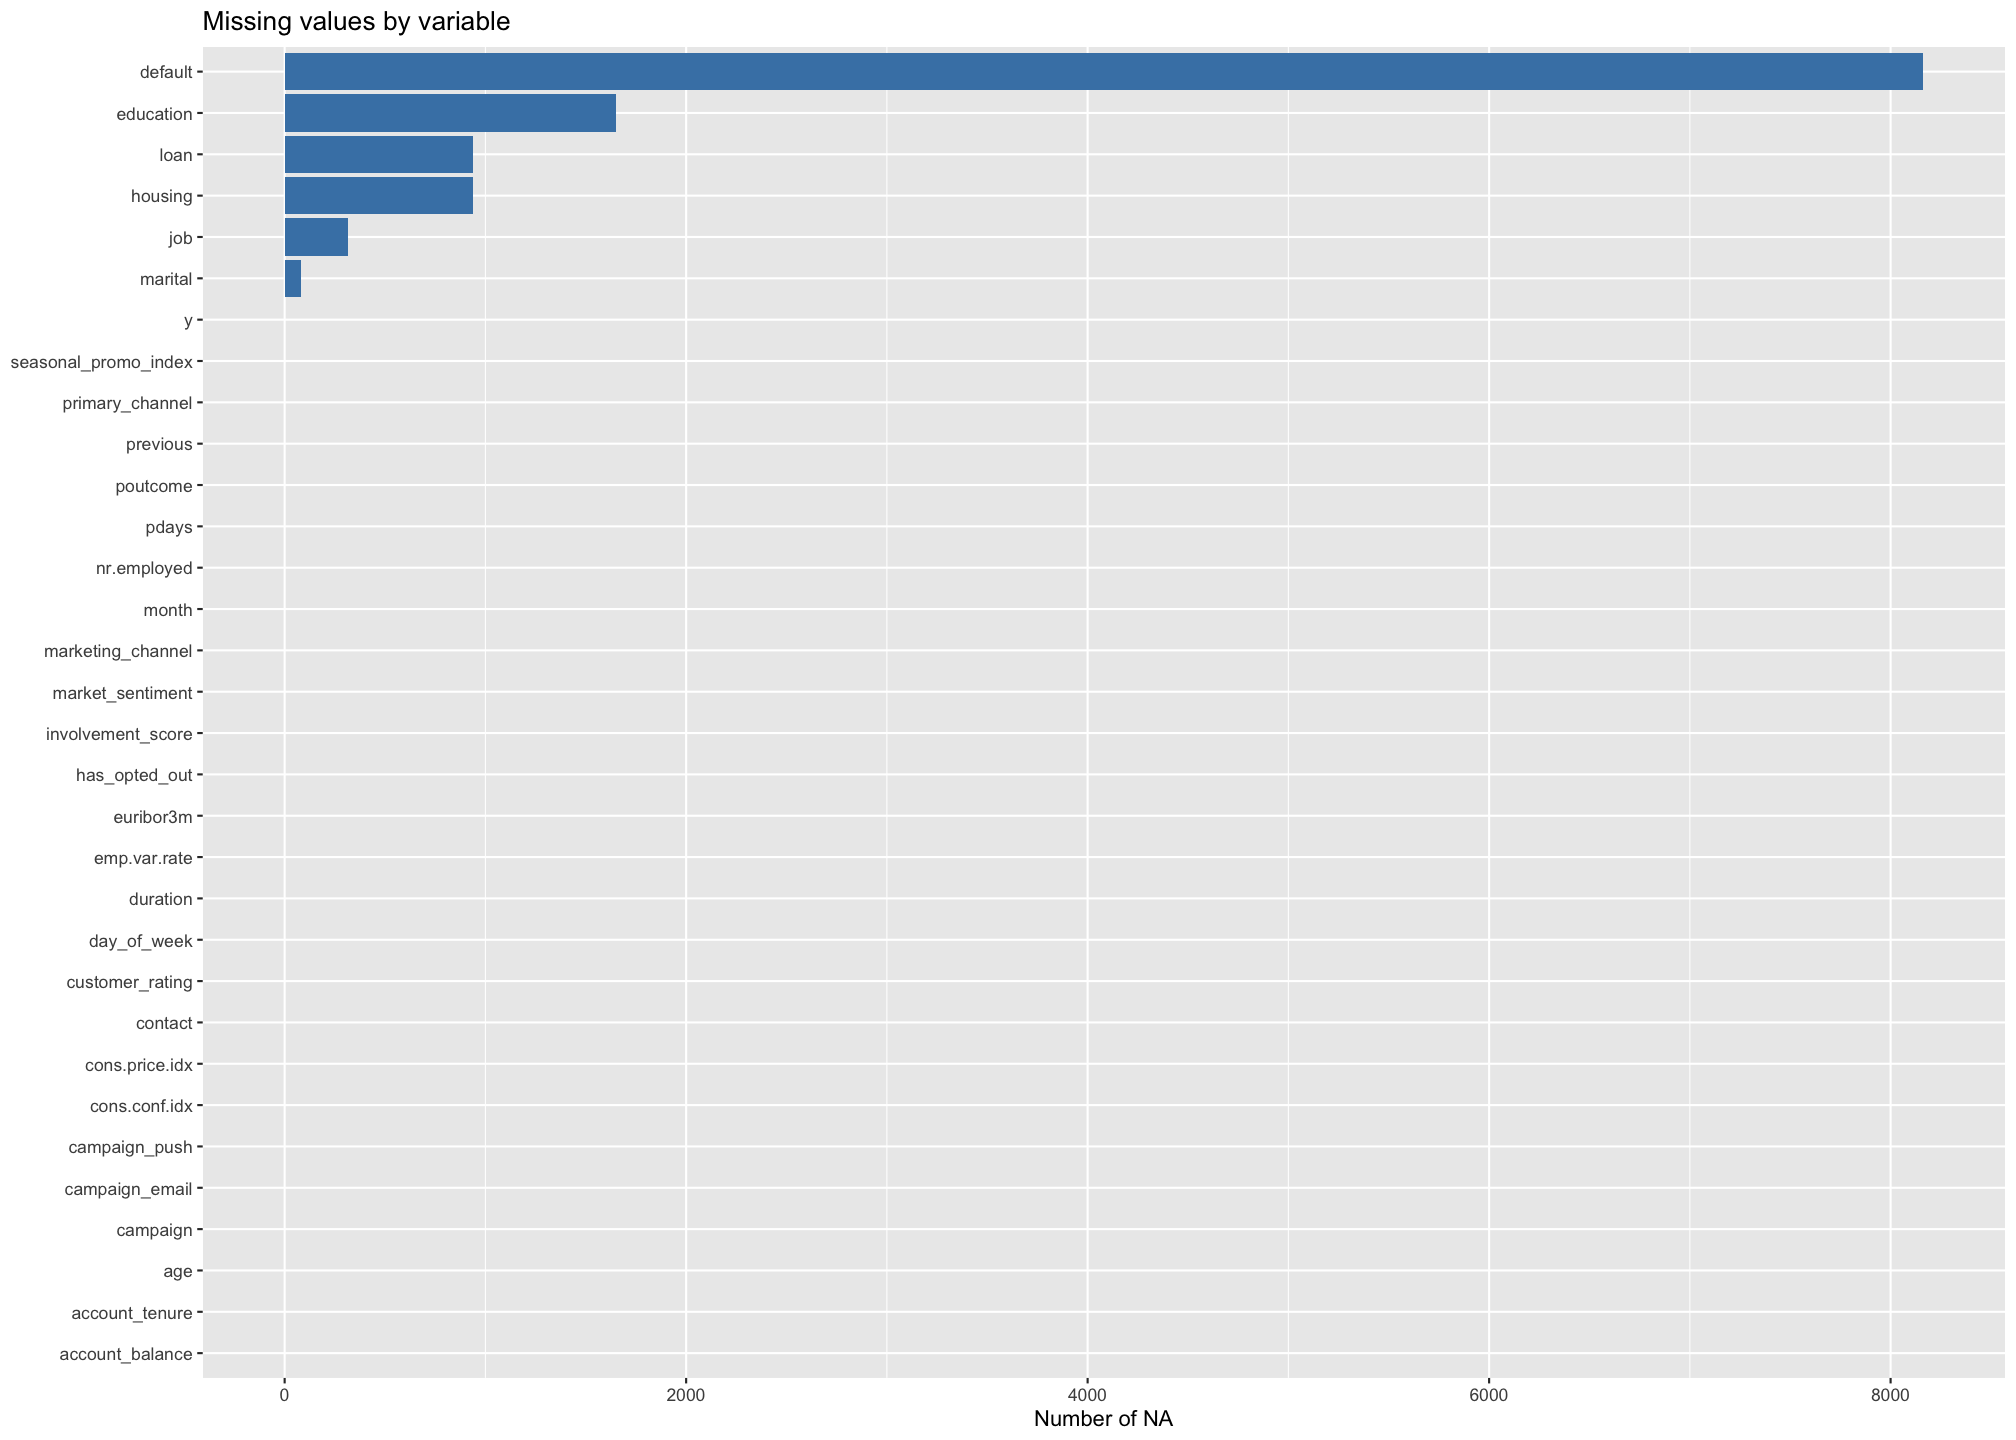

In [5]:
miss_full <- tibble(variable = names(df_full), n_na = colSums(is.na(df_full)))
ggplot(miss_full, aes(x = reorder(variable, n_na), y = n_na)) +
    geom_col(fill = "steelblue") +
    labs(title = "Missing values by variable", x = NULL, y = "Number of NA") +
    coord_flip() 

Много пропусков в столбце `default`. Вероятно, пропуск значения в этой переменой можно разценивать как `false` - отсутствие кредитов в состоянии дефолта.

В переменных `education`, `loan`, `housing`, `job` и `marital` гораздо меньше пропусков. Если потребуется, отдельно посмотрим, как их стоит заполнить. Учитывая, что эти переменные категориальные, вероятно имеет смысл просто рассматривать пропуск значения как отдельную категорию.

Из описания данных также известно, что "неявные" пропуски есть в переменных `pdays` (999 = не было) и `customer_rating` (0 = не оценил).

В остальных переменных пропусков нет.

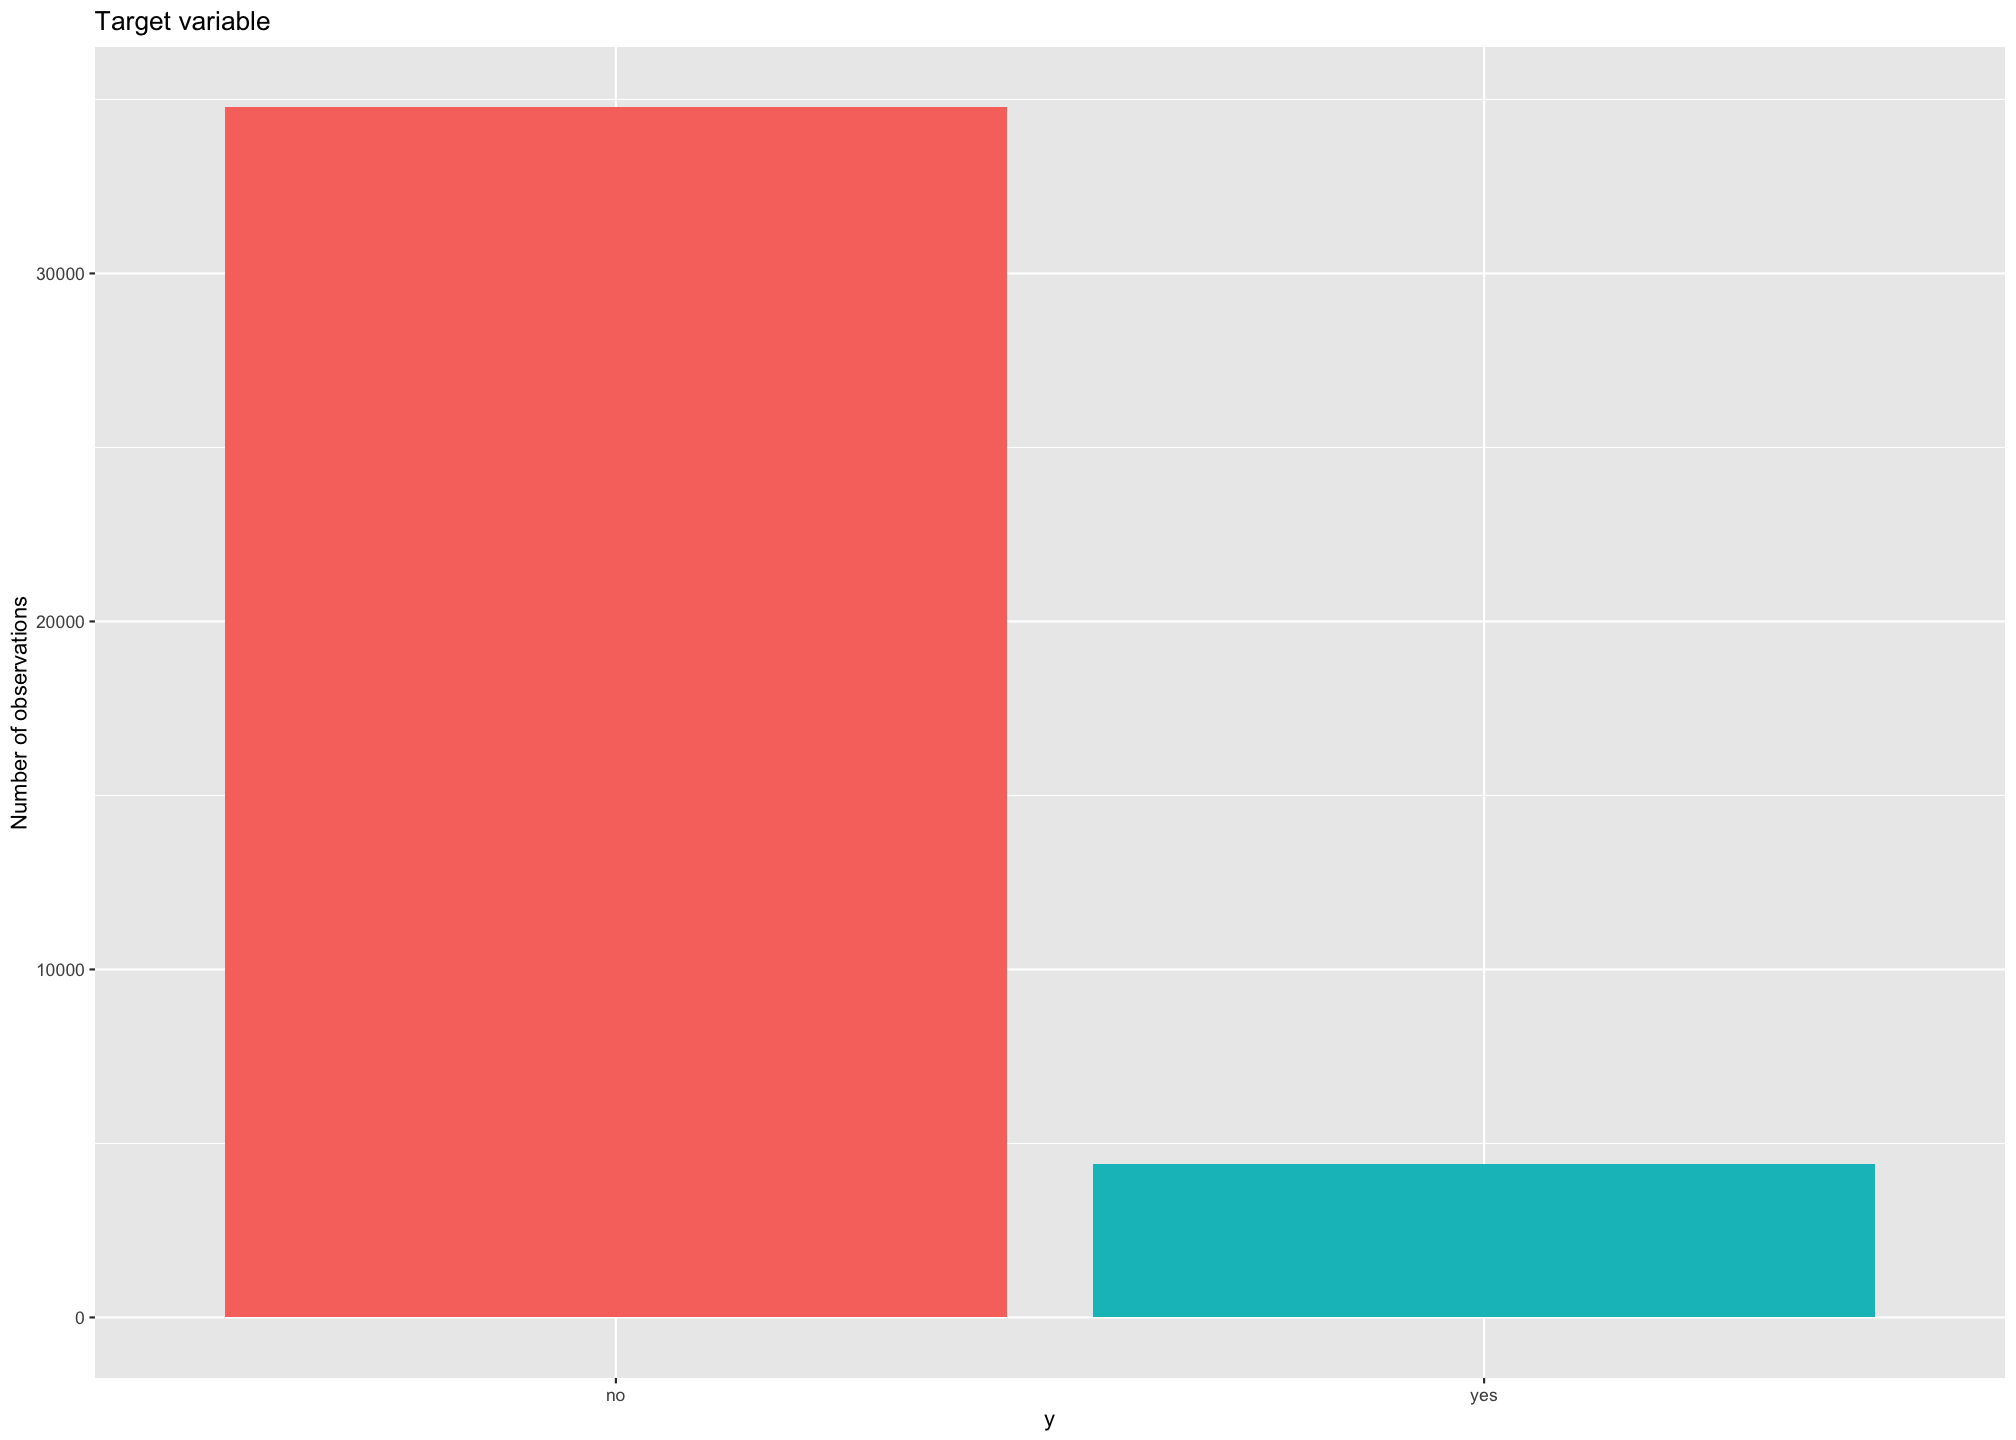

In [6]:
ggplot(count(df_full, y), aes(x = y, y = n, fill = y)) +
    geom_col(show.legend = FALSE) +
    labs(title = "Target variable", x = "y", y = "Number of observations")

Наблюдается явный дисбаланс классов: `no` примерно в 7 раз больше, чем `yes`. Для оценки качества точно будем использовать F1-меру или AUC-ROC.

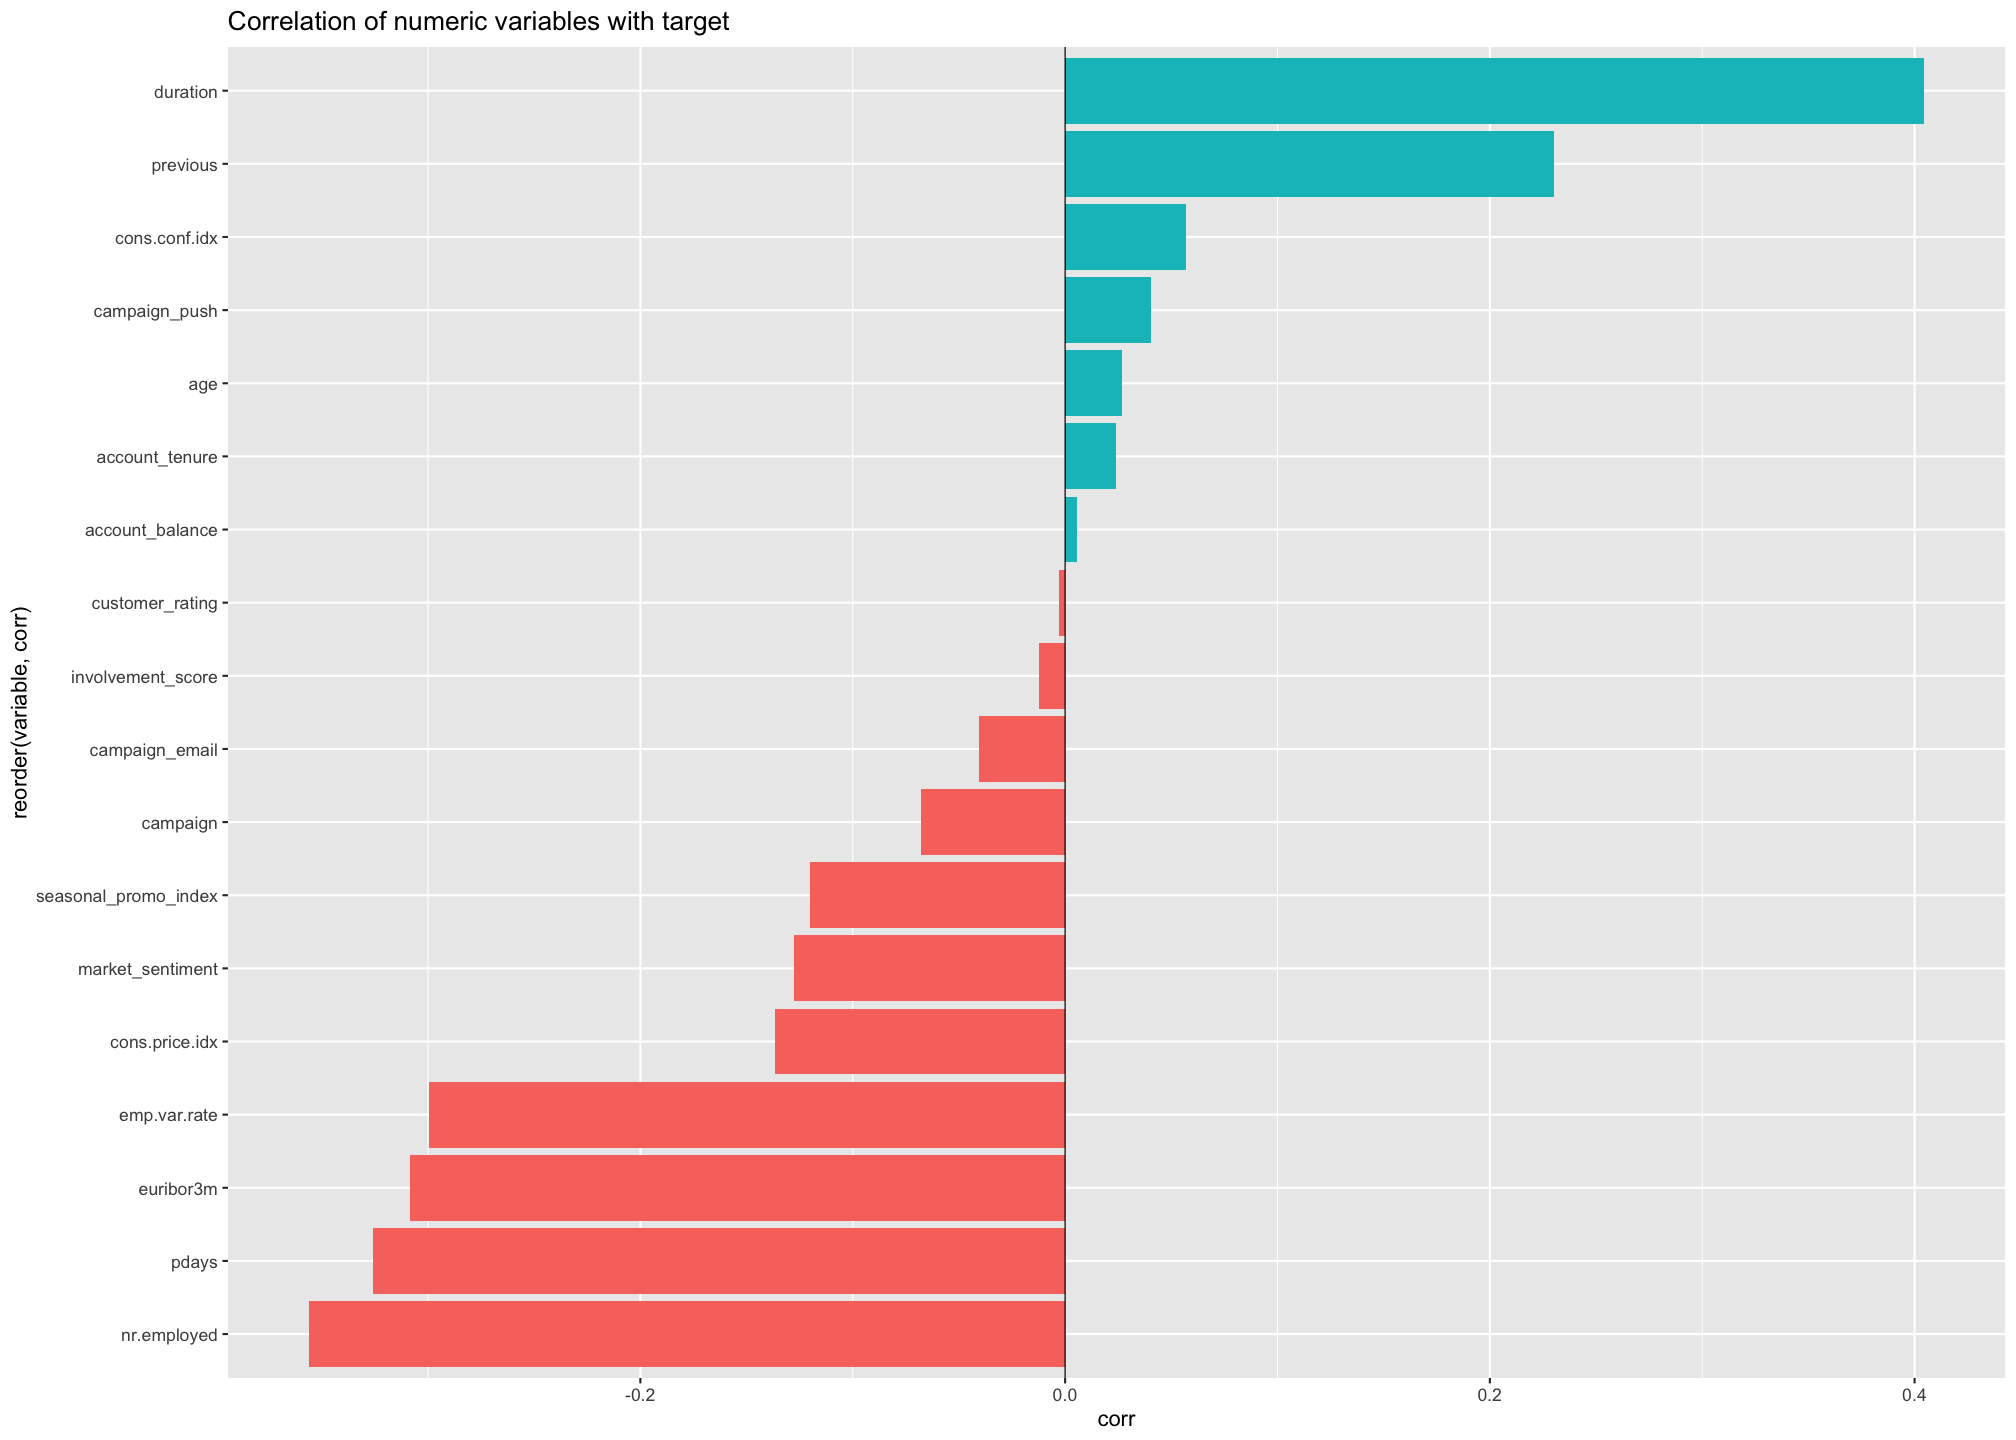

In [7]:
correlations <- summarise(
    mutate(df_full, y_num = as.integer(y == "yes")),
    across(all_of(numeric_variables), ~cor(.x, y_num))
)
correlations <- pivot_longer(
    correlations, everything(), names_to = "variable", values_to = "corr"
)
ggplot(correlations, aes(x = reorder(variable, corr), y = corr)) +
    geom_col(aes(fill = corr > 0), show.legend = FALSE) +
    geom_hline(yintercept = 0, linewidth = 0.3) +
    coord_flip() +
    labs(title = "Correlation of numeric variables with target")

Среди численных переменных, несколько явно имеют хорошую корреляцию с целевой переменной:
- `duration`, `previous` (положительная корреляция)
- `nr.employed`, `pdays`, `euribor3m`, `emp.var.rate` (антикорреляция)

Уже на основании этой информации можно предложить несколько гипотез о клиентах:
- Если последний звонок длился долго, клиент вероятно откликнется на кампанию
- Если клиенту звонили много раз в прошлых кампаниях, он более вероятно откликнется на текущую кампанию (видимо, потому что достали :))
- Если клиент много занял за последние 3 месяца, то маловероятно, что он откликнется на кампанию. Не хочет копить долги :)
- Если процентная ставка высокая (Euribor), то клиент склонен не откликнуться на кампанию. 

Warning message:
“Using `all_of()` outside of a selecting function was deprecated in tidyselect
1.2.0.
ℹ See details at
  <https://tidyselect.r-lib.org/reference/faq-selection-context.html>”


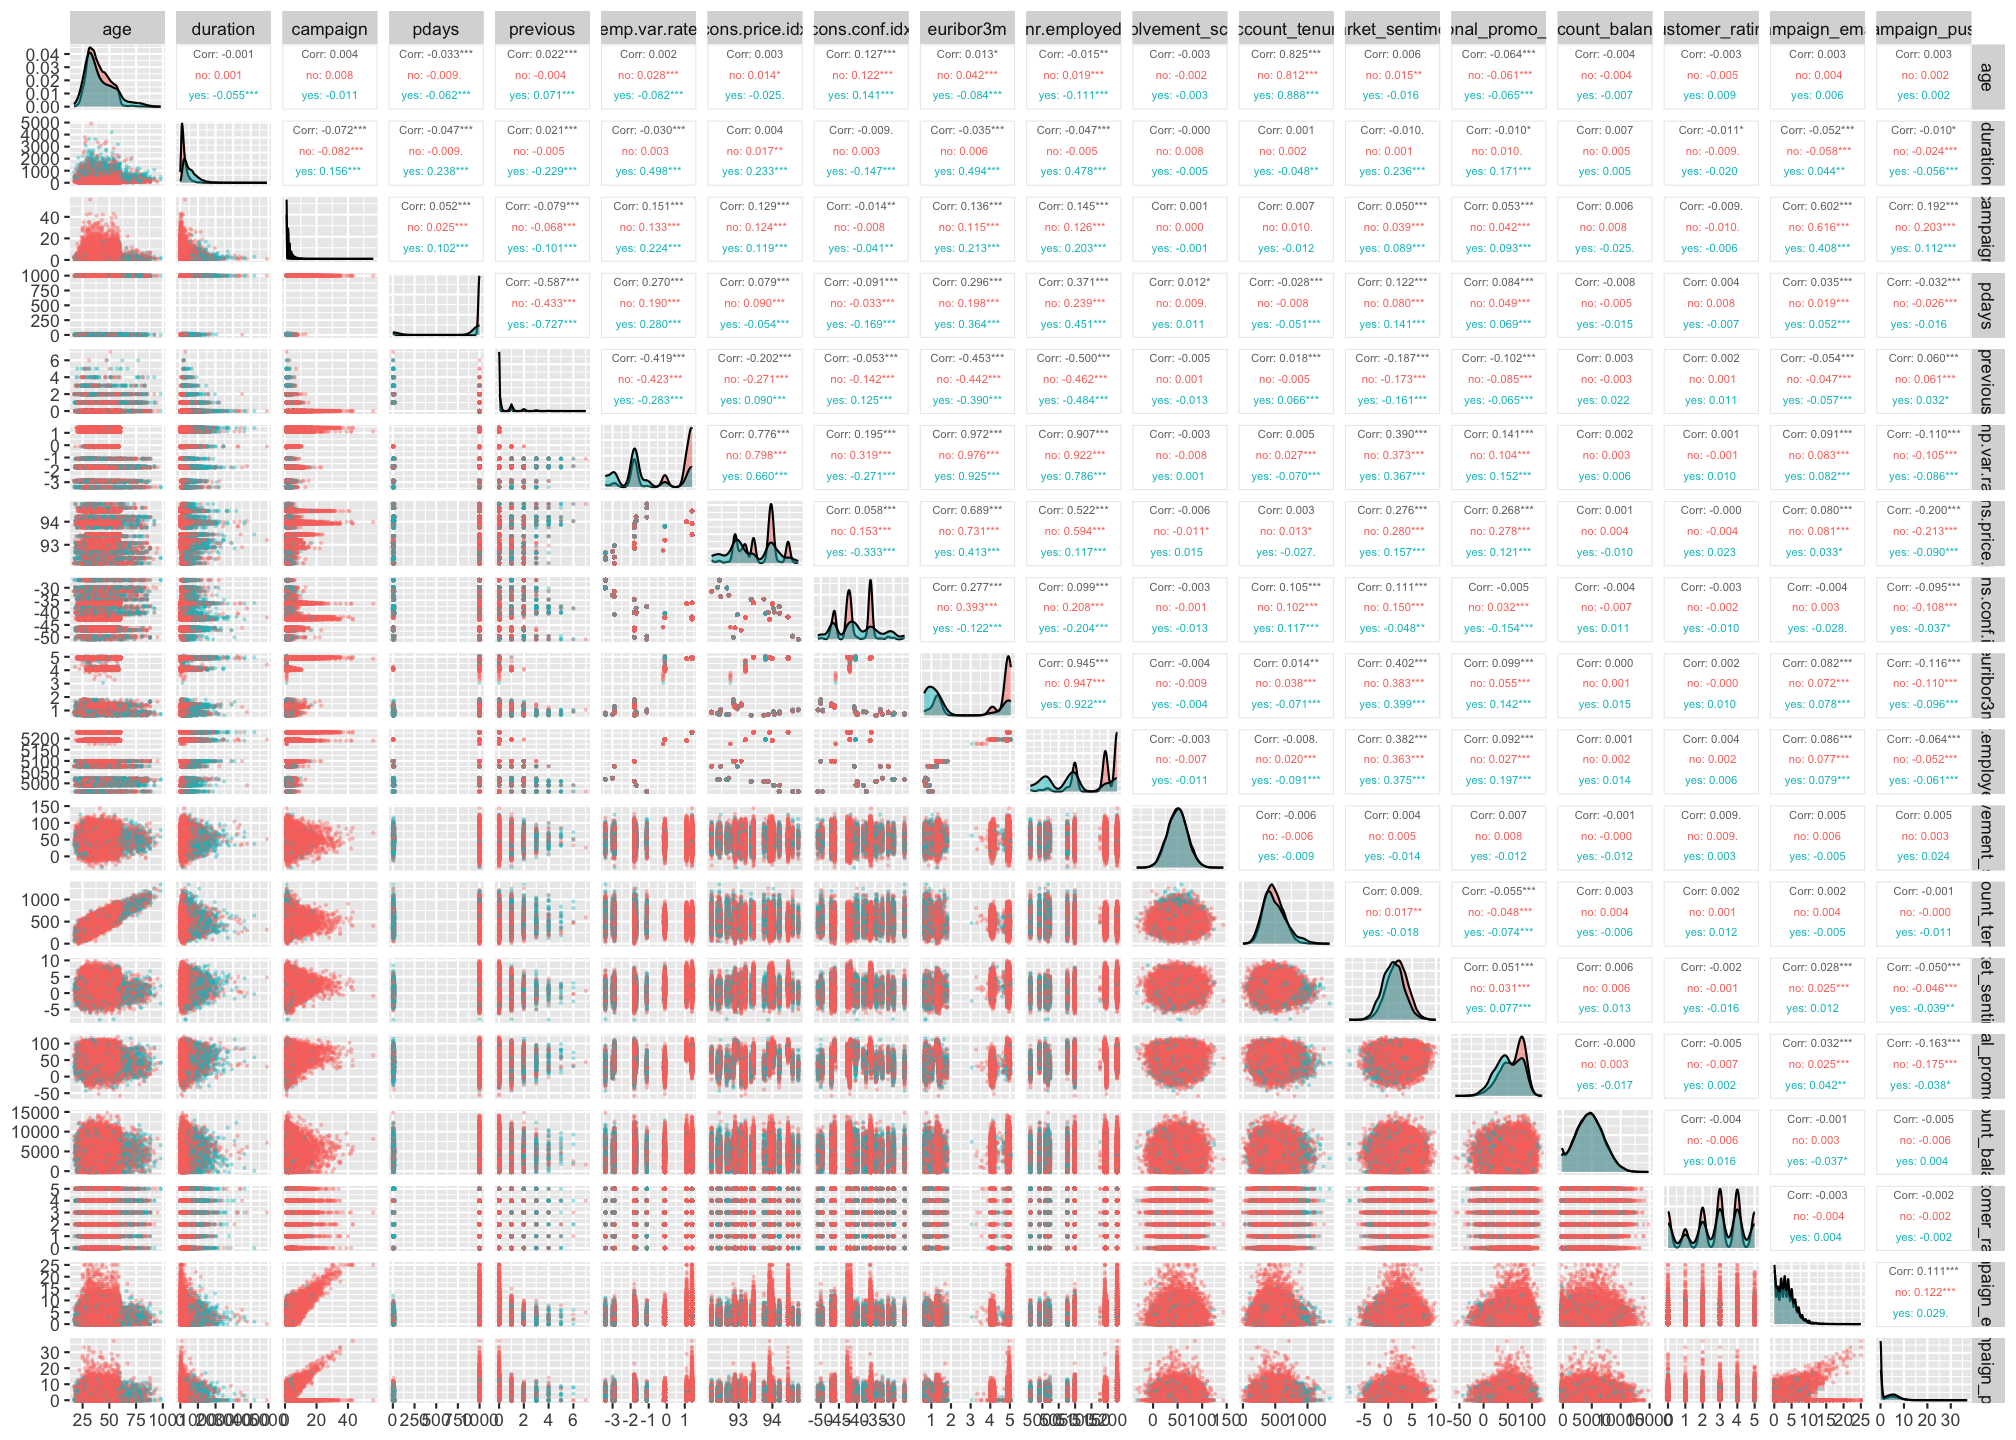

In [8]:
ggpairs(
    df_full,
    columns = all_of(numeric_variables),
    mapping = ggplot2::aes(color = y),
    upper = list(continuous = wrap("cor", size = 2)),
    lower = list(continuous = wrap("points", alpha = 0.3, size = 0.35)),
    diag = list(continuous = wrap("densityDiag", alpha = 0.5))
)

Некоторые признаки явно распределены по-разному в двух классах (`emp.var.rate`, `cons.price.idx`, `euribor3m`, `nr.employed`). Вероятно, они будут хорошими предикторами. Но для некоторых признаков распределения практически не отличаются (`count_balance`, `campaign_email`). Эти признаки могут быть полезны только в комбинации с другими.

Для отдельных признаков наблюдаются значительные взаимные корелляции (`age` и `account_tenure`, `campaign` и `campaign_email`/`campaign_push`), которые нужно будет учитывать при построении моделей.

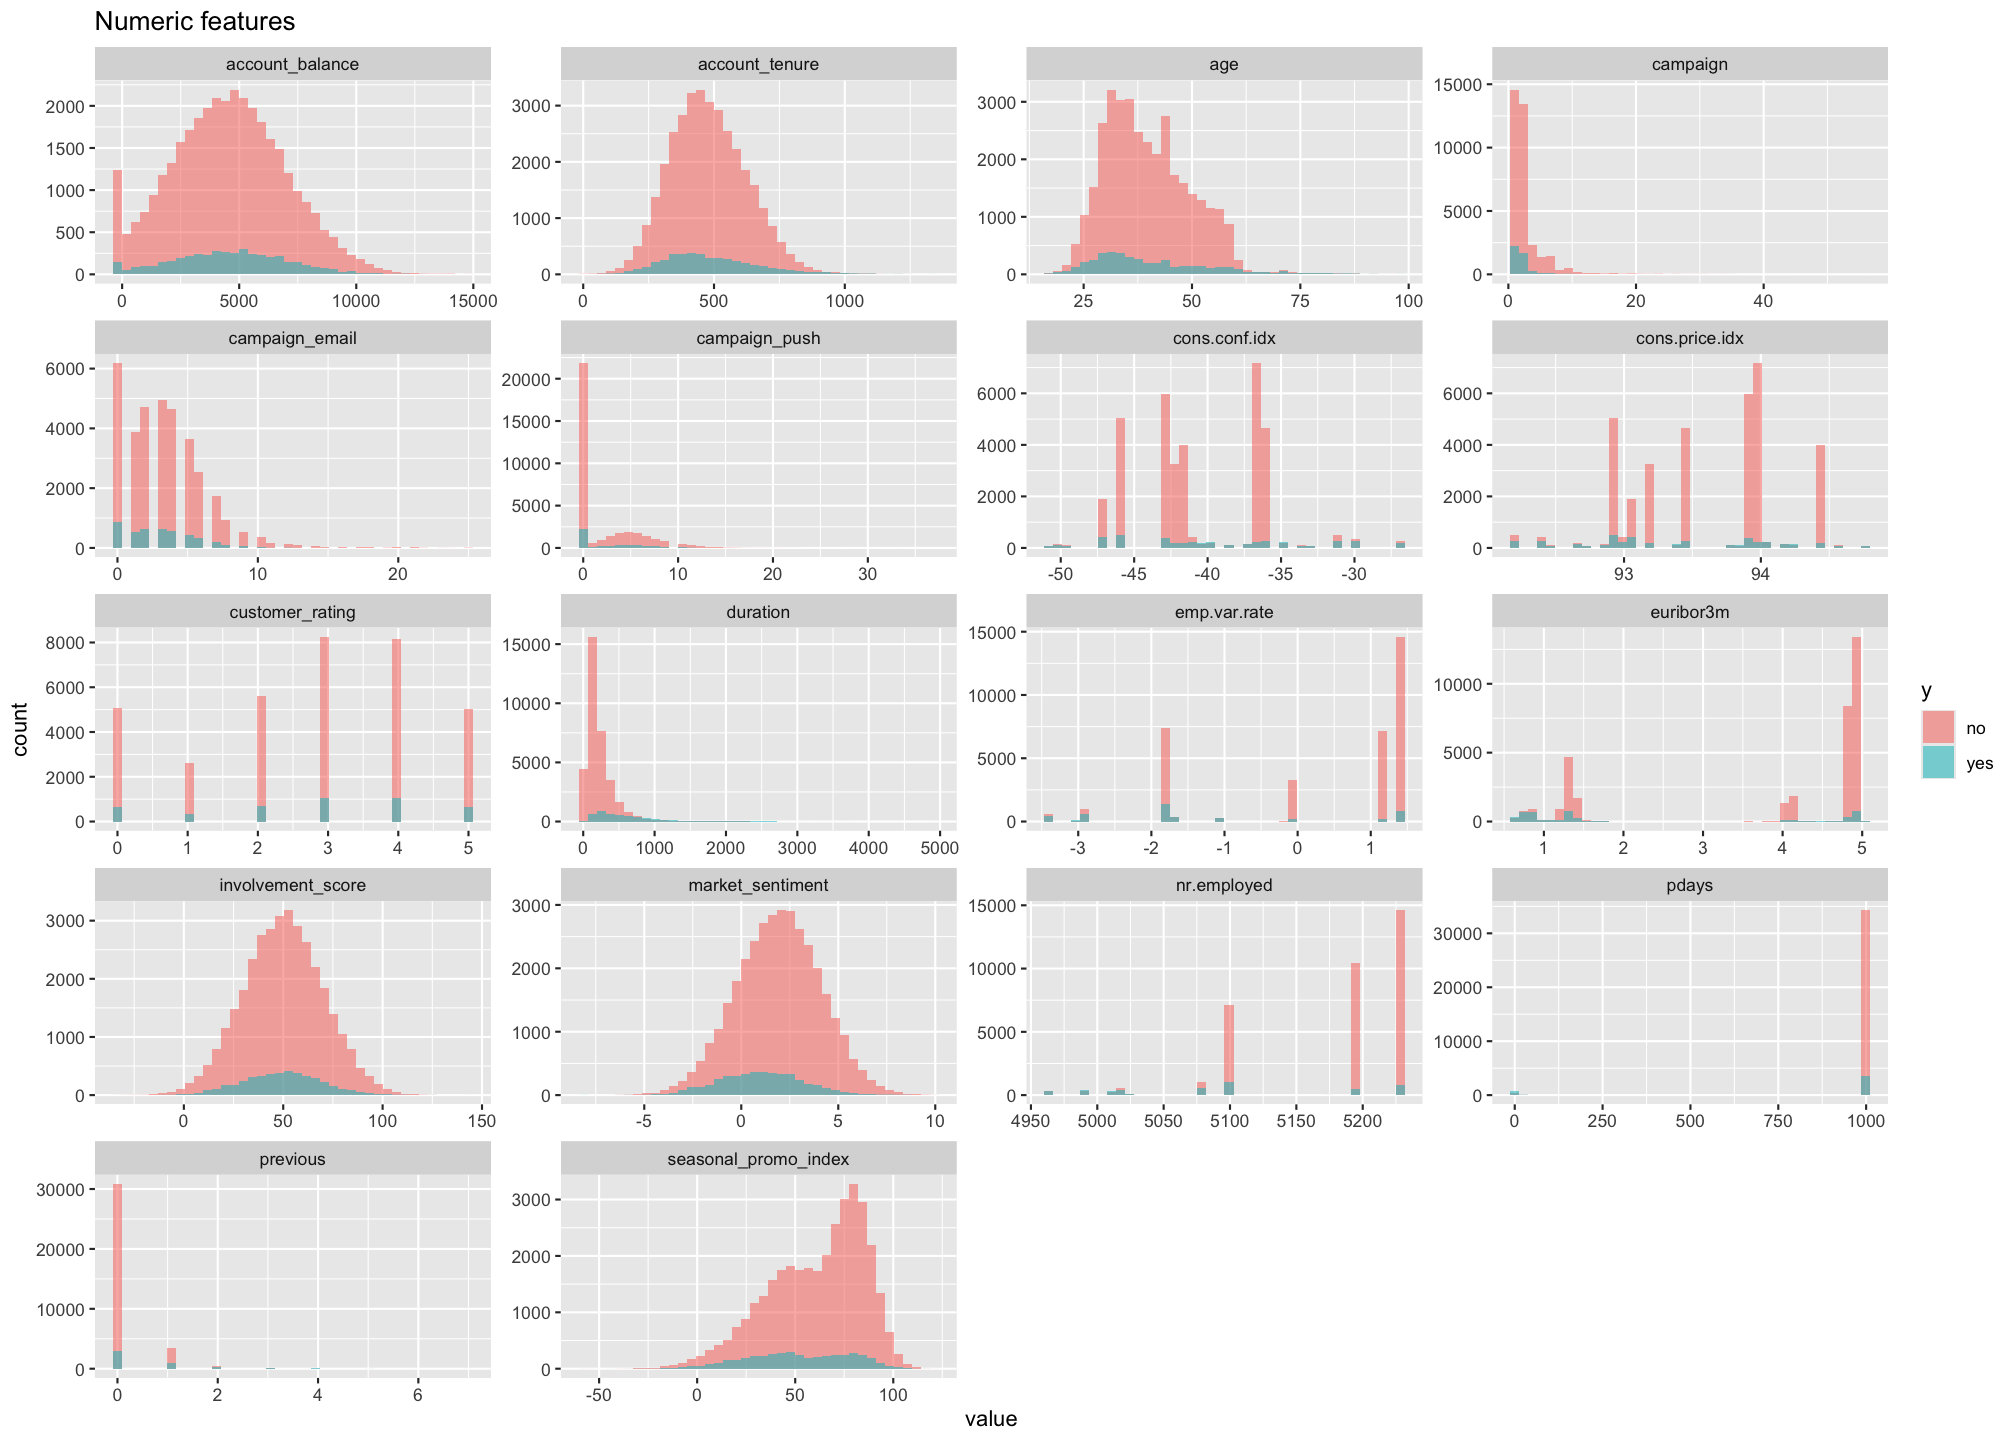

In [9]:
df_numeric <- pivot_longer(
    select(df_full,
    y,
    all_of(numeric_variables)),
    -y,
    names_to = "variable",
    values_to = "value"
)
ggplot(df_numeric, aes(x = value, fill = y)) +
    geom_histogram(bins = 40, position = "identity", alpha = 0.55, color = NA) +
    facet_wrap(~ variable, scales = "free", ncol = 4) +
    labs(title = "Numeric features", fill = "y")

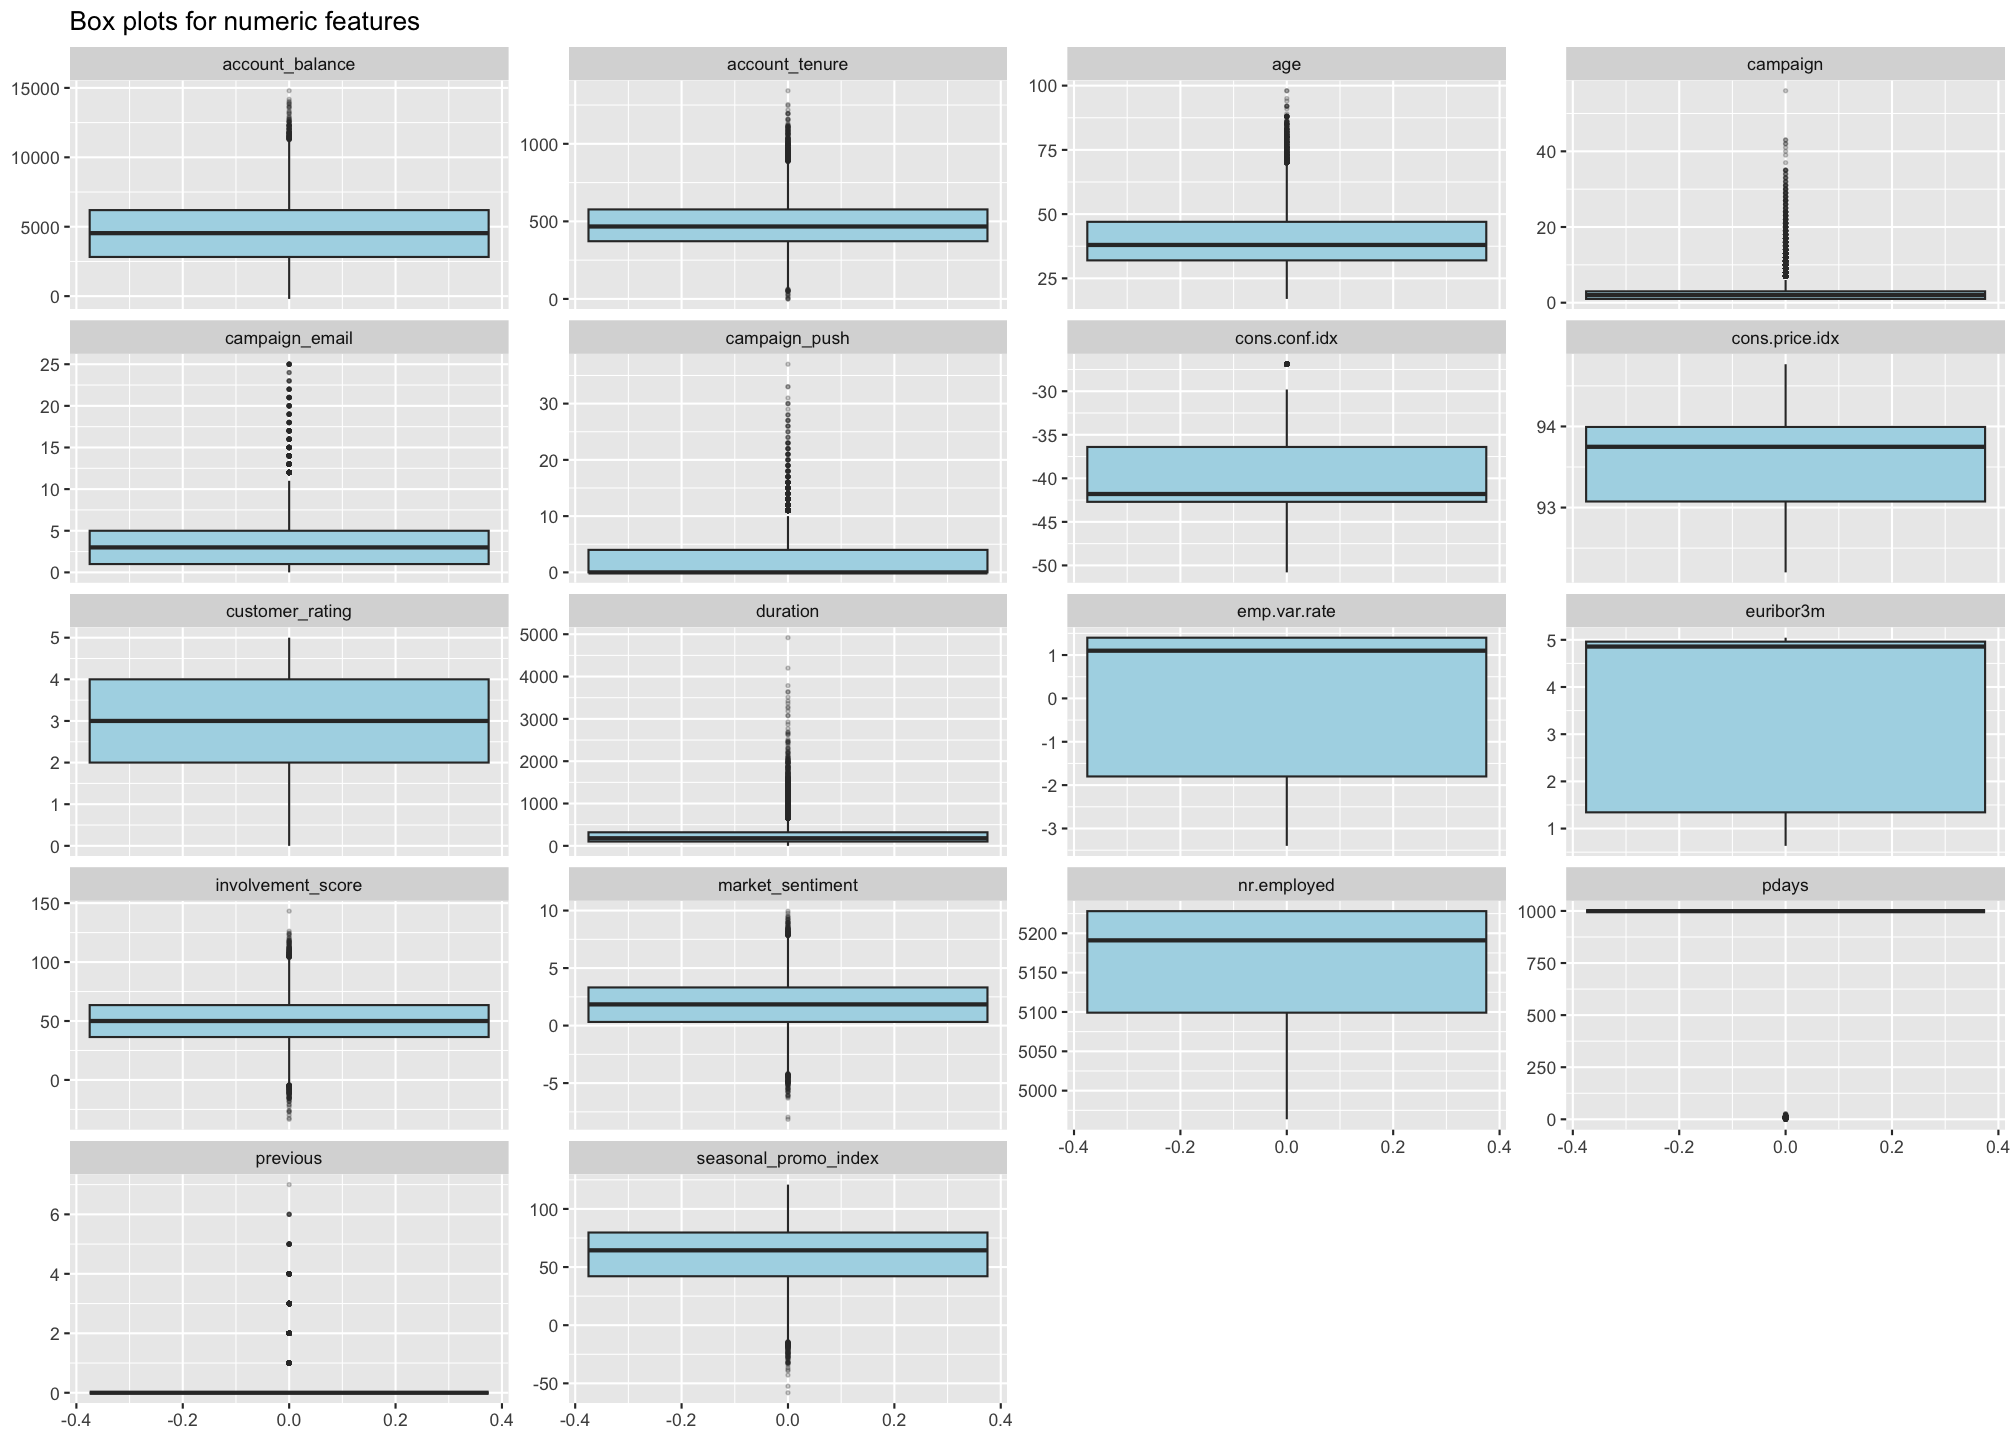

In [10]:
ggplot(df_numeric, aes(y = value)) +
    geom_boxplot(fill = "lightblue", outlier.alpha = 0.25, outlier.size = 0.6) +
    facet_wrap(~ variable, scales = "free_y", ncol = 4) +
    labs(title = "Box plots for numeric features", x = NULL, y = NULL)

- У некоторых признаков, включая `account_balance`, `duration` и `campaign`, наблюдаются длинные хвосты, указывающие на сильные выбросы.
- `previous` и `campaign` очень сжаты у нуля: большинству клиентов было всего несколько (и даже вовсе 0) звонков.
- `pdays` почти весь в 999 - значение, соответствующее пропуску в данных. Скорее всего, имеет смысл просто удалить этот признак: пропусков в нем больше, чем реальных значений.
- Отдельные признаки (`involvement_score`, `market_sentiment`, `account_tenure`) имеют "усы" с обеих сторон, что указывает на относительную нормальность распределения этих переменных.

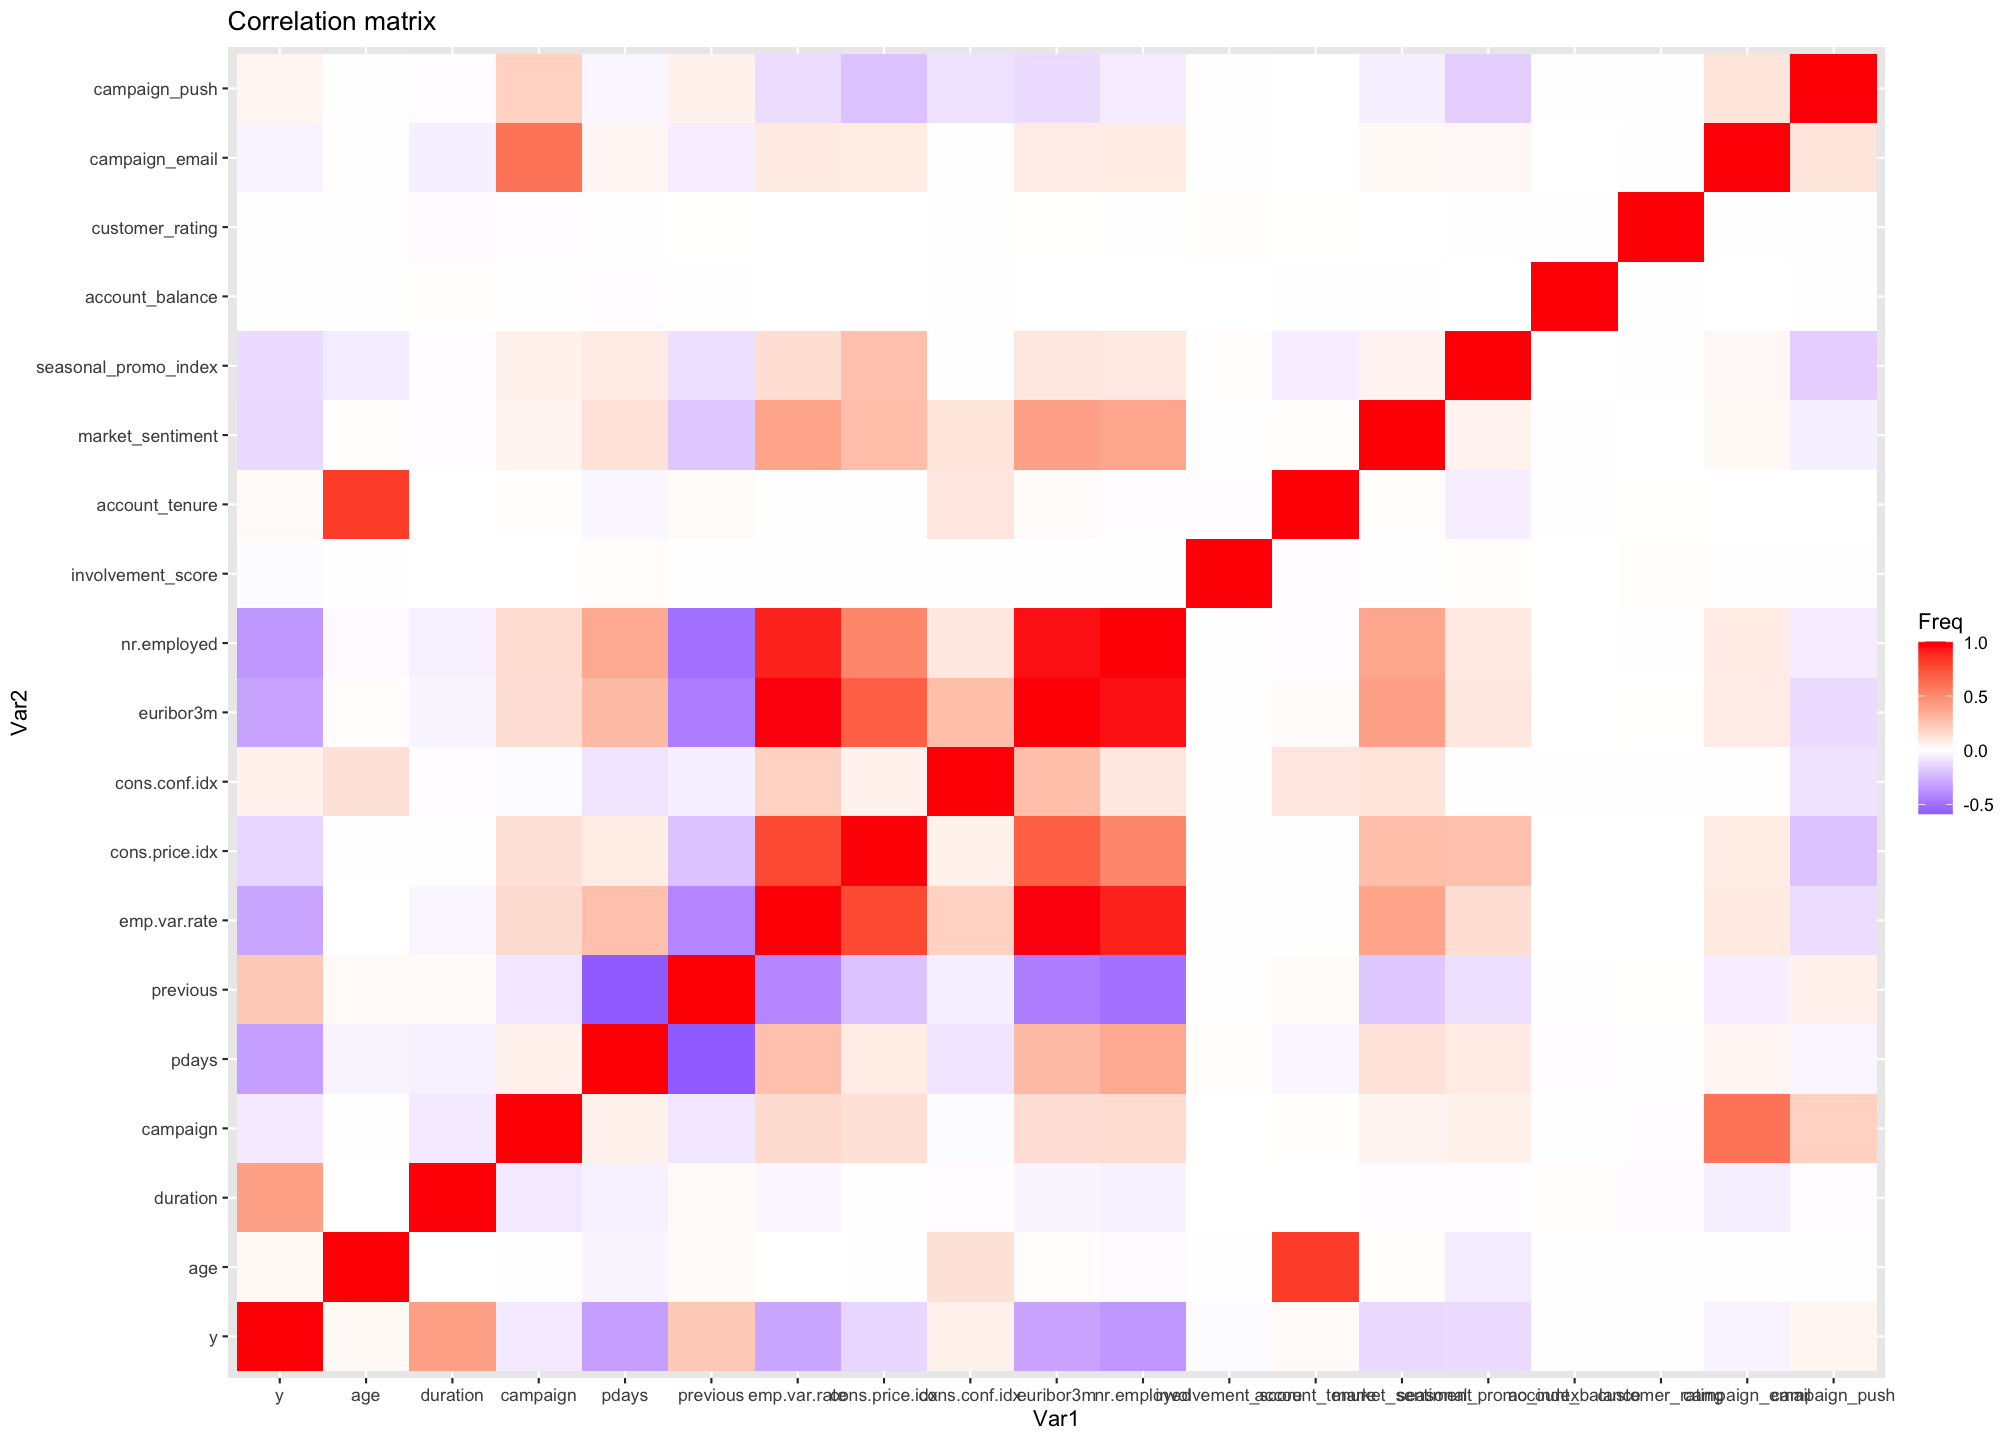

In [11]:
df_corr <- as.data.frame(as.table(cor(select(mutate(df_full, y = as.integer(y == "yes")), y, all_of(numeric_variables)))))
ggplot(df_corr, aes(Var1, Var2, fill = Freq)) +
     geom_tile() +
     scale_fill_gradient2(low = "blue", high = "red", mid = "white", midpoint = 0) +
     labs(title = "Correlation matrix")

Как уже было замечено ранее, некоторые признаки сильно кореллированы.

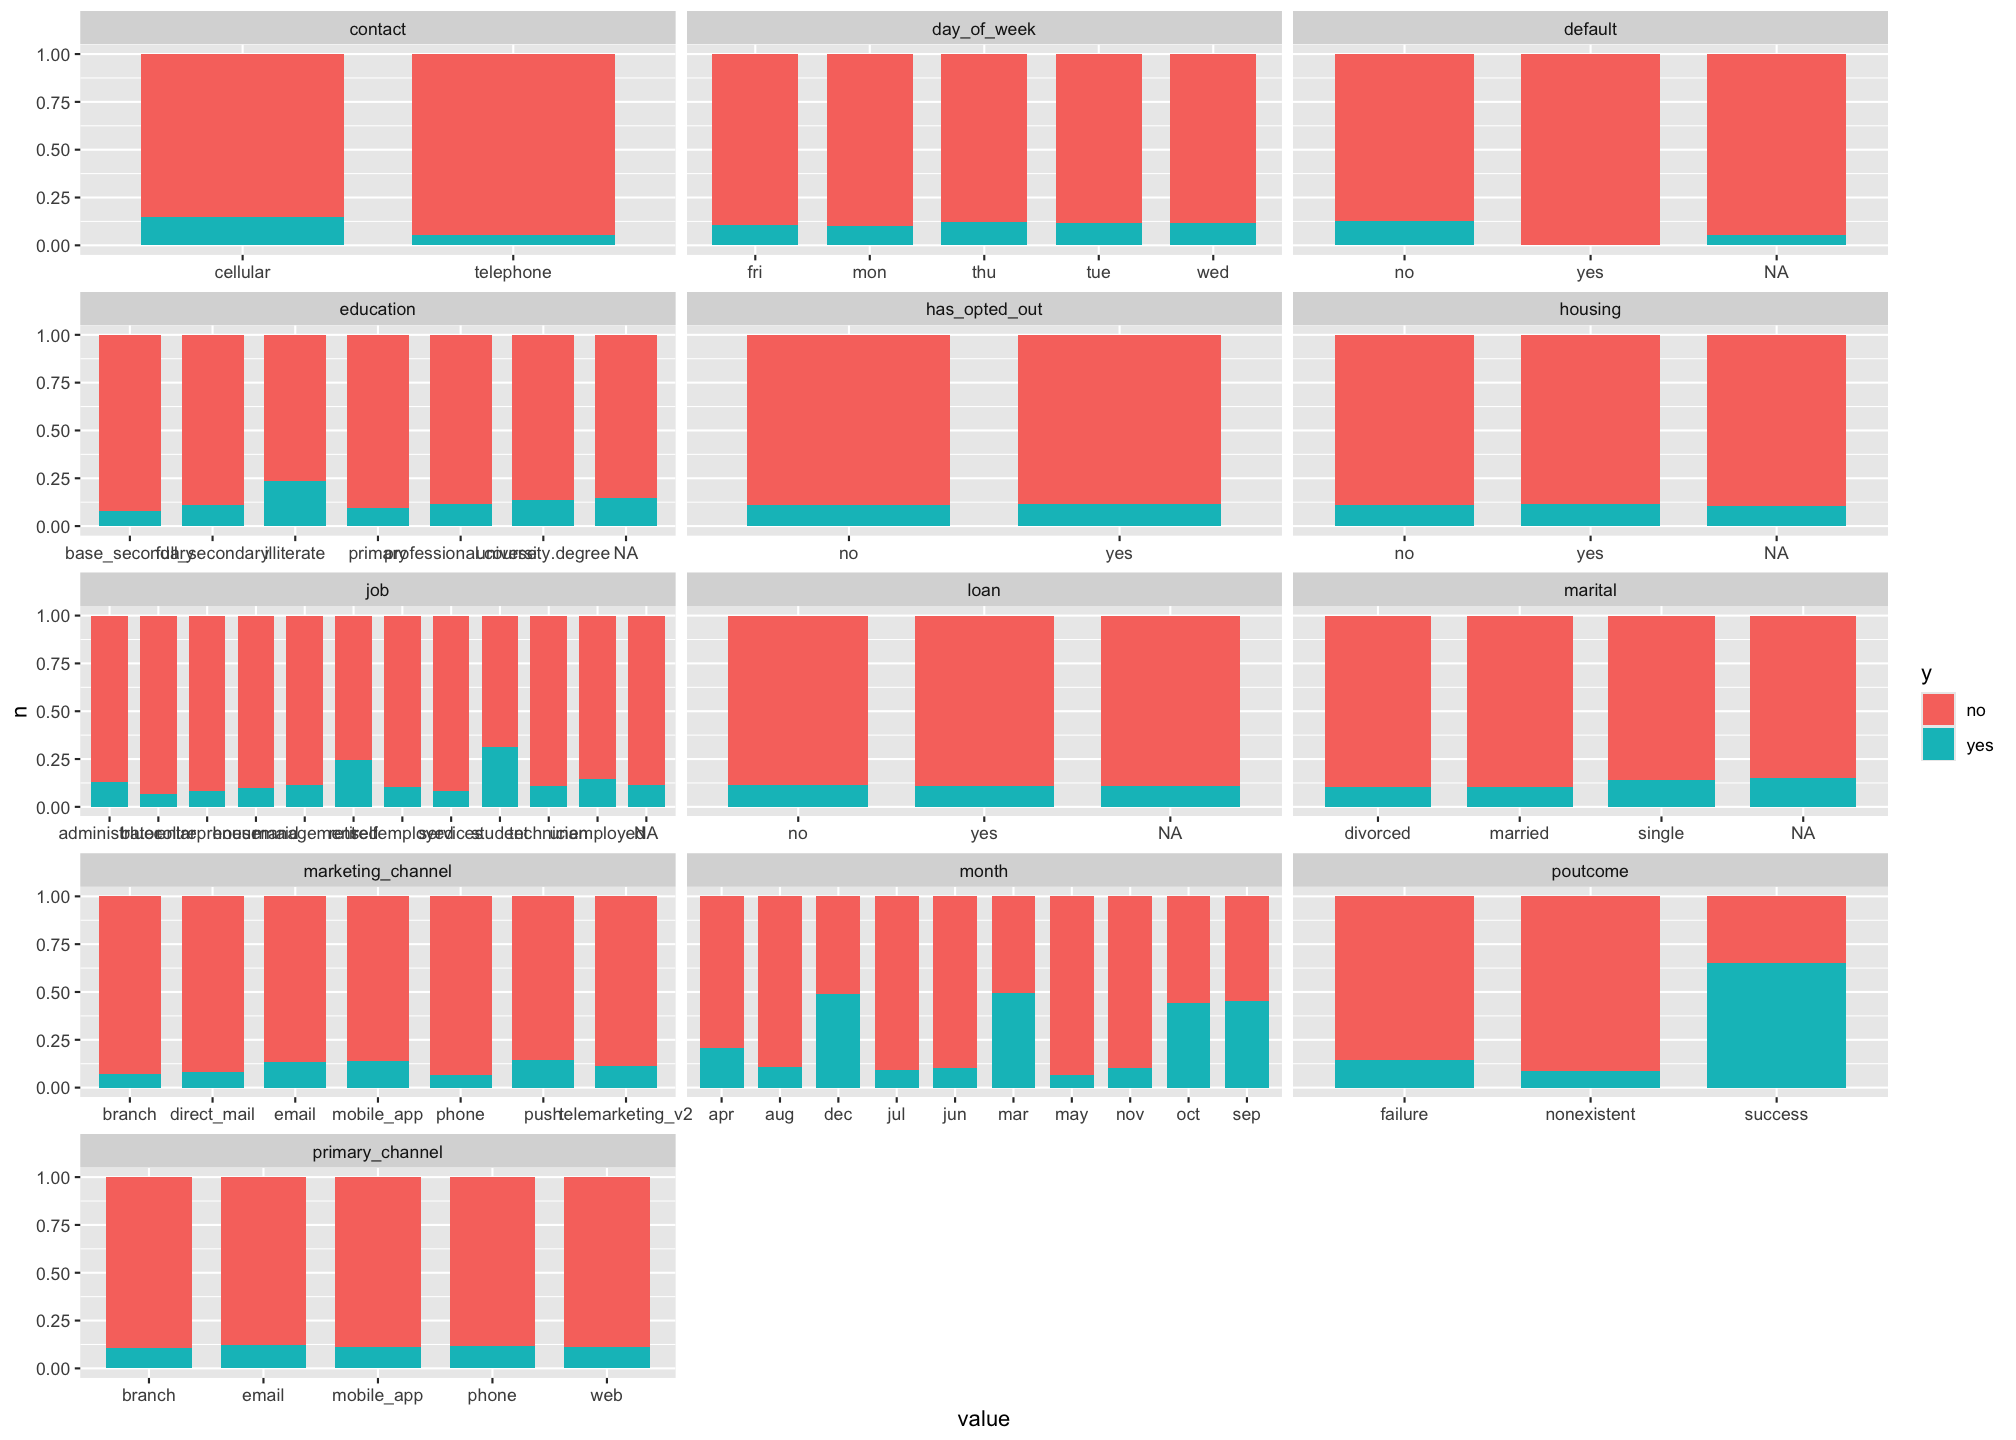

In [12]:
ggplot_df <- pivot_longer(
    select(df_full, all_of(category_variables), y),
    -y,
    names_to = "variable",
    values_to = "value"
)
ggplot(count(ggplot_df, variable, value, y, name = "n"), aes(x = value, y = n, fill = y)) +
    geom_col(position = "fill", width = 0.75) +
    facet_wrap(~ variable, scales = "free_x", ncol = 3)

В категориальных признаках также можно отметить ряд интересных закономерностей. Например,
- Все клиенты с `default=yes` имеют в целевой переменной значение `no`. В целом, ожидаемо: такие клиенты не получат новый кредит (и хорошо).
- Интересное распределение у признака `education`. Явно выделяется графа "illiterate": неграмотные люди с большей вероятностью берут кредит :)
- В разбиении по месяцу, кредиты часто берут в декабре, марте, октябре и сентябре. Наверное, это можно привязать к различным собятиям.
- Наконец, наиболее явная закономерность наблюдается у признака `poutcome`. Большая часть тех, для кого прошлая кампания была успешна, откликнулись и на новую кампанию.

## Задание 2 (2 балла)

В этой части вы будете работать с методологией MCA для поиска внутренних связей
между категориальными признаками. Вам необходимо сделать разведочный анализ для
того, чтобы понять, как ведут себя переменные дальше в более продвинутых алгоритмах.

**Ожидаемый результат**
1. Таблица contrib и cos2 для топ-5 категорий на Dim.1 и Dim.2 + комментарий
2. MCA-би-плот с эллипсами доверия для y + комментарий
3. Вопрос для отчета: «А точно ли надо включать определенные переменные в MCA,
если его v.test незначим? Как объяснить руководителю, что «лишние» категории
ломают визуализацию?»

**Отберите категориальные признаки из датасета для сегментации (можно взять минимум 8-10, но больше — лучше; правда необходимо помнить о том, что в визуализации
они будут как дамми!). Запустите mca (c ncp примерно 5) из FactoMineR. Визуализируйте би-плот по переменным (категориям), выделите категории с cos2 > 0.3 (Наводка: как
отдельные переменные располагаются относительно y на первых двух осях?). Интерпретируйте Оси 1 и 2: какие группы категорий формируют градиенты? Сформулируйте
2 маркетинговые гипотезы.**

In [13]:
set.seed(SEED)

df_mca <- mutate(
    select(df_full, all_of(category_variables)),
    across(everything(), ~ ifelse(is.na(.), "missing", as.character(.))),
    across(everything(), as.factor)
)
y_idx <- which(names(df_mca) == "y")
mca_res <- MCA(df_mca, ncp = 5, quali.sup = y_idx, graph = FALSE)
print(mca_res)

high_cos2 <- rownames(mca_res$var$cos2)[rowSums(mca_res$var$cos2[, 1:2]) > 0.3]
cat("\nCategories with cos2(Dim.1+Dim.2) > 0.3:\n")
print(high_cos2)

**Results of the Multiple Correspondence Analysis (MCA)**
The analysis was performed on 39188 individuals, described by 14 variables
*The results are available in the following objects:

   name                description                                          
1  "$eig"              "eigenvalues"                                        
2  "$var"              "results for the variables"                          
3  "$var$coord"        "coord. of the categories"                           
4  "$var$cos2"         "cos2 for the categories"                            
5  "$var$contrib"      "contributions of the categories"                    
6  "$var$v.test"       "v-test for the categories"                          
7  "$var$eta2"         "coord. of variables"                                
8  "$ind"              "results for the individuals"                        
9  "$ind$coord"        "coord. for the individuals"                         
10 "$ind$cos2"         "cos2 for the indivi

`missing` оказались категориями с наибольшим cos2. Нехорошо. Предлагаю удалить все строки с пропусками. Их около 25% в данных - в целом, не очень много. Заодно работать будет побыстрее :)

In [14]:
set.seed(SEED)

df_mca <- mutate(
    select(drop_na(df_full), all_of(category_variables)),
    across(everything(), as.factor)
)
y_idx <- which(names(df_mca) == "y")
mca_res <- MCA(df_mca, ncp = 5, quali.sup = y_idx, graph = FALSE)
print(mca_res)

high_cos2 <- rownames(mca_res$var$cos2)[rowSums(mca_res$var$cos2[, 1:2]) > 0.3]
cat("\nCategories with cos2(Dim.1+Dim.2) > 0.3:\n")
print(high_cos2)

**Results of the Multiple Correspondence Analysis (MCA)**
The analysis was performed on 29027 individuals, described by 14 variables
*The results are available in the following objects:

   name                description                                          
1  "$eig"              "eigenvalues"                                        
2  "$var"              "results for the variables"                          
3  "$var$coord"        "coord. of the categories"                           
4  "$var$cos2"         "cos2 for the categories"                            
5  "$var$contrib"      "contributions of the categories"                    
6  "$var$v.test"       "v-test for the categories"                          
7  "$var$eta2"         "coord. of variables"                                
8  "$ind"              "results for the individuals"                        
9  "$ind$coord"        "coord. for the individuals"                         
10 "$ind$cos2"         "cos2 for the indivi

Стало лучше. missing заменились на реальные признаки - `bluecollar`, `primary`, `university.degree`. Также остались `cellular` и `telephone`.

In [15]:
vt <- mca_res$var$v.test
for (d in seq_len(ncol(vt)))
{
    cat("\nTop-10 by |v.test| for Dim.", d, "\n", sep = "")
    print(round(vt[order(-abs(vt[, d]))[1:10], ], 2))
}


Top-10 by |v.test| for Dim.1
                               Dim 1  Dim 2  Dim 3  Dim 4  Dim 5
cellular                      144.25  50.24   8.26 -11.70 -19.31
telephone                    -144.25 -50.24  -8.26  11.70  19.31
may                           -74.09   8.27  14.97 -19.71 -12.48
jun                           -72.42 -42.51  -8.36  19.83  26.10
marketing_channel_branch      -71.01 -25.37  -7.90   4.56  11.31
marketing_channel_phone       -69.95 -31.16  -5.45   8.46  10.53
marketing_channel_mobile_app   67.83  27.50   5.74  -4.11 -12.34
bluecollar                    -60.92 114.54  -3.14   2.04 -34.42
aug                            60.90 -24.64 -52.09  16.53 -16.28
university.degree              53.36 -78.42  15.90 106.21 -17.87

Top-10 by |v.test| for Dim.2
                    Dim 1  Dim 2  Dim 3  Dim 4  Dim 5
bluecollar         -60.92 114.54  -3.14   2.04 -34.42
primary            -36.63  94.56  -9.26  29.81  44.37
university.degree   53.36 -78.42  15.90 106.21 -17.87
base_seco

По первой координате, наиболее значимы признаки `cellular` и `telephone` (важно заметить, что "в разные стороны"). От остальных признаков значительный отрыв. Получается, наиболее значимая компонента - способ связи с клиентом.

По второй кооординате наиболее значимы категории `bluecollar` и `primary`. За ними идут `university.degree`, `base_secondary` и `administrator`. Соответственно, вторая компонента "смотрит" на профессию и образование клиента.

В третьей компоненте преобладают `professional.course` и `technician` - тоже про профессию/образование.

В целом результаты ожидаемые: клиентов действительно удобно кластеризовать по способу связи/профессии/образованию.

In [16]:
mca_dim_1 <- tibble(
    category = rownames(mca_res$var$coord),
    coord = mca_res$var$coord[, 1],
    contrib = mca_res$var$contrib[, 1],
    cos2 = mca_res$var$cos2[, 1]
)
mca_dim_2 <- tibble(
    category = rownames(mca_res$var$coord),
    coord = mca_res$var$coord[, 2],
    contrib = mca_res$var$contrib[, 2],
    cos2 = mca_res$var$cos2[, 2]
)

cat("Dim.1 - top-5 by contrib\n")
print(slice_max(mca_dim_1, contrib, n = 5))

cat("\nDim.1 - top-5 by cos2\n")
print(slice_max(mca_dim_1, cos2, n = 5))

cat("\nDim.2 - top-5 by contrib\n")
print(slice_max(mca_dim_2, contrib, n = 5))

cat("\nDim.2 - top-5 by cos2\n")
print(slice_max(mca_dim_2, cos2, n = 5))

high_cos2 <- rownames(mca_res$var$cos2)[rowSums(mca_res$var$cos2[, 1:2]) > 0.3]
cat("\nCategories with cos2(Dim.1+Dim.2) > 0.3:\n")
print(high_cos2)

Dim.1 - top-5 by contrib
# A tibble: 5 × 4
  category                  coord contrib  cos2
  <chr>                     <dbl>   <dbl> <dbl>
1 telephone                -1.21    20.8  0.717
2 cellular                  0.595   10.3  0.717
3 jun                      -1.16     6.90 0.181
4 marketing_channel_branch -1.07     6.53 0.174
5 marketing_channel_phone  -1.05     6.33 0.169

Dim.1 - top-5 by cos2
# A tibble: 5 × 4
  category                  coord contrib  cos2
  <chr>                     <dbl>   <dbl> <dbl>
1 cellular                  0.595   10.3  0.717
2 telephone                -1.21    20.8  0.717
3 may                      -0.634    5.57 0.189
4 jun                      -1.16     6.90 0.181
5 marketing_channel_branch -1.07     6.53 0.174

Dim.2 - top-5 by contrib
# A tibble: 5 × 4
  category           coord contrib  cos2
  <chr>              <dbl>   <dbl> <dbl>
1 bluecollar         1.41    21.7  0.452
2 primary            1.48    15.9  0.308
3 base_secondary     1.09     9.94 0

Топы по `contrib`/`cos2` подтверждают интерпретацию осей:
- Первое измерение - канал коммуникации: `telephone`/`cellular` дают `cos2` почти `0.72`.
- Второе измерение - образование + профессия: `bluecollar`+`primary`+`base_secondary` против `university.degree`+`administrator`.

Именно эти 5 категорий и попадают в список с `cos2 > 0.3`, составляя основу для интерпретации сегментов.

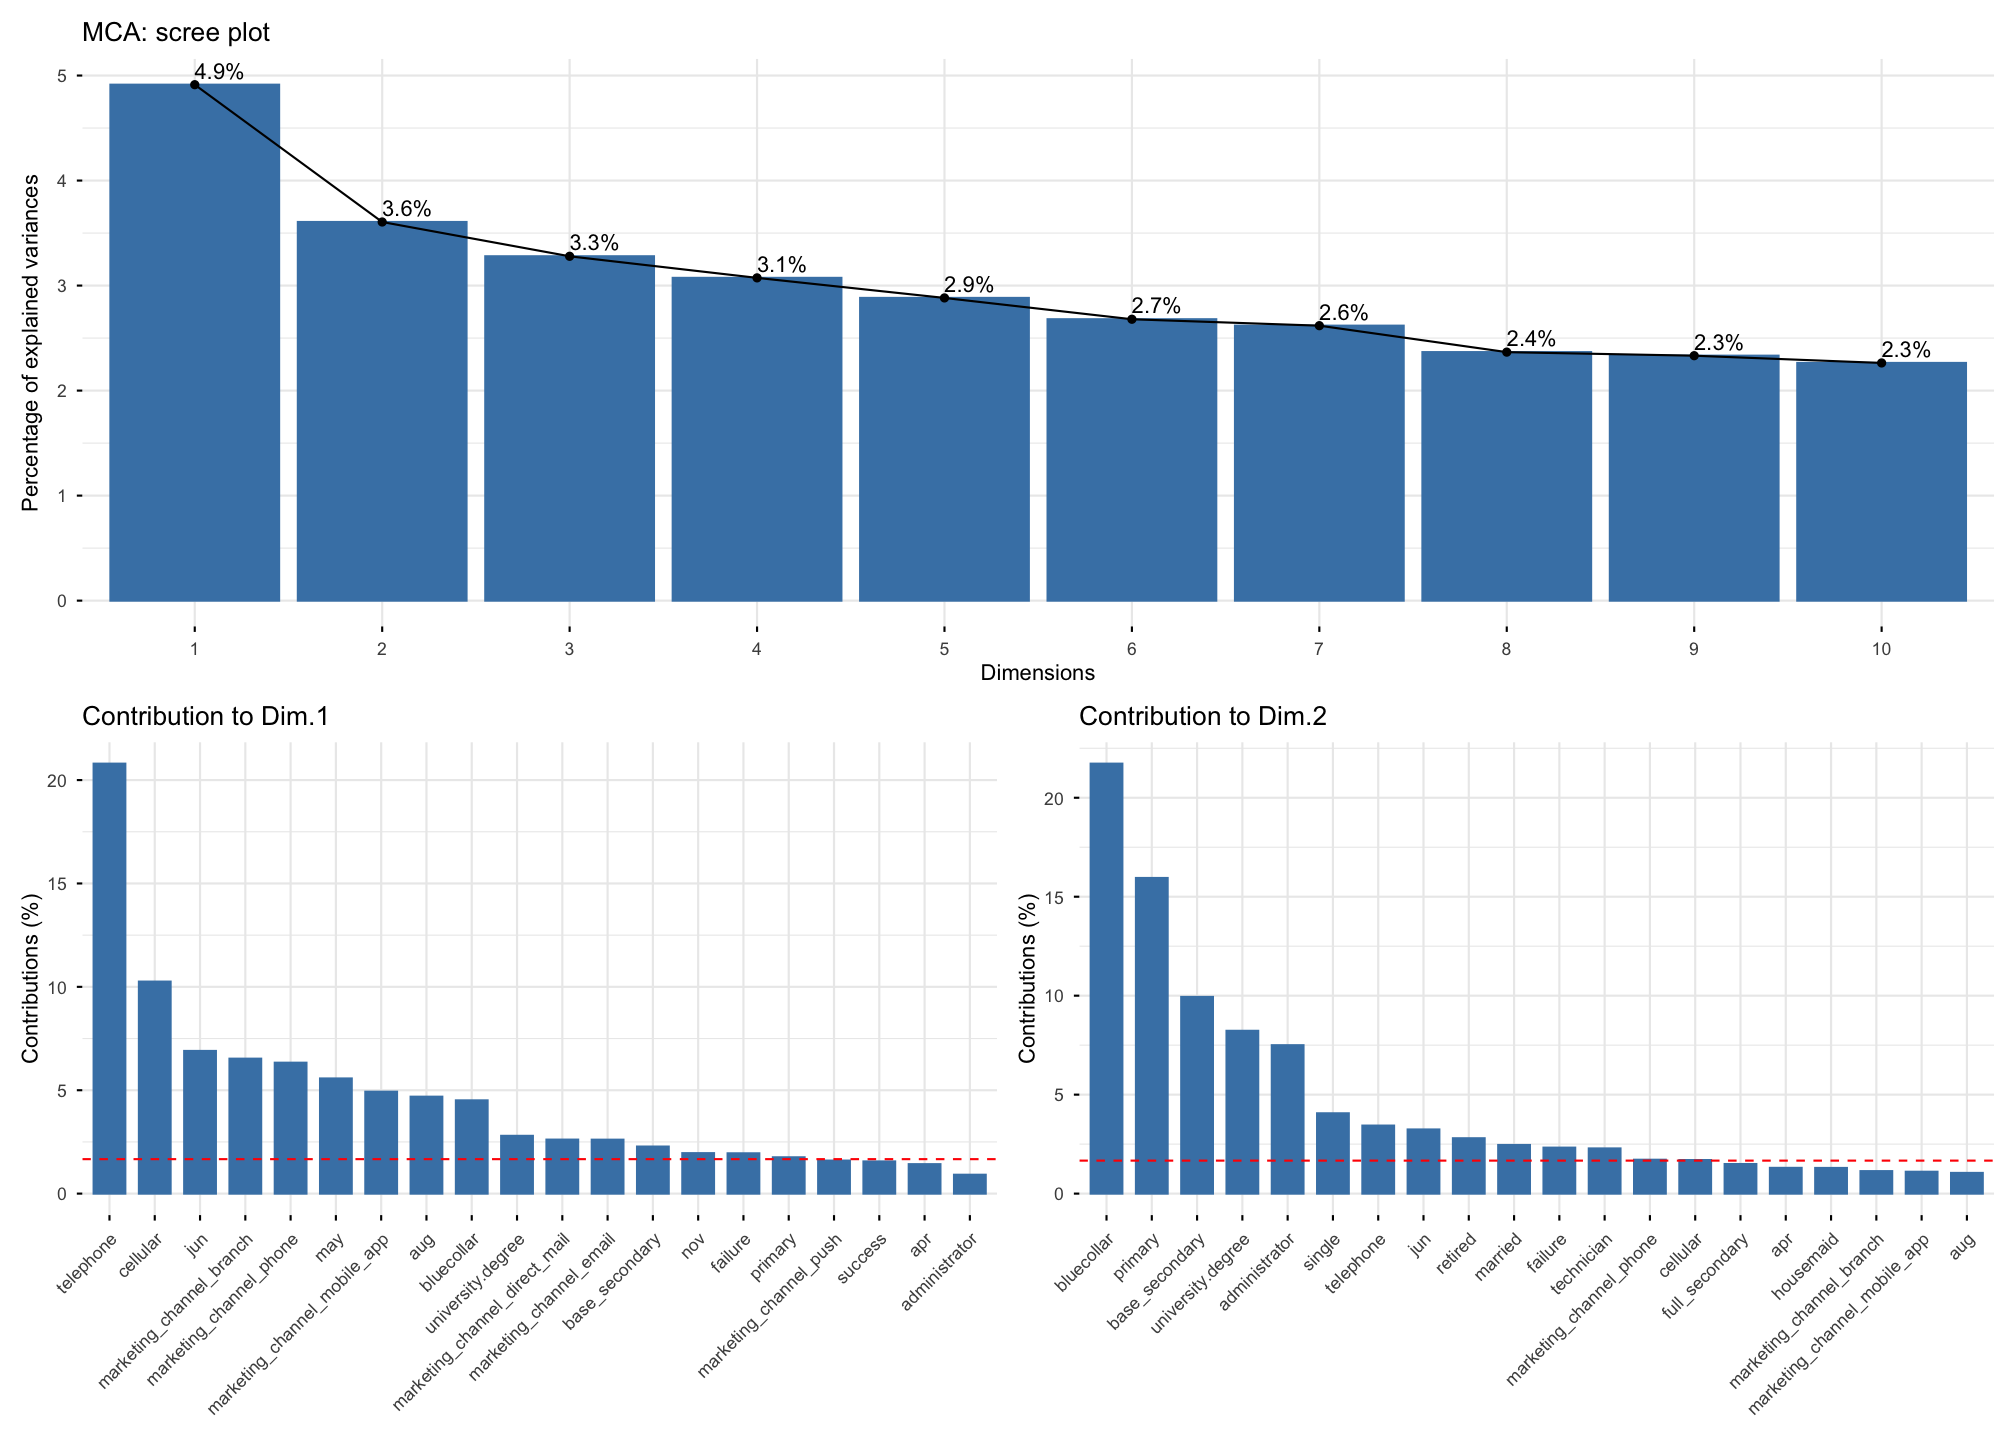

In [17]:
p_scree <- fviz_screeplot(mca_res, addlabels = TRUE, title = "MCA: scree plot")
p_contrib1 <- fviz_contrib(mca_res, choice = "var", axes = 1, top = 20, title = "Contribution to Dim.1")
p_contrib2 <- fviz_contrib(mca_res, choice = "var", axes = 2, top = 20, title = "Contribution to Dim.2")

patchwork::wrap_plots(
    p_scree,
    patchwork::wrap_plots(p_contrib1, p_contrib2, nrow = 1),
    ncol = 1,
    heights = c(1.2, 1)
)

Заметим, что первые две оси объясняют относительно небольшую долю дисперсии. Это как раз следствие включения в анализ незначимых категорий. Стоило бы исключить категории с низким vtest.

Вклады категорий в первые две компоненты согласуются с предыдущими выводами.

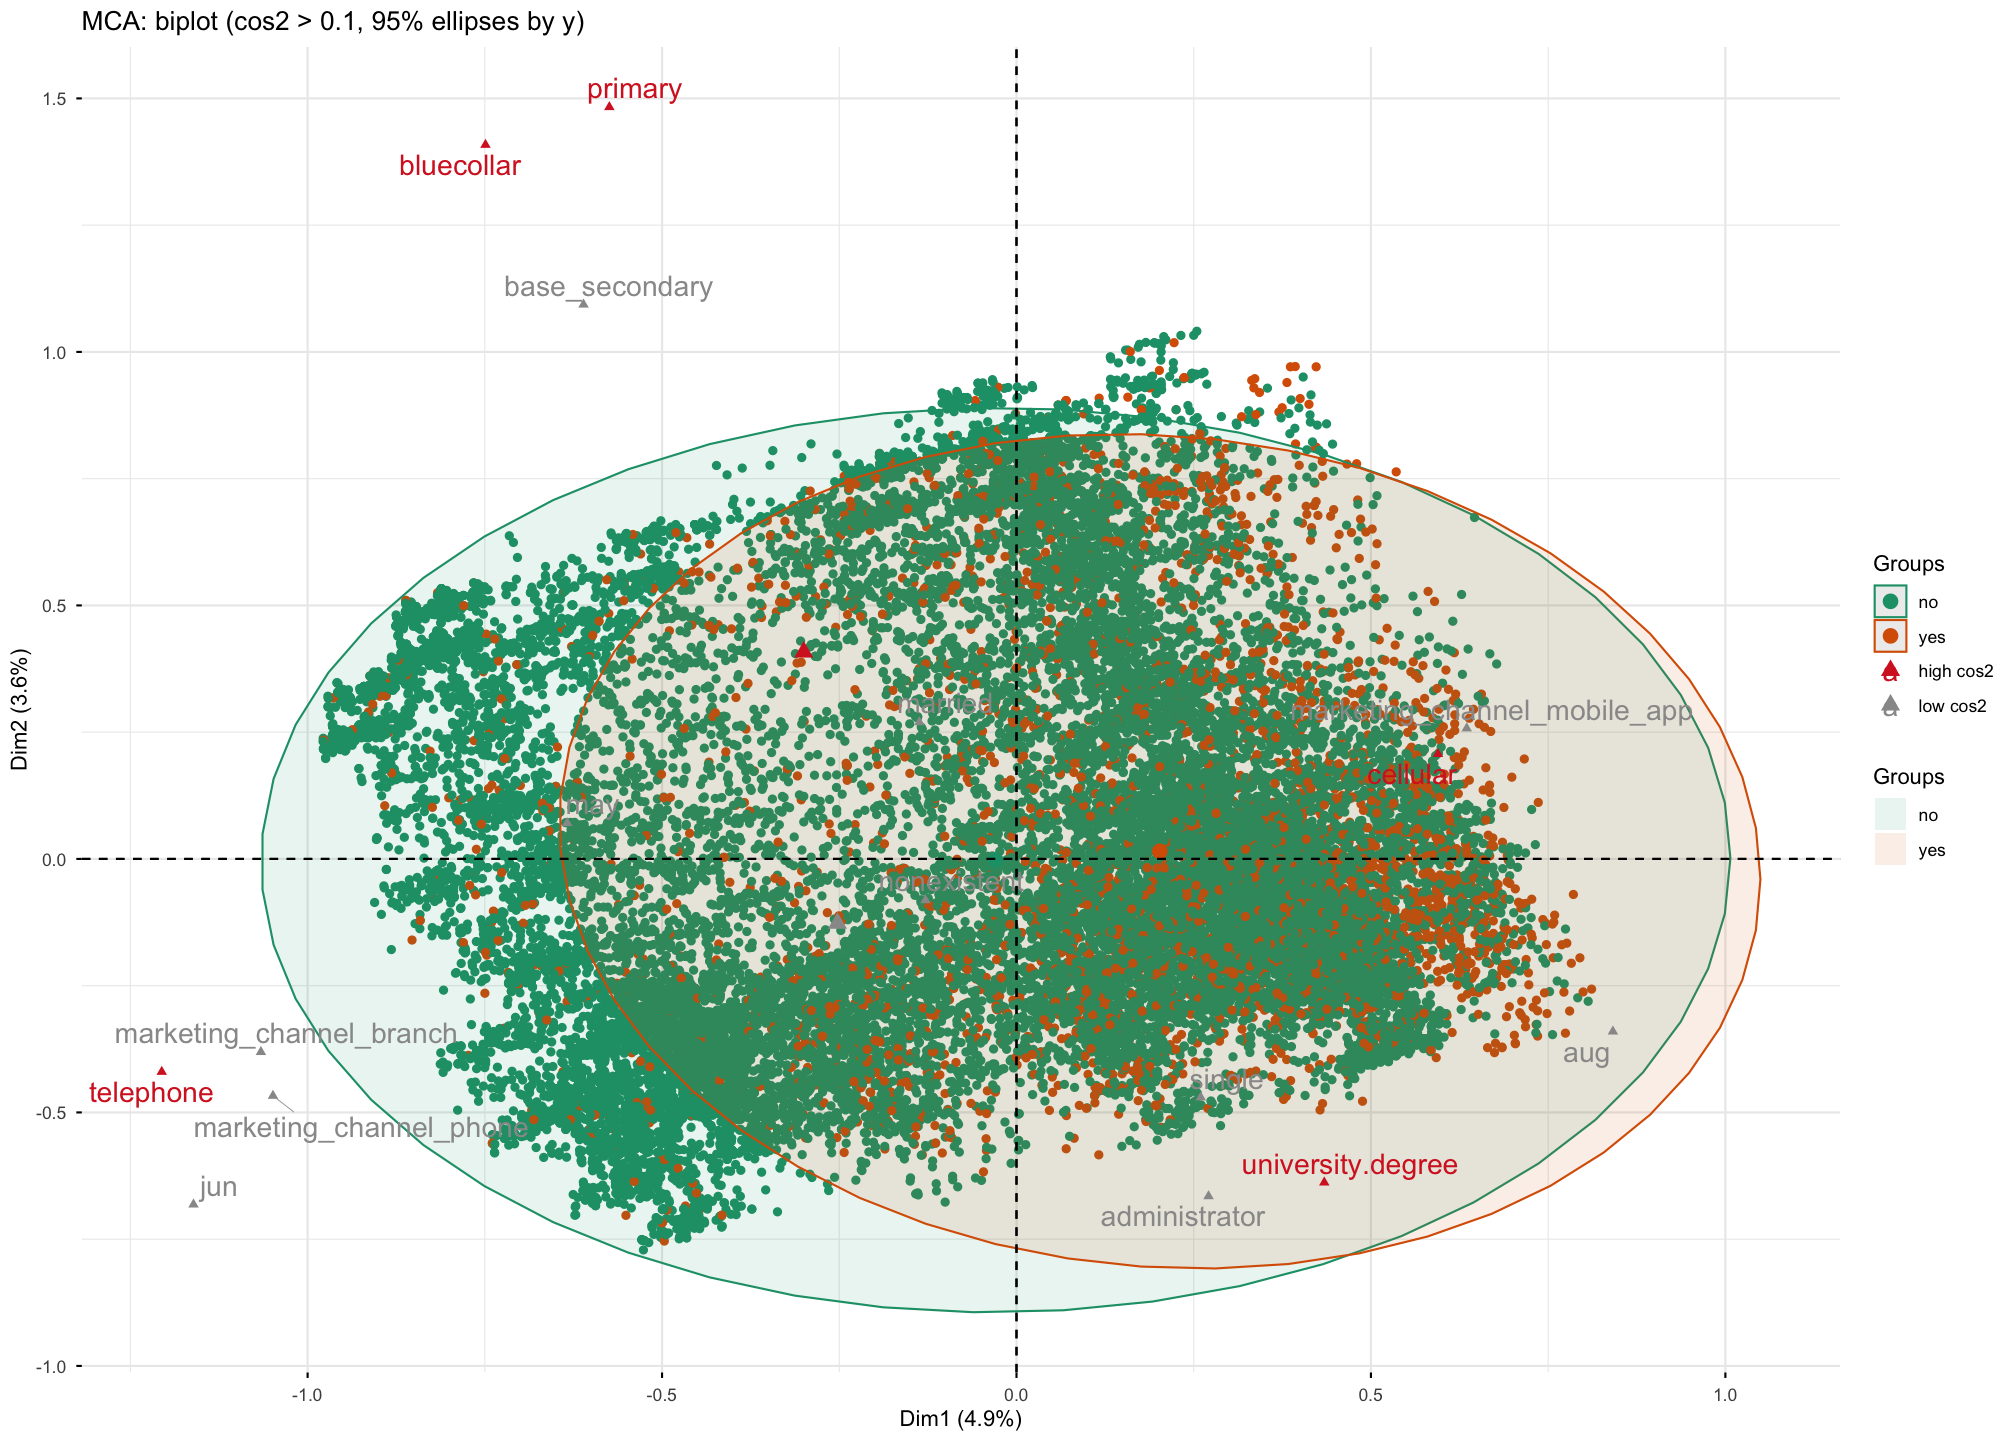

In [18]:
options(ggrepel.max.overlaps = Inf)

fviz_mca_biplot(
    mca_res,
    repel = TRUE,
    geom.ind = "point",
    habillage = df_mca$y,
    select.var = list(cos2 = 0.1),
    col.var = ifelse(rownames(mca_res$var$coord) %in% high_cos2, "high cos2", "low cos2"),
    addEllipses = TRUE,
    ellipse.level = 0.95,
    labelsize = 5,
    palette = c("#1B9E77", "#D95F02", "#D62728", "gray60"),
    title = "MCA: biplot (cos2 > 0.1, 95% ellipses by y)"
)

95% эллипсы для `y=yes` и `y=no` сильно перекрываются: MCA плохо разделяет целевую переменную. Тем не менее есть некоторая область, где эллипсы не пересекаются; особенно для класса "no". Учитывая, что эта зона вытянута в основном по первой оси, можно сделать вывод, что тип связи `telephone` скорее ведет к тому, что клиент не отклинется на кампанию. Это согласуется и с выводами из задания 1.

Маркетинговые гипотезы:
1. У клиентов с типом связи `cellular` выше вероятность отклика. Целесообразно переводить общение со всеми клиентами на этот тип связи.
2. Данные явно сегментированы по образованию/профессии. Хотя явного влияния сегмента на конверсию не обнаружено, маркетинговую кампанию вероятно стоит вести с учетом этим сегментов, корректировать предложение под конкретных клиентов соответствующим образом.

## Задание 3 (3 балла)

В этой части вы будете работать с методологией FAMD, деревьями решений и kmeans/k-medoids для эффективной сегментации по числовым и категориальным признакам

**Ожидаемый результат**
1. Профили кластеров, включая средние/модальные значения ключевых признаков по
сегментам (общий комментарий)
2. Сравнение Silhouette для разных подвыборок наблюдений (K-means vs K-medoids).
Графики + комментарий.
3. FAMD-би-плот с окраской по кластерам и эллипсами. Визуализация дерева решений
(rpart.plot) + текстовые правила сегментации (если получится)
4. Вопрос для отчета: «А точно ли правила из DT совпадают с логикой осей FAMD?
Как объяснить руководителю, что K-medoids дал более устойчивые сегменты, чем
K-means, несмотря на большее время расчёта? Почему деревья «игнорируют» некоторые переменные при построении правил?»

**Подготовьте данные для FAMD: отберите числовые и категориальные признаки. Запустите FAMD, извлеките координаты первых 5–7 компонент. Определите оптимальное K
для кластерного анализа через Elbow и Silhouette. Далее вам необходимо провести процедуру kmeans (если берете только числовые характеристики) ИЛИ K-medoids (если еще
и категориальные фичи). Лучше провести это на разных подвыборках (либо взять более крупную). Проведите простой анализ структуры полученных кластеров. Для этого
уделите внимание кросс-таблицам с акцентом на adjusted standartized residuals и вертикальные доли. Вас должны интересовать пересечения переменных с кластерными центрами по asr > 2.1. Затем попробуйте построить дерево решений, где зависимой переменной является переменная кластерных центров (отдельно можно проверить еще и Targetпеременную y). Для этого создайте целевую переменную cluster_id. Обучите rpart()
(Decision Tree) на исходных признаках, предсказывая принадлежность к кластерам. Визуализируйте дерево и выпишите 2–3 ключевых правила для каждого сегмента. Попробуйте
выполнить это на подвыборках наблюдений. Сравните центры кластеров и силуэты.**

Признаки будем брать щедро, работает в целом не долго. Уберем следующие признаки:
- `y` - целевая переменная; это не то, что мы хотим получить от FAMD. Хотим сегменты клиентов, а не просто разделить их по конверсии.
- `default` - куча пропусков, а там, где не пропуски, сильно кореллирует с `y`
- `day_of_week` - как показали прошлые задания, не дает интересных результатов
- `campaign_push` - сильно кореллирует с `campaign_email`

In [19]:
set.seed(SEED)

numeric_famd <- setdiff(numeric_variables, c("campaign_push"))
category_famd <- setdiff(category_variables, c("y", "default", "day_of_week"))

df_famd <- mutate(
    select(df_full, all_of(c(numeric_famd, category_famd))),
    across(all_of(category_famd), ~ ifelse(is.na(.), "missing", as.character(.)))
)

famd_res <- FAMD(df_famd, ncp = 10, graph = FALSE)
famd_res$eig[1:10, ]

,eigenvalue,percentage of variance,cumulative percentage of variance
comp 1,5.432196,8.487806,8.487806
comp 2,2.615319,4.086436,12.574242
comp 3,2.564178,4.006527,16.580769
comp 4,2.164732,3.382393,19.963162
comp 5,1.996075,3.118867,23.082030
comp 6,1.709833,2.671614,25.753644
comp 7,1.589933,2.484270,28.237914
comp 8,1.500746,2.344916,30.582830
comp 9,1.421109,2.220483,32.803313
comp 10,1.381905,2.159226,34.962539


Возьмем 6 компонент, которые объясняют примерно четверть дисперсии.

In [20]:
coords <- famd_res$ind$coord[, 1:6]

Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 1959400)”
Warning message:
“did not converge in 10 iterations”
Warning message:
“did not converge in 10 iterations”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 1959400)”
Warning message:
“did not converge in 10 iterations”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 1959400)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 1959400)”


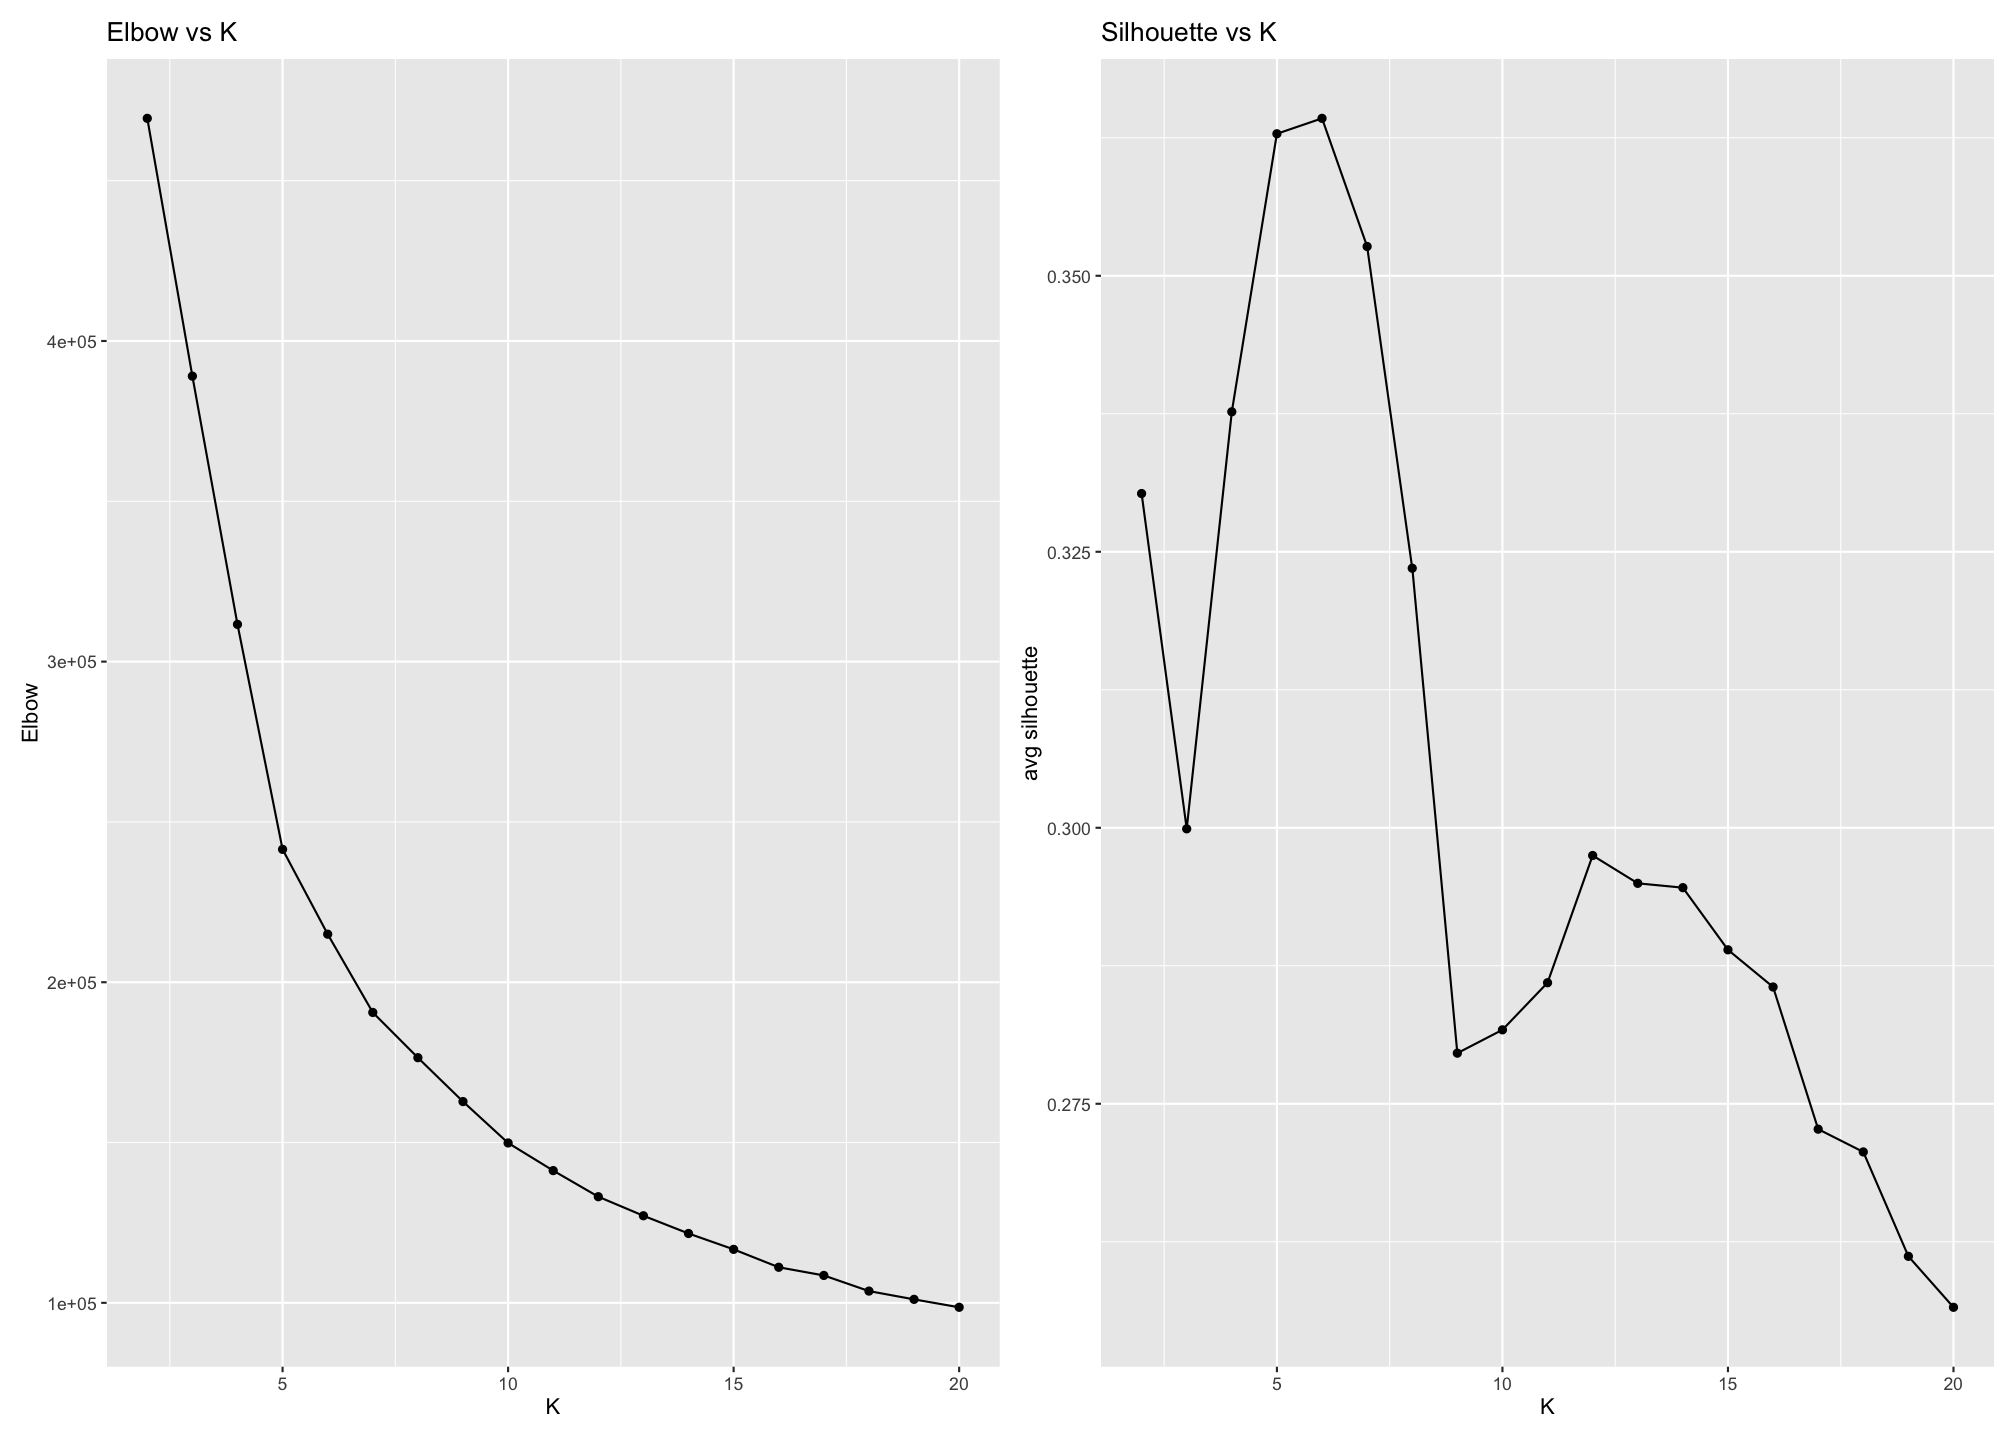

In [21]:
set.seed(SEED)

min_k <- 2
max_k <- 20
elbow <- rep(NA_real_, max_k - min_k + 1)
silhouette <- rep(NA_real_, max_k - min_k + 1)
for (k in min_k:max_k)
{
    kmeans <- kmeans(coords, centers = k, nstart = 25)
    elbow[k - min_k + 1] <- kmeans$tot.withinss
    silhouette[k - min_k + 1] <- mean(silhouette(kmeans$cluster, dist(coords))[, 3])
}

elbow <- ggplot(tibble(k = min_k:max_k, elbow = elbow), aes(k, elbow)) +
    geom_line() + geom_point() +
    labs(title = "Elbow vs K", x = "K", y = "Elbow")
silhouette <- ggplot(tibble(k = min_k:max_k, silh = silhouette), aes(k, silh)) +
    geom_line() + geom_point() +
    labs(title = "Silhouette vs K", x = "K", y = "avg silhouette")
patchwork::wrap_plots(elbow, silhouette, ncol = 2)

Оптимальным значением K кажется 6: silhouette достигает максимума, а межкластерные расстояния начинают выходить на плато.

In [22]:
set.seed(SEED)

kmeans_result <- kmeans(coords, centers = 6, nstart = 25)
df_famd$cluster_id <- factor(kmeans_result$cluster)

silhouette <- mean(silhouette(kmeans_result$cluster, dist(coords))[, 3])
print(silhouette)
print(table(kmeans_result$cluster))
print(kmeans_result$centers)

Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 1959400)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 1959400)”


[1] 0.3643968

    1     2     3     4     5     6 
13325 11797   930  1423  2329  9384 
       Dim.1       Dim.2      Dim.3       Dim.4       Dim.5       Dim.6
1  0.8157951 -0.06745548 -1.7585550  0.36261923 -0.07118306  0.36540247
2  2.2138814  0.22837962  1.4030083  0.12334487 -0.37433642 -0.30676434
3  0.2966891  0.08144886  1.0792320 -0.03718684  8.95591445  0.09154064
4 -5.5082717  1.86593937  2.2432256  4.83326172 -0.42146198  2.16004469
5 -2.8892558  2.55706731 -0.4979147 -0.94880081 -0.13138113 -0.96524738
6 -2.4186063 -1.11697986  0.4097723 -1.16372456 -0.21938538 -0.23027538


silhouette достаточно плохой, лишь немного превосходит 1/3. Данные не очень хорошо кластеризуются.

Структура кластеров также очень неравномерна, выделились 3 больших кластера по ~10000 объектов.

In [23]:
set.seed(SEED)

for (sample_size in c(7500, 10000, 12500, 15000, 17500, 20000, 25000, 30000, 35000)) {
    df_sub <- df_famd[sample(nrow(df_famd), sample_size), ]
    famd_sub <- FAMD(df_sub, ncp = 10, graph = FALSE)
    coords_sub <- famd_sub$ind$coord[, 1:6]
    kmeans_sub <- kmeans(coords_sub, centers = 6, nstart = 25)
    print(table(kmeans_sub$cluster))
    print(kmeans_sub$centers)
}


   1    2    3    4    5    6 
 179 2551 1812  267 2254  437 
       Dim.1      Dim.2       Dim.3      Dim.4      Dim.5      Dim.6
1  0.2809971  1.2836989  0.30877951 10.9755159 -0.2933085  0.3470927
2  0.8948673 -2.1092119  0.62212444 -0.1083483 -0.6091836  0.1924504
3 -2.6745603  0.2018241 -2.12296256 -0.2084417  0.2153381  0.1133609
4 -6.1477545  3.5007841  5.47094545 -0.9021697 -3.9973650  1.2026312
5  2.4519011  1.8053476 -0.01750387 -0.4650269  0.2593324 -0.2343292
6 -3.1394428 -0.5008028  1.79223910 -0.0491405  3.8880962 -1.2617962

   1    2    3    4    5    6 
3445  244 2990  379 2348  594 
       Dim.1       Dim.2      Dim.3      Dim.4      Dim.5       Dim.6
1  0.9087045 -2.04246232  0.6876438 -0.1332598 -0.6539126  0.21555151
2  0.3391896  1.53651430  2.2155152 10.5188751  0.6618105  0.10374016
3  2.4275963  1.81702209 -0.2173325 -0.5215251  0.2156463 -0.25896847
4 -6.1439062  3.67165950  4.4483725 -1.3075876 -4.3572692  0.95053109
5 -2.6573191  0.02210093 -2.1731198  0.18

Структура кластеров в целом кажется одинаковой при разных размерах выборки: три больших кластера и три маленьких. Центры кластеров также достаточно стабильны, если пренебречь их "перенумерацией". Далее будем исследовать результаты на полной выборке.

In [24]:
summarise(
    group_by(df_famd, cluster_id),
    n = n(),
    across(all_of(numeric_famd), ~ mean(.x, na.rm = TRUE))
)

cluster_id,n,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,involvement_score,account_tenure,market_sentiment,seasonal_promo_index,account_balance,customer_rating,campaign_email
<fct>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,13325,39.92765,250.1166,2.825741,999.00000,1.771107e-02,1.0771107,93.59727,-40.21821,4.7817314,5221.140,49.84165,479.1779,2.4009831,45.22474,4561.169,2.789869,3.482326
2,11797,40.27354,255.9480,2.830465,999.00000,8.476731e-05,1.2041027,94.14728,-38.51020,4.8789325,5204.907,50.09228,483.3709,2.4872730,78.94488,4540.063,2.753497,3.525473
3,930,39.93441,250.3925,2.590323,973.38602,1.548387e-01,0.1327957,93.63257,-40.32118,3.6840677,5168.702,50.07097,474.3495,1.9030914,63.32419,4568.003,2.778495,3.358065
4,1423,41.49051,319.9206,1.846803,19.96838,1.689389e+00,-2.0858046,93.35333,-38.31623,0.9839564,5028.440,48.59494,497.5446,0.4157175,48.65207,4622.264,2.747716,2.828531
5,2329,56.53070,273.0245,1.876342,995.16788,3.829970e-01,-2.1604981,92.93426,-37.53590,1.3509476,5066.115,50.34113,692.1808,0.6162233,41.98325,4476.541,2.760842,2.820953
6,9384,35.42722,259.9336,2.153879,998.89450,3.314152e-01,-1.8706522,93.01224,-44.48555,1.3399208,5088.017,50.33425,421.5217,0.6227045,62.12660,4540.891,2.774510,3.081841


4 кластер явно выделяется по признакам `pdays` и `previous`. Вероятно, туда попали те, кому еще не звонили.

Явные отличия наблюдаются по признаку `emp.var.rate`: выделяются кластеры 1-2, 3 и 4-5-6.

Некоторое партиционирование происходит по признаку `euribor3m`: кластеры 1-2-3 имеют большое значение, а 4-5-6 относительно маленькое.

5 кластер выделяется по признаку `account_tenure`. К этому сегменту отнесены "старички".

По другим признакам также наблюдаются отличия, хотя и не столь явные. В целом, явно видна качественная разница между кластерами 1-2-3 и 4-5-6

In [25]:
profile_cat <- pivot_longer(
    mutate(select(df_famd, cluster_id, all_of(category_famd)), y = df_full$y),
    -cluster_id,
    names_to = "var",
    values_to = "category"
)
profile_cat <- mutate(
    group_by(count(profile_cat, var, category, cluster_id), var, cluster_id),
    share = n / sum(n)
)
profile_cat <- pivot_wider(
    ungroup(profile_cat),
    id_cols = c(var, category),
    names_from = cluster_id,
    values_from = share,
    names_prefix = "cluster_",
    values_fill = 0
)
arrange(mutate(profile_cat, across(starts_with("cluster_"), ~ round(., 2))), var, category)

var,category,cluster_1,cluster_2,cluster_3,cluster_4,cluster_5,cluster_6
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
contact,cellular,0.93,0.00,0.56,0.92,0.89,0.90
contact,telephone,0.07,1.00,0.44,0.08,0.11,0.10
education,base_secondary,0.12,0.19,0.15,0.08,0.06,0.17
education,full_secondary,0.21,0.24,0.22,0.22,0.13,0.27
education,illiterate,0.00,0.00,0.00,0.00,0.00,0.00
education,missing,0.03,0.05,0.04,0.07,0.07,0.03
education,primary,0.12,0.21,0.18,0.12,0.27,0.11
education,professional.course,0.15,0.11,0.12,0.13,0.15,0.11
education,university.degree,0.36,0.21,0.28,0.38,0.31,0.30


По категориальным признакам также наблюдаются явные отличия кластеров.
- По признаку `contact`: во всех кластерах, кроме 3, преобладает один из типов связи.
- Почти все объекты с пропущенным `housing` и  `loan` попали в 3 кластер; это и является его отличительное чертой.
- 5 категория отлично выделяется по признаку `poutcome`: содержит почти все объекты, для которых прошлая кампания была успешна
- 4 кластер - единственный с высокой конверсией

In [26]:
df_asr <- mutate(df_famd, y = factor(df_full$y, levels = c("no", "yes")))

for (variable in category_famd) {
    crosstab <- table(df_asr$cluster_id, df_asr[[variable]])
    chi <- chisq.test(crosstab)
    r_m <- rowSums(crosstab) / sum(crosstab)
    c_m <- colSums(crosstab) / sum(crosstab)
    asr <- (crosstab - chi$expected) / sqrt(chi$expected * outer(1 - r_m, 1 - c_m))
    
    print(variable)
    asr <- round(asr, 2)
    asr[abs(asr) <= 2.1] <- NA
    print(asr)
}

[1] "job"
   
    administrator bluecollar entrepreneur housemaid management missing retired
  1         11.93     -17.67                   4.16       3.55          -14.17
  2        -14.34      24.41         3.15      2.94      -2.50    5.89   -8.53
  3                                                                           
  4          4.65     -12.95        -4.00                         2.27   13.09
  5        -10.88     -17.68                   7.66       9.23    2.68   75.46
  6          6.85       8.30        -2.81    -12.56      -6.38   -6.31  -22.78
   
    selfemployed services student technician unemployed
  1                 -6.53  -15.69      20.48           
  2                  8.94  -11.88     -10.50           
  3                                                    
  4        -2.73    -5.85   20.57                  4.71
  5                -12.46   -7.37      -7.10       3.56
  6                  6.88   25.34      -6.78           


Warning message in chisq.test(crosstab):
“Chi-squared approximation may be incorrect”


[1] "marital"
   
    divorced married missing single
  1     4.00                  -2.54
  2            17.27         -18.75
  3                                
  4    -2.54   -6.50           8.72
  5    10.88   16.95         -26.12
  6    -9.78  -24.67          33.60


Warning message in chisq.test(crosstab):
“Chi-squared approximation may be incorrect”


[1] "education"
   
    base_secondary full_secondary illiterate missing primary
  1         -11.84          -6.62              -5.26  -12.66
  2          14.10           2.68               4.35   17.80
  3                                                         
  4          -7.50                              4.97   -4.19
  5         -11.57         -11.46               6.35   15.95
  6           7.51          11.46              -4.47  -12.82
   
    professional.course university.degree
  1                9.15             20.93
  2               -5.66            -25.28
  3                                      
  4                                  7.27
  5                3.16                  
  6               -6.00                  
[1] "housing"
   
    missing     no    yes
  1  -22.28  -3.64  10.45
  2  -20.37  21.93 -15.61
  3  196.88 -28.07 -32.34
  4   -4.26          3.26
  5   -7.80  -2.94   5.32
  6  -17.41  -7.03  12.34
[1] "loan"
   
    missing     no    yes
  1  -22.28   

Warning message in chisq.test(crosstab):
“Chi-squared approximation may be incorrect”


[1] "month"
   
        apr     aug     dec     jul     jun     mar     may     nov     oct
  1  -37.01   80.92   -9.41   96.82  -54.69  -16.40 -100.93   54.03  -17.18
  2  -33.88  -52.92   -8.60  -46.18   82.65  -14.99   75.55  -42.69  -14.23
  3                                    4.75                   -2.51        
  4                   15.89   -9.71   -3.19   15.01  -14.20    3.46   24.52
  5   16.51    5.00   25.23  -16.84  -12.78   15.46  -21.78    7.07   42.07
  6   67.85  -35.51          -43.57  -21.35   19.20   48.64  -18.63        
   
        sep
  1  -16.86
  2  -15.41
  3        
  4   32.37
  5   34.82
  6        
[1] "poutcome"
   
    failure nonexistent success
  1  -40.00       49.22  -26.35
  2  -44.09       51.66  -24.09
  3                       -2.39
  4              -96.57  186.42
  5   35.43      -26.60   -9.23
  6   72.26      -53.31  -20.60
[1] "primary_channel"
   
    branch email mobile_app phone  web
  1                                   
  2              

По многим переменным выделяется 3 кластер: практически нет значимых категорий.

Почти все категории переменных `housing`, `loan`, `contact`, `poutcome` значимы во всех кластерах. Это кореллирует с предыдущими выводами: кластеры во многом выделяются именно по этим переменным. Переменные `primary_channel` и `has_opted_out`, в свою очередь, незначимы: они не являются определяющими признаками в полученных сегментах.

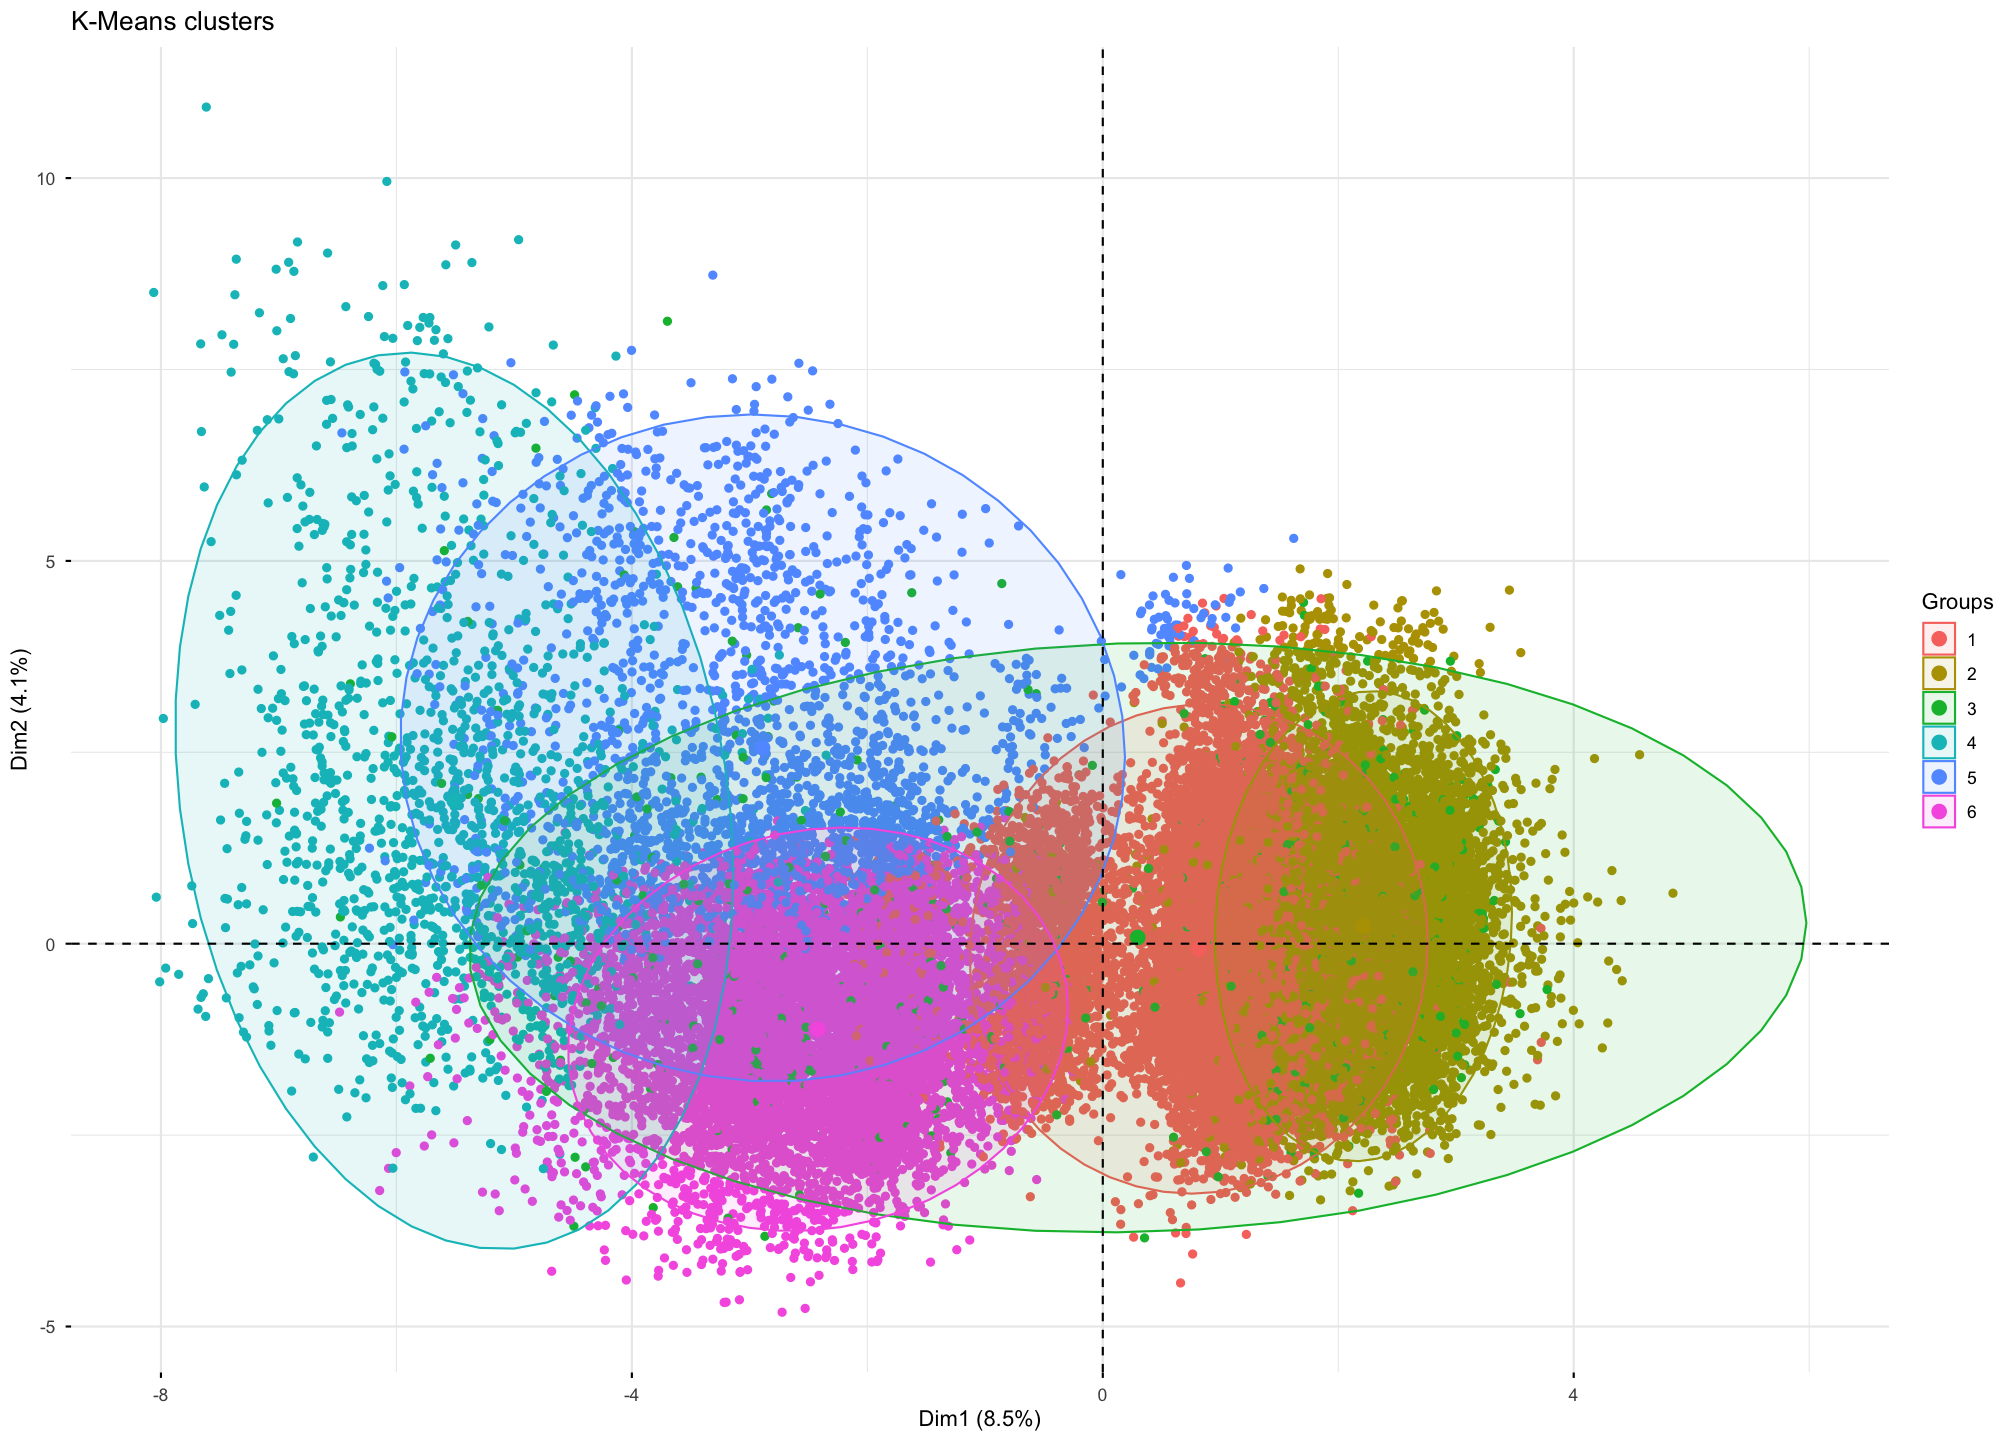

In [27]:
fviz_famd_ind(
    famd_res,
    label = "none",
    invisible = "quali.var",
    habillage = df_famd$cluster_id,
    addEllipses = TRUE,
    ellipse.level = 0.95,
    title = "K-Means clusters"
)

На таком графике видны различия между большинстом кластеров. Странным получился лишь 3 кластер, который пересекает все остальные. 


=== n = 39188 ===
Accuracy (cluster_id): 0.934 
Leaf 8 , cluster 2 cons.price.idx>=93.96 & emp.var.rate>=0 & housing=no,yes 
Leaf 9 , cluster 3 cons.price.idx>=93.96 & emp.var.rate>=0 & housing=missing 
Leaf 10 , cluster 4 cons.price.idx>=93.96 & emp.var.rate< 0 & pdays< 513 
Leaf 11 , cluster 6 cons.price.idx>=93.96 & emp.var.rate< 0 & pdays>=513 
Leaf 12 , cluster 1 cons.price.idx< 93.96 & emp.var.rate>=-0.15 & housing=no,yes 
Leaf 13 , cluster 3 cons.price.idx< 93.96 & emp.var.rate>=-0.15 & housing=missing 
Leaf 14 , cluster 4 cons.price.idx< 93.96 & emp.var.rate< -0.15 & pdays< 510 
Leaf 30 , cluster 5 cons.price.idx< 93.96 & emp.var.rate< -0.15 & pdays>=510 & age>=52.5 
Leaf 31 , cluster 6 cons.price.idx< 93.96 & emp.var.rate< -0.15 & pdays>=510 & age< 52.5 


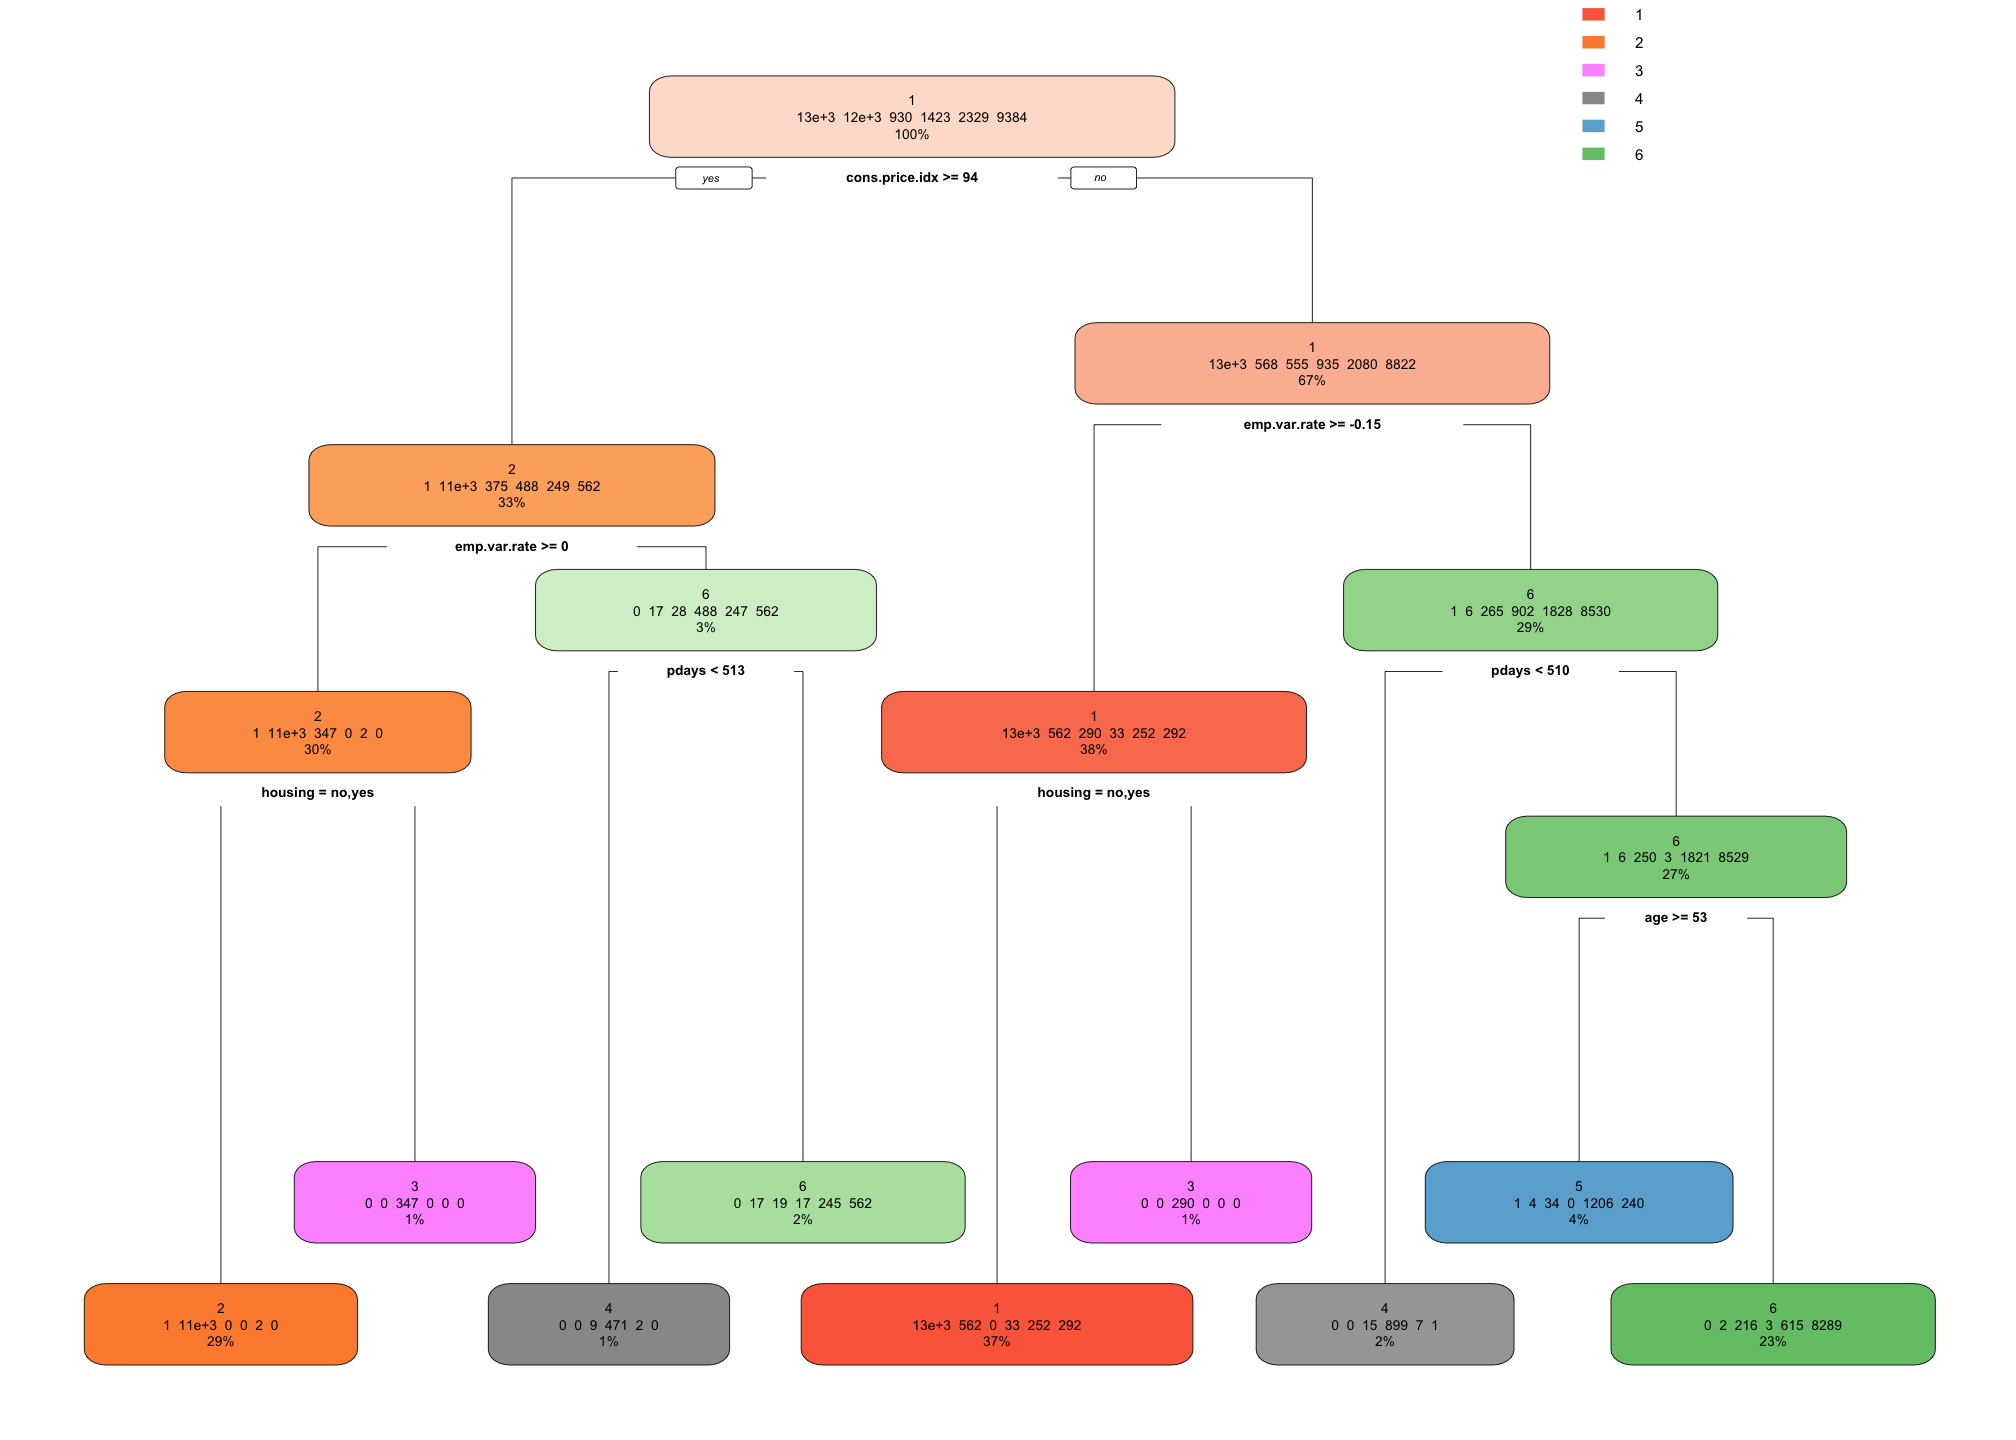

In [28]:
run_tree <- function(sample_size = nrow(df_famd), with_plot = TRUE) {
    set.seed(SEED)
    cat("\n=== n =", sample_size, "===\n")
    data_sub <- df_famd[sample(nrow(df_famd), sample_size), ]
    tree_fit <- rpart(cluster_id ~ ., data = data_sub, method = "class")

    if (with_plot) {
        rpart.plot(tree_fit, type = 2, extra = 101)
    }

    pred_cluster <- predict(tree_fit, data_sub, type = "class")
    acc_cluster <- mean(pred_cluster == data_sub$cluster_id)
    cat("Accuracy (cluster_id):", round(acc_cluster, 3), "\n")

    leaves <- as.numeric(rownames(tree_fit$frame[tree_fit$frame$var == "<leaf>", ]))
    leaf_class <- tree_fit$frame[tree_fit$frame$var == "<leaf>", "yval"]
    rules <- path.rpart(tree_fit, nodes = leaves, print.it = FALSE)
    for (i in seq_along(rules)) {
        cat(
            "Leaf", names(rules)[i],
            ", cluster", levels(data_sub$cluster_id)[leaf_class[i]],
            paste(rules[[i]][-1], collapse = " & "), "\n"
        )
    }
}

run_tree()

Признаки в решающих правилах оказались совсем другими, хотя точность предсказаний и достаточно нелпохая. Видимо, кластеры не описываются отдельными признаками, что мы пытались сделать ранее. Вероятнее, кластеры определяются наборами из двух-трех признаков. Также может быть проблема с кореллированными зависимостями, которые мы не обрабатывали: решающее дерево имеет свойство "размазывать" важность таких признаков.

Так, наиболее значимым для разделения объектов оказался индекс потребительских цен, среднее значение которого практически не отличается между кластерами.

In [29]:
set.seed(SEED)

for (sample_size in c(7500, 10000, 12500, 15000, 17500, 20000, 25000, 30000, 35000)) {
    run_tree(sample_size, FALSE)
}


=== n = 7500 ===
Accuracy (cluster_id): 0.932 
Leaf 8 , cluster 2 cons.price.idx>=93.96 & emp.var.rate>=0 & housing=no,yes 
Leaf 9 , cluster 3 cons.price.idx>=93.96 & emp.var.rate>=0 & housing=missing 
Leaf 10 , cluster 4 cons.price.idx>=93.96 & emp.var.rate< 0 & pdays< 513 
Leaf 11 , cluster 6 cons.price.idx>=93.96 & emp.var.rate< 0 & pdays>=513 
Leaf 12 , cluster 1 cons.price.idx< 93.96 & emp.var.rate>=-0.15 & housing=no,yes 
Leaf 13 , cluster 3 cons.price.idx< 93.96 & emp.var.rate>=-0.15 & housing=missing 
Leaf 14 , cluster 4 cons.price.idx< 93.96 & emp.var.rate< -0.15 & pdays< 508.5 
Leaf 30 , cluster 5 cons.price.idx< 93.96 & emp.var.rate< -0.15 & pdays>=508.5 & age>=50.5 
Leaf 31 , cluster 6 cons.price.idx< 93.96 & emp.var.rate< -0.15 & pdays>=508.5 & age< 50.5 

=== n = 10000 ===
Accuracy (cluster_id): 0.932 
Leaf 8 , cluster 2 cons.price.idx>=93.96 & emp.var.rate>=0 & housing=no,yes 
Leaf 9 , cluster 3 cons.price.idx>=93.96 & emp.var.rate>=0 & housing=missing 
Leaf 10 , cluste

Разделяющие правила достаточно стабильны при изменение размера выборки.

## Задание 4 (3 балла)

Контекст этой части самый важный. Здесь требуется ответить на итоговый вопрос:
что именно влияет на готовность клиента участвовать в новой маркетинговой кампании.

**Ожидаемый результат**
1. Сводная таблица рекомендаций: «сегмент → канал → оффер → ожидаемый эффект» + комментарий
2. Таблица «удалённых признаков + обоснование» + комментарий
3. Набор рекомендаций по таргету для отчета.

Разделите данные на train/test (70/30). Для CatBoost укажите cat_features, для остальных примените model.matrix() или one-hot encoding. Обучите 3 модели:
- RandomForest (обязательно)
- CatBoost (обязательно)
-  XGBoost или LightGBM (на выбор)

Настройте балансировку классов (scale_pos_weight, auto_class_weights или class_-
weight). Рассчитайте метрики на тесте: Accuracy, Precision, Recall, F1, ROC-AUC. Cравните время обучения и потребление памяти. Как CatBoost справляется с primary_channel и
job без предварительного кодирования? Повторите обучение лучших параметров на подвыборках наблюдений. Как меняется Test AUC и время обучения? Сформулируйте, какая
модель оптимальна по соотношению «качество / сложность / интерпретируемость»?

In [30]:
set.seed(SEED)

# Сделаем пропуски отдельными категориями. Из прошлых заданий кажется, что это должно сработать
# И удалим признак pdays. Ранее видели, что в нем больше пропусков, чем реальных значений
df_ml <- mutate(
    select(df_full, -y, -pdays),
    across(
        all_of(setdiff(category_variables, c("y", "pdays"))),
        ~ factor(ifelse(is.na(.), "missing", as.character(.)))
    )
)
df_ml_ohe <- model.matrix(~ ., data = df_ml)

train_idx <- as.vector(createDataPartition(df_full$y, p = 0.7, list = FALSE))

X_train <- df_ml[train_idx, ]
X_test <- df_ml[-train_idx, ]
cat("X_train:", dim(X_train), " X_test:", dim(X_test), "\n")

X_train_ohe <- df_ml_ohe[train_idx, ]
X_test_ohe <- df_ml_ohe[-train_idx, ]
cat("X_train_ohe:", dim(X_train_ohe), " X_test_ohe:", dim(X_test_ohe), "\n")

y_train <- as.integer(df_full$y[train_idx] == "yes")
y_test  <- as.integer(df_full$y[-train_idx] == "yes")
cat("y_train:", length(y_train), " y_test:", length(y_test), "\n")

X_train: 27433 30  X_test: 11755 30 
X_train_ohe: 27433 71  X_test_ohe: 11755 71 
y_train: 27433  y_test: 11755 


In [31]:
calc_metrics <- function(y_true, y_prob, threshold = 0.5) {
    y_pred <- factor(as.integer(y_prob > threshold), levels = c(0, 1))
    y_true <- factor(y_true, levels = c(0, 1))
    cm <- confusionMatrix(y_pred, y_true)
    roc_obj <- roc(y_true, y_prob, levels = c(0, 1), quiet = TRUE)
    tibble(
        Accuracy  = as.numeric(cm$overall["Accuracy"]),
        Precision = as.numeric(cm$byClass["Precision"]),
        Recall    = as.numeric(cm$byClass["Recall"]),
        F1        = as.numeric(cm$byClass["F1"]),
        ROC_AUC   = as.numeric(auc(roc_obj))
    )
}

drop_ohe <- function(mat, features) {
    cols <- colnames(mat)
    drop <- Reduce(`|`, lapply(features, function(f) cols == f | startsWith(cols, f)))
    mat[, !drop, drop = FALSE]
}

print_quality <- function(test_prob, train_prob, y_train = y_train) {
    m_tr <- rename_with(calc_metrics(y_train, train_prob), ~ paste0(., "_train"))
    m_te <- rename_with(calc_metrics(y_test, test_prob), ~ paste0(., "_test"))
    bind_cols(m_tr, m_te)
}

In [32]:
try_tf <- function(sample_size = length(y_train)) {
    set.seed(SEED)
    idx <- sample(length(y_train), sample_size)
    X <- X_train_ohe[idx, ]; y <- y_train[idx]
    fit <- randomForest(
        x = X, y = factor(y),
        ntree = 300,
        nodesize = 30,
        maxnodes = 1024,
        importance = TRUE,
        mtry = floor(sqrt(ncol(X))),
        classwt = 1 / prop.table(table(y))
    )
    imp <- importance(fit)
    list(
        y = y,
        train_prob = predict(fit, X, type = "prob")[, "1"],
        test_prob = predict(fit, X_test_ohe, type = "prob")[, "1"],
        importance = tibble(feature = rownames(imp), importance = imp[, "MeanDecreaseGini"])
    )
}

try_catboost <- function(sample_size = length(y_train)) {
    set.seed(SEED)
    idx <- sample(length(y_train), sample_size)
    X <- X_train[idx, ]; y <- y_train[idx]
    train_pool <- catboost.load_pool(data = X, label = y)
    test_pool  <- catboost.load_pool(data = X_test, label = y_test)
    fit <- catboost.train(
        learn_pool = train_pool,
        params = list(
            loss_function = "Logloss",
            iterations = 300,
            depth = 3,
            auto_class_weights = "Balanced",
            logging_level = "Silent"
        )
    )
    list(
        y = y,
        train_prob = catboost.predict(fit, train_pool, prediction_type = "Probability"),
        test_prob = catboost.predict(fit, test_pool, prediction_type = "Probability"),
        importance = tibble(
            feature = names(X),
            importance = as.numeric(catboost.get_feature_importance(fit, train_pool))
        )
    )
}

try_xgboost <- function(sample_size = length(y_train)) {
    set.seed(SEED)
    idx <- sample(length(y_train), sample_size)
    X <- X_train_ohe[idx, ]; y <- y_train[idx]
    xgb_train <- xgb.DMatrix(data = X, label = y)
    xgb_test  <- xgb.DMatrix(data = X_test_ohe, label = y_test)
    fit <- xgb.train(
        params = list(
            objective = "binary:logistic",
            max_depth = 3,
            min_child_weight = 10,
            scale_pos_weight = sum(y == 0) / sum(y == 1)
        ),
        data = xgb_train,
        nrounds = 100,
        verbose = 0
    )
    imp <- as_tibble(xgb.importance(model = fit))
    list(
        y = y,
        train_prob = predict(fit, xgb_train),
        test_prob = predict(fit, xgb_test),
        importance = tibble(feature = imp$Feature, importance = imp$Gain)
    )
}

try_lightgbm <- function(sample_size = length(y_train)) {
    set.seed(SEED)
    idx <- sample(length(y_train), sample_size)
    X <- X_train_ohe[idx, ]; y <- y_train[idx]
    fit <- lgb.train(
        params = list(
            objective = "binary",
            num_leaves = 15,
            min_data_in_leaf = 50,
            scale_pos_weight = sum(y == 0) / sum(y == 1),
            verbose = -1
        ),
        data = lgb.Dataset(data = X, label = y),
        nrounds = 100
    )
    imp <- as_tibble(lgb.importance(fit))
    list(
        y = y,
        train_prob = predict(fit, X),
        test_prob = predict(fit, X_test_ohe),
        importance = tibble(feature = imp$Feature, importance = imp$Gain)
    )
}

In [33]:
measure_quality <- function(fn) {
    pid <- Sys.getpid(); sentinel <- tempfile(); log_file <- tempfile()
    file.create(sentinel)
    on.exit({
        if (file.exists(sentinel)) file.remove(sentinel)
        if (file.exists(log_file)) file.remove(log_file)
    }, add = TRUE)

    gc(full = TRUE)
    rss_before <- as.numeric(system(sprintf("ps -o rss= -p %d", pid), intern = TRUE))
    system(
        sprintf(
            "while [ -e %s ]; do ps -o rss= -p %d 2>/dev/null; sleep 0.02; done > %s",
            shQuote(sentinel), pid, shQuote(log_file)
        ),
        wait = FALSE
    )

    timer <- system.time({ metrics <- fn() })
    file.remove(sentinel)
    Sys.sleep(0.1)

    peak_rss <- max(as.numeric(readLines(log_file)))
    list(
        metrics = metrics,
        time_sec = as.numeric(timer["elapsed"]),
        mem_mb = (peak_rss - rss_before) / 1024
    )
}

try_all <- function(sample_size = nrow(X_train)) {
    runs <- list(
        RandomForest = measure_quality(function() try_tf(sample_size)),
        CatBoost     = measure_quality(function() try_catboost(sample_size)),
        XGBoost      = measure_quality(function() try_xgboost(sample_size)),
        LightGBM     = measure_quality(function() try_lightgbm(sample_size))
    )
    bind_rows(lapply(names(runs), function(name) {
        r <- runs[[name]]
        bind_cols(
            tibble(model = name),
            print_quality(r$metrics$test_prob, r$metrics$train_prob, r$metrics$y),
            tibble(time_sec = r$time_sec, mem_mb = r$mem_mb)
        )
    }))
}

In [34]:
try_all()

model,Accuracy_train,Precision_train,Recall_train,F1_train,ROC_AUC_train,Accuracy_test,Precision_test,Recall_test,F1_test,ROC_AUC_test,time_sec,mem_mb
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
RandomForest,0.8753326,1.0000000,0.8595021,0.9244433,0.9920682,0.8509570,0.9868731,0.8432557,0.9094293,0.9372345,104.264,3.375000
CatBoost,0.8670215,0.9914506,0.8575302,0.9196405,0.9557933,0.8640578,0.9893629,0.8560061,0.9178660,0.9465153,2.432,133.773438
XGBoost,0.8735829,0.9940826,0.8626654,0.9237232,0.9630535,0.8661846,0.9885286,0.8591698,0.9193209,0.9454608,0.273,4.011719
LightGBM,0.8755878,0.9953609,0.8638156,0.9249346,0.9650510,0.8644832,0.9888274,0.8569648,0.9181860,0.9473943,0.461,12.148438


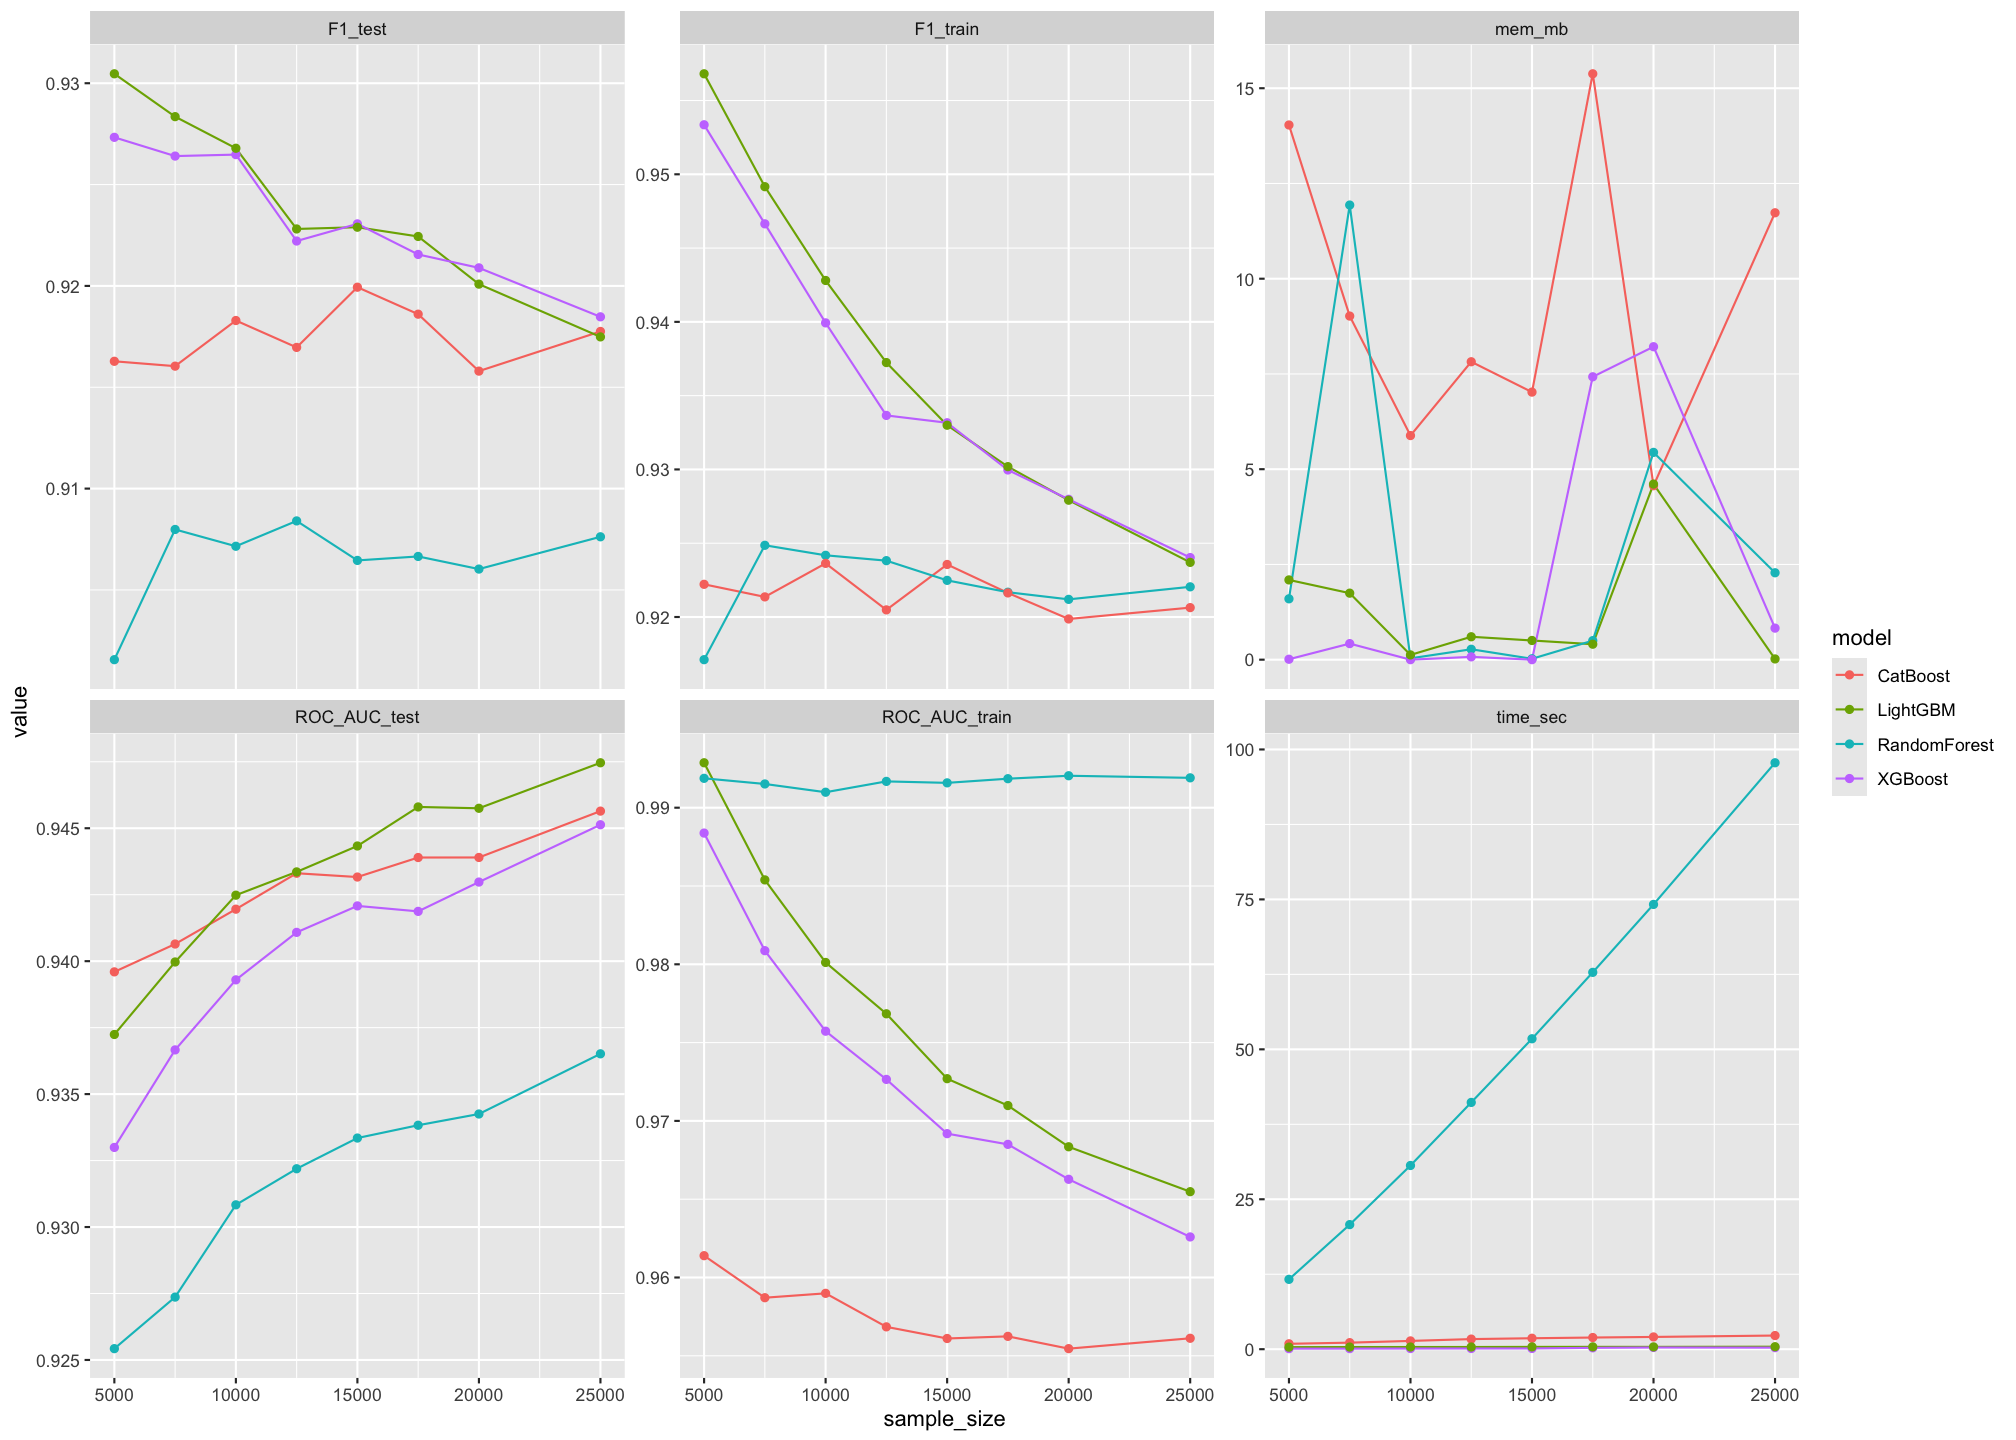

In [35]:
sample_sizes <- c(5000, 7500, 10000, 12500, 15000, 17500, 20000, 25000)
subsample_results <- bind_rows(lapply(sample_sizes, function(n) mutate(try_all(n), sample_size = n)))
subsample_long <- pivot_longer(
    select(subsample_results, model, sample_size, F1_train, ROC_AUC_train, F1_test, ROC_AUC_test, time_sec, mem_mb),
    c(F1_train, ROC_AUC_train, F1_test, ROC_AUC_test, time_sec, mem_mb),
    names_to = "metric",
    values_to = "value"
)
ggplot(subsample_long, aes(x = sample_size, y = value, color = model)) +
    geom_line() + geom_point() +
    facet_wrap(~ metric, scales = "free_y")

LightGBM и XGBoost показывают лучшие результаты и по F1-мере, и по ROC-AUC. CatBoost немного хуже по F1-мере, но по ROC-AUC показывает схожий результат: видимо, порог вероятностей 0.5 для него не очень подходит. Важно отметить, что CatBoost оказался наиболее устойчивым к изменению размера выборки: метрики качества практически совпадают на выборках разного размера. RandomForest, в свою очередь, показывает худшее качество на тестовой выборке из всех рассмотренных моделей, и явно переобучается. 

По времени работы, RandomForest явно проигрывает остальным моделям, время работы которх приблизительно одинаково (разве что CatBoost немного медленнее остальных). По памяти результат неоднозначный: у моделей странные пики потребления, причем даже не на самых больших подвыборках. Замерять память в R, где есть garbage collector, - не лучшая идея :)

Оптимальной моделью на этих данных хочется назвать CatBoost: обучается достаточно быстро, показывает хорошее качество, стабилен на подвыборках и, что особенно важно, умеет работать с категориальными признакам "напрямую" без необходимости дополнительного кодирования.

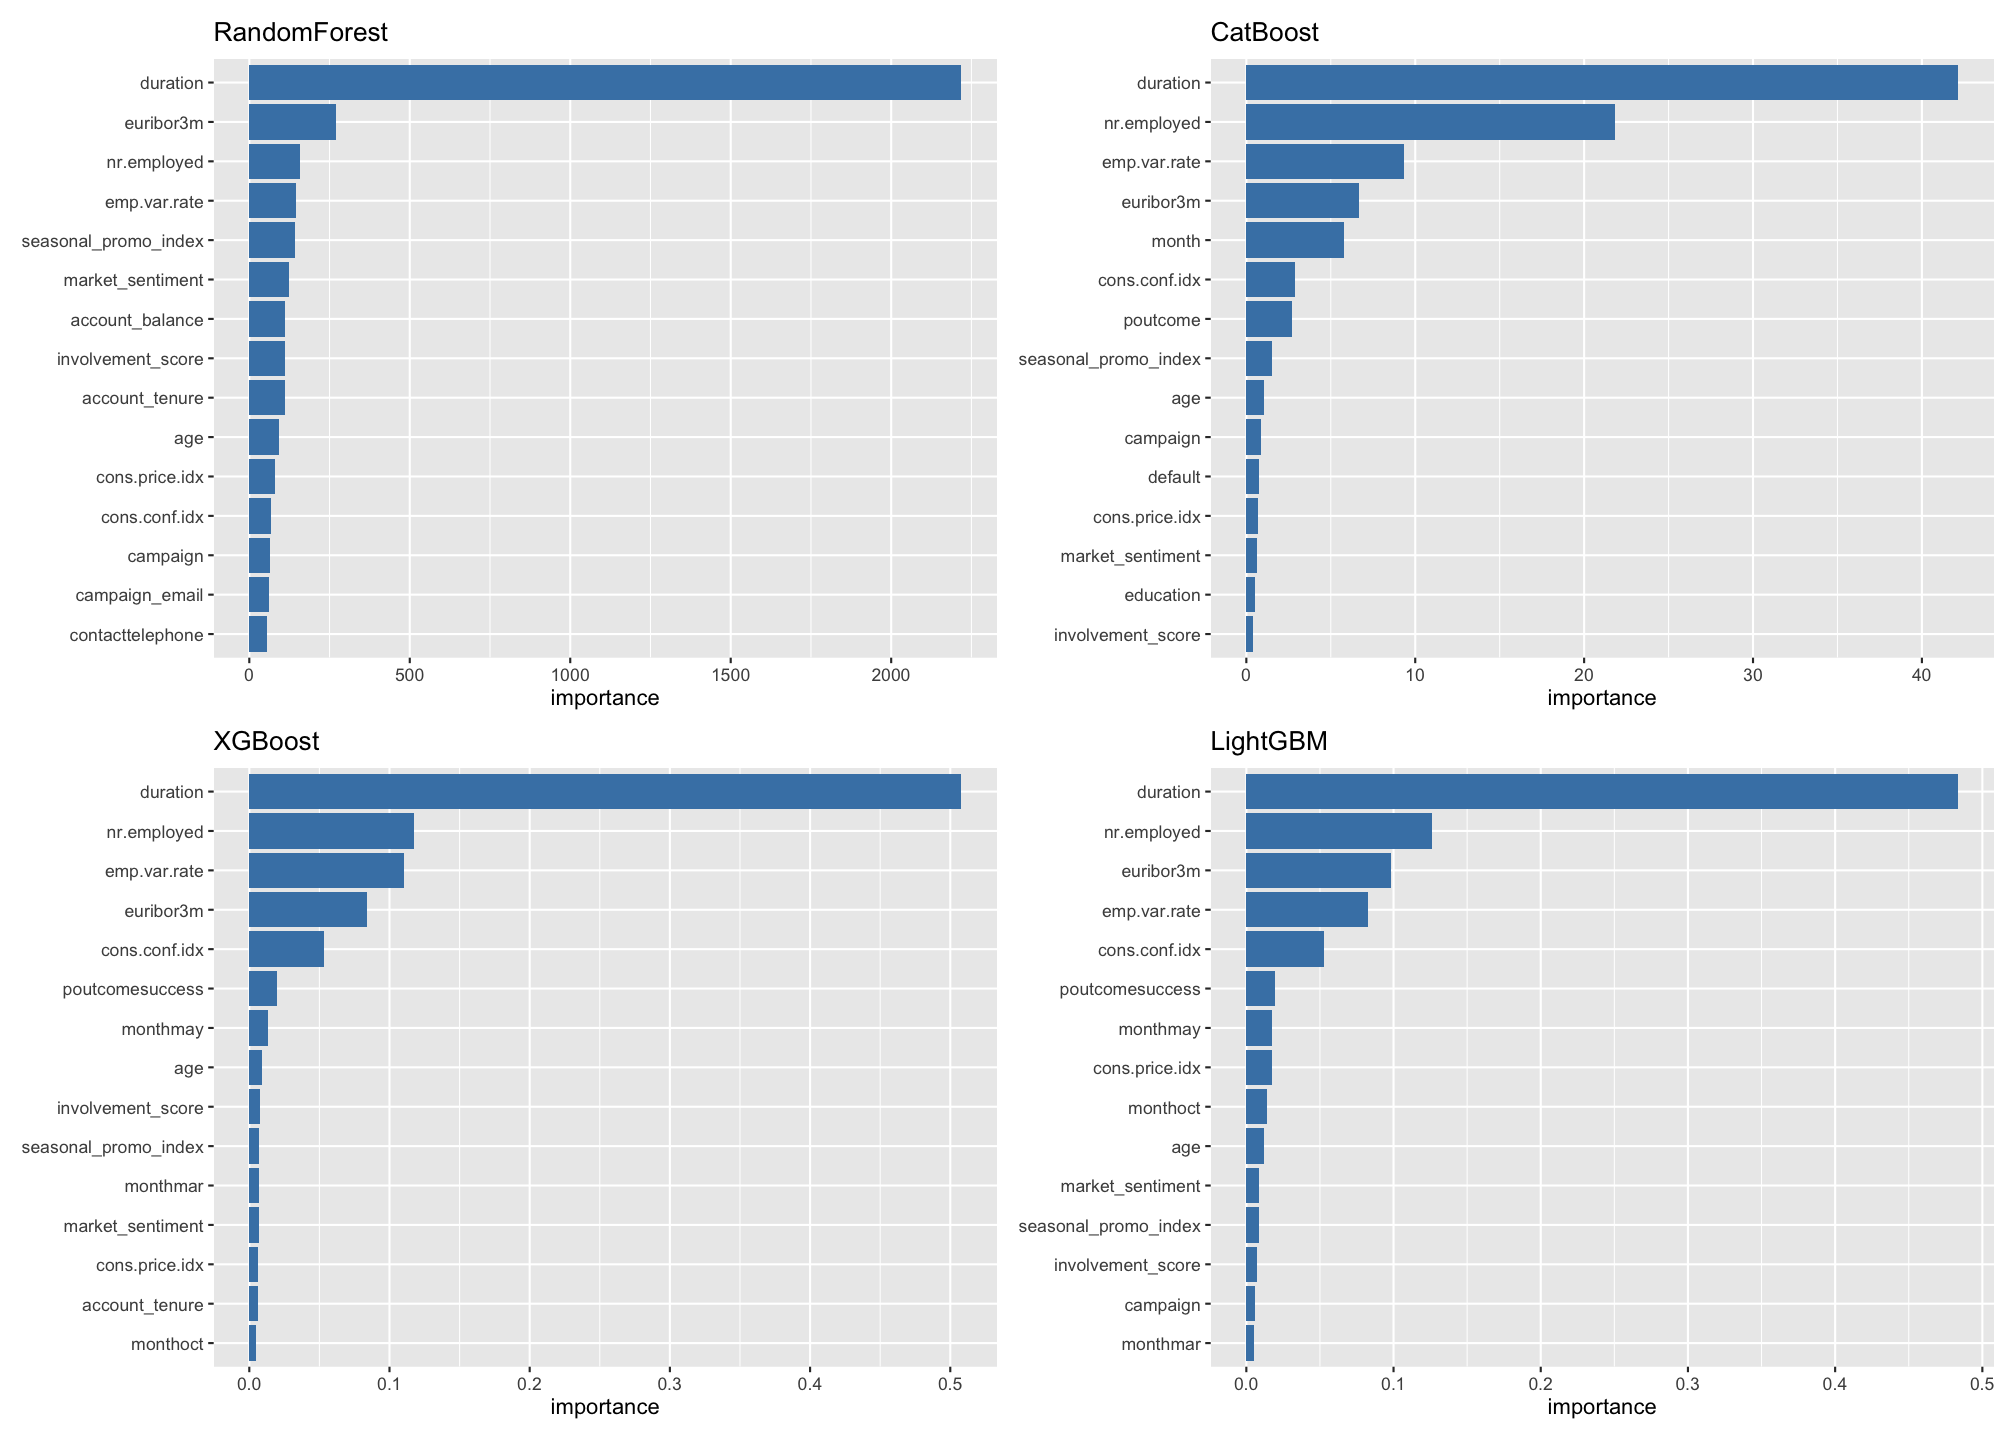

In [36]:
plot_importance <- function(model_out, title, top_n = 15) {
    df <- slice_head(arrange(model_out$importance, desc(importance)), n = top_n)
    ggplot(df, aes(x = reorder(feature, importance), y = importance)) +
        geom_col(fill = "steelblue") + coord_flip() +
        labs(title = title, x = NULL)
}

patchwork::wrap_plots(
    plot_importance(try_tf(),       "RandomForest"),
    plot_importance(try_catboost(), "CatBoost"),
    plot_importance(try_xgboost(),  "XGBoost"),
    plot_importance(try_lightgbm(), "LightGBM"),
    ncol = 2
)

Самый "важный" признак во всех моделях с большим отрывом - `duration`: "Длительность последнего звонка". Как мы видели ранее, клиенты с большой длительностью звонка вероятнее откликнутся на кампанию. Хотя и неоднозначно, но это является "утечкой". По сути, длительность разговора и есть индикатор отклика на предложение. Считаю целесообразным убрать этот признак из анализа.

По той же причине удалим `campaign`, `campaign_push` и `campaign_email`: это информация о текущей кампании, и при запуске новой кампании ее не будет. 

In [37]:
drop_features <- c("duration", "campaign", "campaign_push", "campaign_email")

X_train <- select(X_train, -any_of(drop_features))
X_test  <- select(X_test,  -any_of(drop_features))
X_train_ohe <- drop_ohe(X_train_ohe, drop_features)
X_test_ohe  <- drop_ohe(X_test_ohe,  drop_features)

try_all()

model,Accuracy_train,Precision_train,Recall_train,F1_train,ROC_AUC_train,Accuracy_test,Precision_test,Recall_test,F1_test,ROC_AUC_test,time_sec,mem_mb
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
RandomForest,0.8700835,1.0000000,0.8535864,0.9210106,0.9774915,0.8092726,0.9506879,0.8280127,0.8851199,0.7982527,129.160,0.57031250
CatBoost,0.8411767,0.9511898,0.8654178,0.9062789,0.8398401,0.8340281,0.9508720,0.8572524,0.9016385,0.8043857,2.425,4.51953125
XGBoost,0.8459155,0.9555646,0.8666502,0.9089382,0.8639656,0.8303701,0.9487289,0.8550475,0.8994554,0.7986068,0.276,4.01953125
LightGBM,0.8524040,0.9553063,0.8745789,0.9131619,0.8791229,0.8420247,0.9504097,0.8672227,0.9069126,0.8052943,0.403,0.01953125


Разрыв между train и test практически не изменился (в целом, его и не было), но метрики явно стали правдоподобнее. ROC-AUC опустился до 0.8 вместо 0.94 ранее.

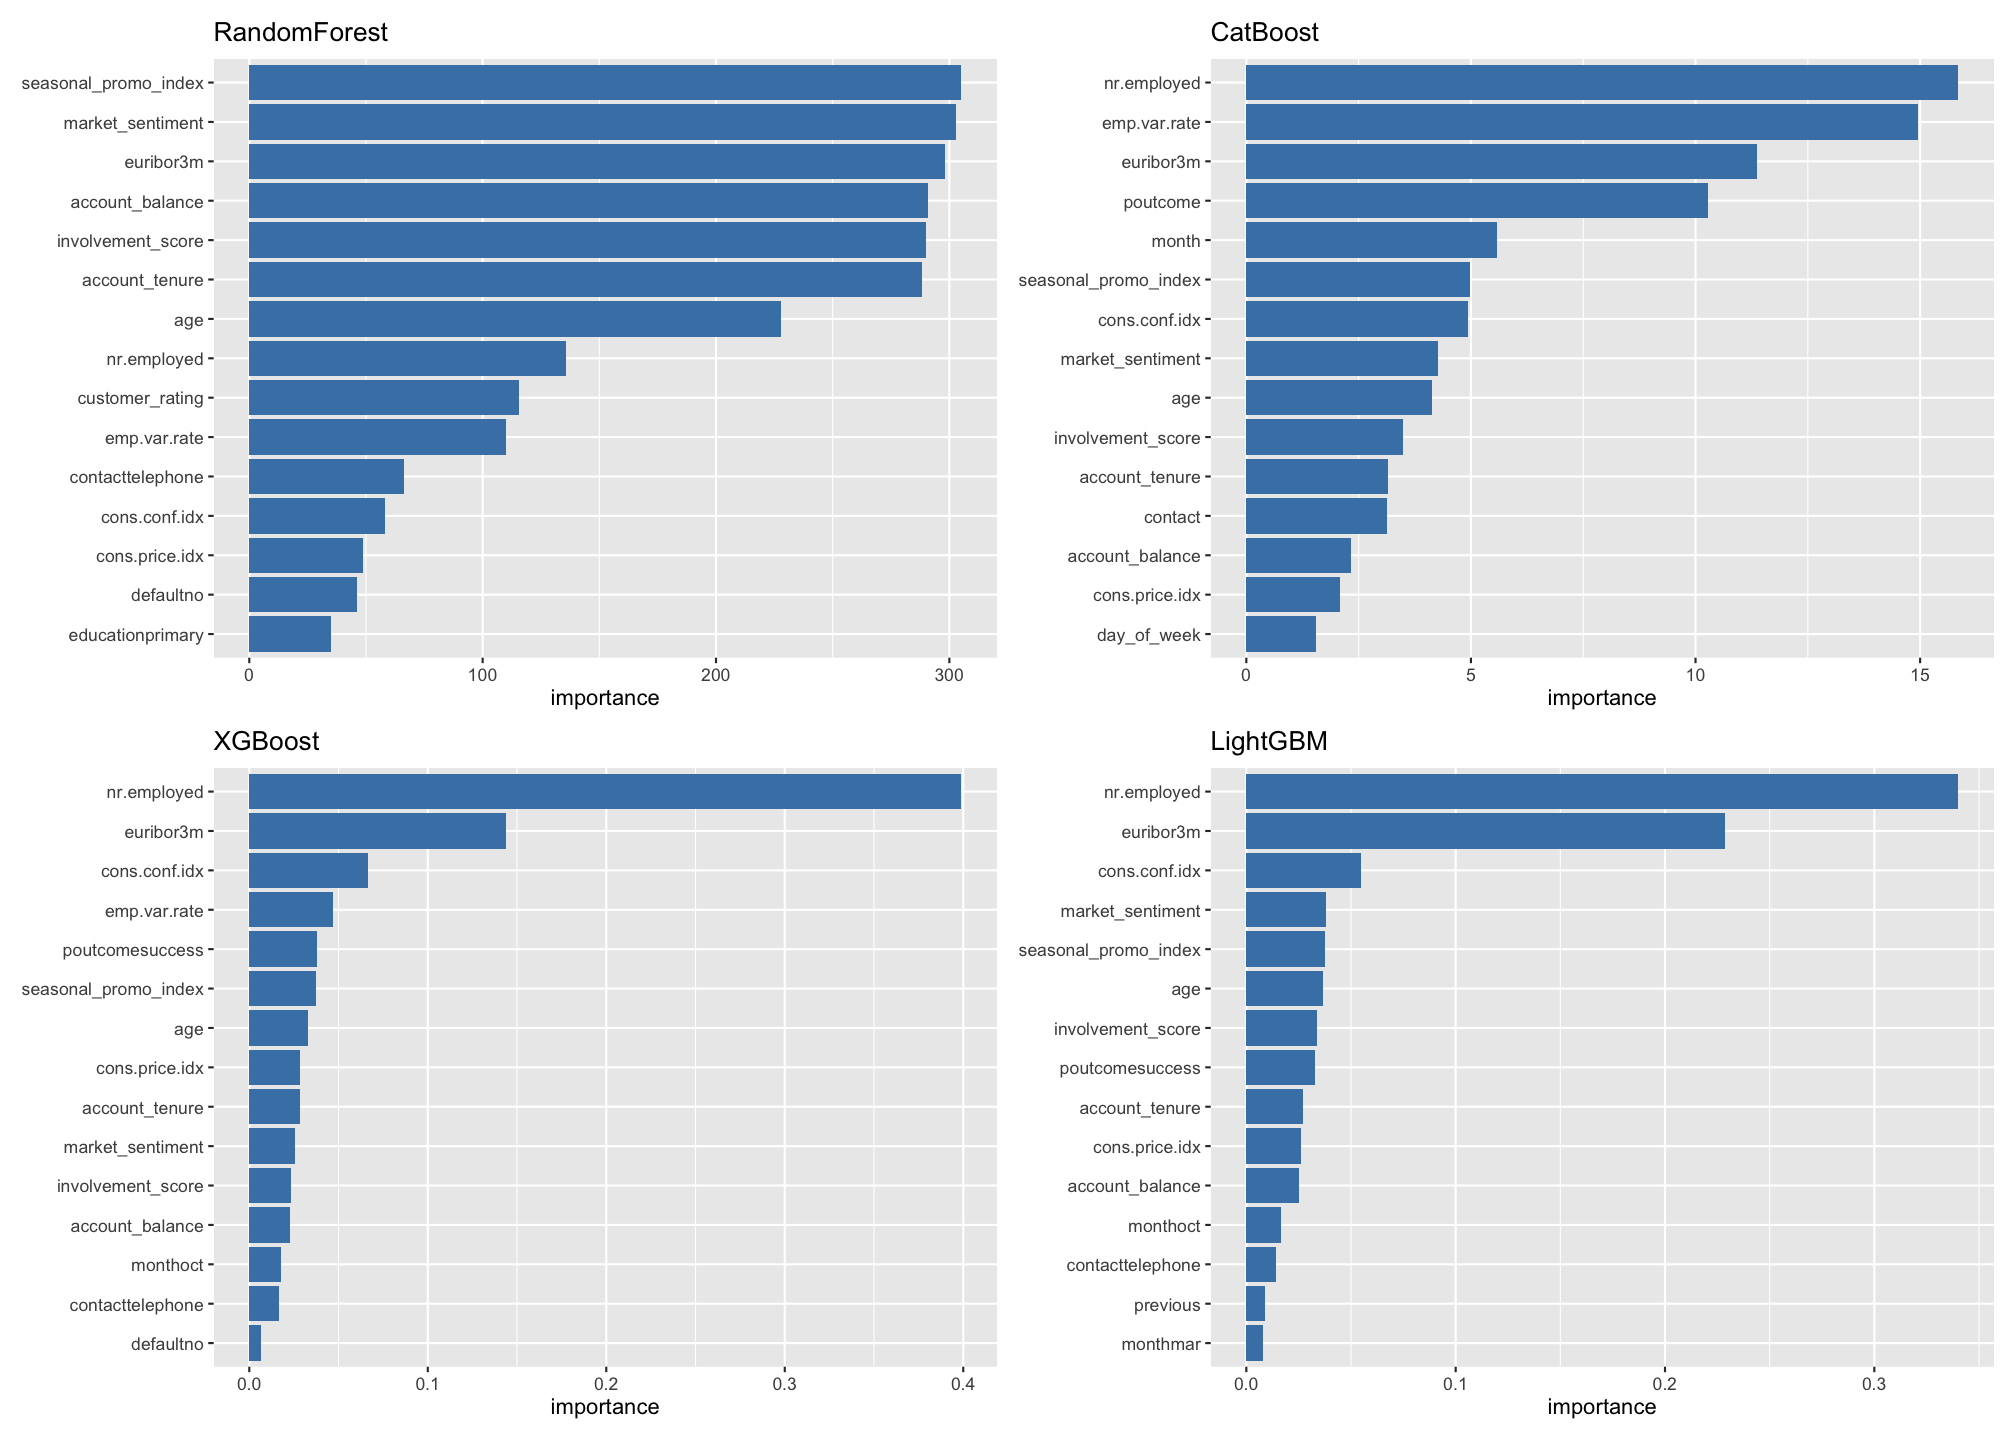

In [38]:
patchwork::wrap_plots(
    plot_importance(try_tf(),       "RandomForest"),
    plot_importance(try_catboost(), "CatBoost"),
    plot_importance(try_xgboost(),  "XGBoost"),
    plot_importance(try_lightgbm(), "LightGBM"),
    ncol = 2
)

Наиболее важными признаками стали внешние факторы: число занятых за последние 3 месяца, ставка Euribor, индекс потребительского доверия. Интересно, что у RandomForest признаки другие, но тоже из числа внешних факторов: сезонный индекс промо-активности, "рыночный настрой". В целом, эту закономерность мы уже видели ранее: если в экономике "все плохо", то людей вряд ли заинтересует кампания.

Попробуем также убрать эти признаки, чтобы проверить, есть ли еще какие-то хорошие регрессоры.

In [39]:
drop_features <- c(
    "emp.var.rate", "cons.price.idx", "cons.conf.idx", "euribor3m", "nr.employed",
    "market_sentiment", "seasonal_promo_index"
)

X_train <- select(X_train, -any_of(drop_features))
X_test  <- select(X_test,  -any_of(drop_features))
X_train_ohe <- drop_ohe(X_train_ohe, drop_features)
X_test_ohe  <- drop_ohe(X_test_ohe,  drop_features)

try_all()

model,Accuracy_train,Precision_train,Recall_train,F1_train,ROC_AUC_train,Accuracy_test,Precision_test,Recall_test,F1_test,ROC_AUC_test,time_sec,mem_mb
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
RandomForest,0.6777968,1.0000000,0.6368828,0.7781654,0.9797362,0.6069758,0.9533469,0.5857540,0.7256532,0.7628459,114.858,0.6992188
CatBoost,0.8387708,0.9432946,0.8706351,0.9055096,0.8028587,0.8363250,0.9411887,0.8699070,0.9041451,0.7775522,2.275,2.7734375
XGBoost,0.8253199,0.9507101,0.8470545,0.8958940,0.8329379,0.8118248,0.9390961,0.8425846,0.8882264,0.7686439,0.230,0.2812500
LightGBM,0.8423432,0.9513009,0.8666913,0.9070272,0.8468073,0.8353041,0.9416658,0.8681814,0.9034318,0.7759017,0.378,0.2968750


Все еще неплохое качество предсказаний. Значит, среди оставшихся признаков тоже есть хорошие регрессоры.

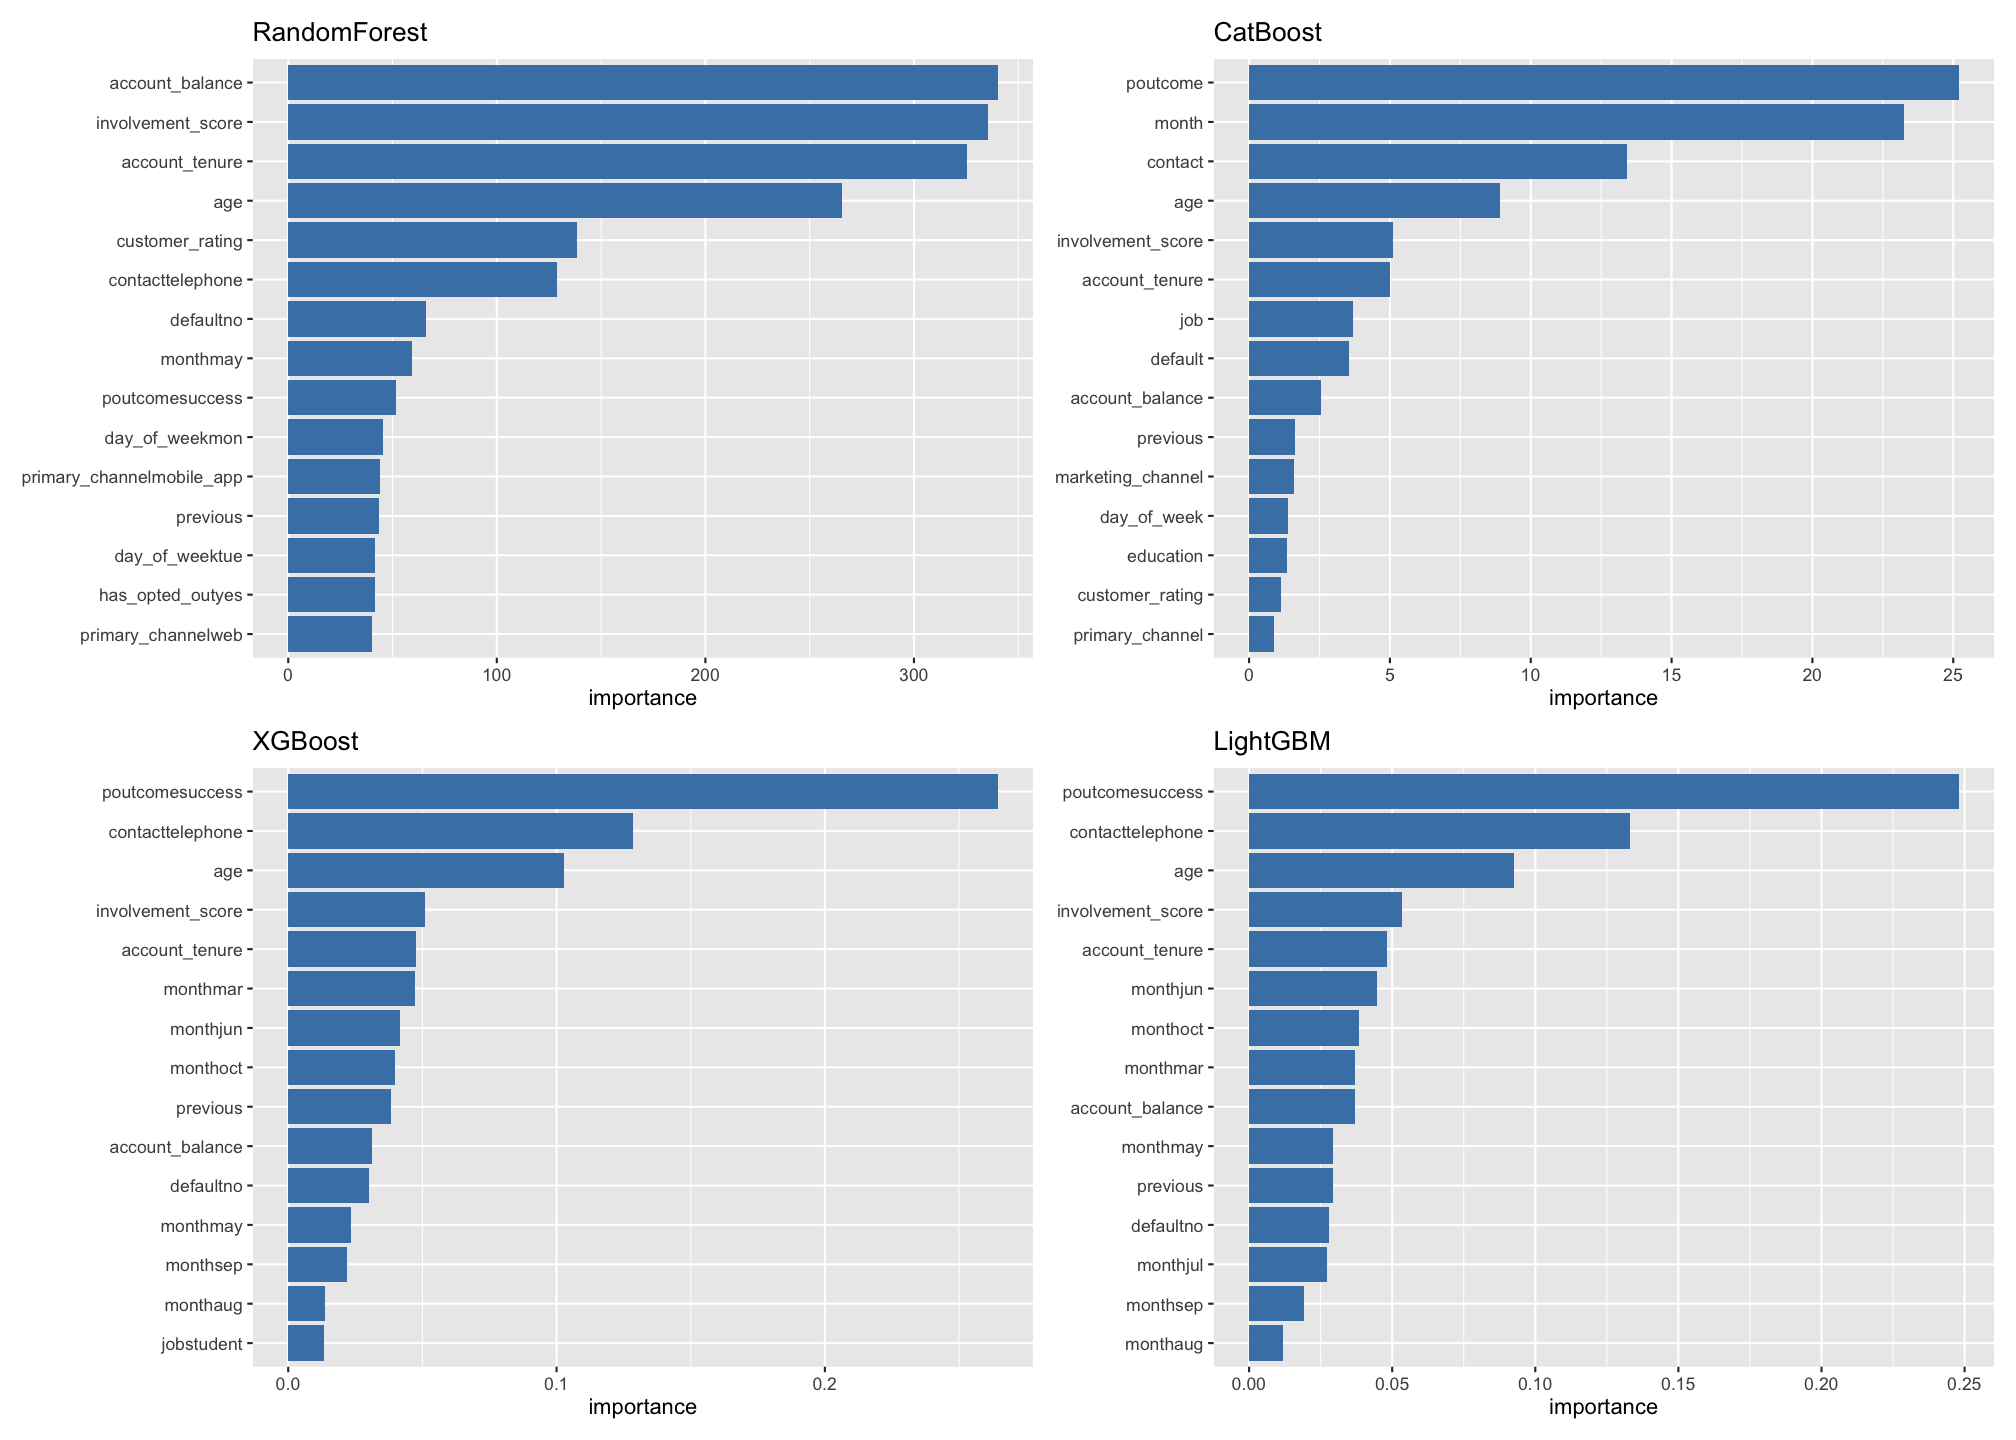

In [40]:
patchwork::wrap_plots(
    plot_importance(try_tf(),       "RandomForest"),
    plot_importance(try_catboost(), "CatBoost"),
    plot_importance(try_xgboost(),  "XGBoost"),
    plot_importance(try_lightgbm(), "LightGBM"),
    ncol = 2
)

В RandomForest важными снова оказываются совершенно не те признаки, что в бустингах. Но и качество у него хуже. поэтому в рассуждениях сфокусируемся на бустинговых моделях.

Действительно, большую важность имеет признак `poutcome` и его значение `success` в частности. Это мы также видели в предыдущих заданиях: если прошлая кампания была успешна, то и следующая вероятно будет успешна.

Второй выделяющийся признак - `contact` и особенно значение `telephone`. Это мы тоже уже видели: при связи по телефону, клиент вероятнее не откликнется на кампанию.

Далее идет признак `age`, что более интересно. Ранее этот признак появлялся лишь в решающем дереве, где разделял сегменты пользователей под номерами 5 и 6 по порогу около 50 лет: молодые люди попадали в 6 сегмент с меньшей конверсией. При определенных значениях других признаков, старшие люди вероятнее откликаются на кампанию. Это, в целом, заметно и на гистограммах из первого задания, хотя и неоднозначно.

In [41]:
# Заодно удаляем признак previous: он явно имеет много общего с poutcome
drop_features <- c("poutcome", "previous", "contact", "age")

X_train <- select(X_train, -any_of(drop_features))
X_test  <- select(X_test,  -any_of(drop_features))
X_train_ohe <- drop_ohe(X_train_ohe, drop_features)
X_test_ohe  <- drop_ohe(X_test_ohe,  drop_features)

try_all()

model,Accuracy_train,Precision_train,Recall_train,F1_train,ROC_AUC_train,Accuracy_test,Precision_test,Recall_test,F1_test,ROC_AUC_test,time_sec,mem_mb
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
RandomForest,0.5499945,1.0000000,0.4928519,0.6602823,0.9688708,0.4845598,0.9475839,0.4436775,0.6043748,0.7033744,108.198,0.687500
CatBoost,0.7577370,0.9403743,0.7761893,0.8504299,0.7625381,0.7507444,0.9346390,0.7731761,0.8462749,0.7330038,2.173,2.722656
XGBoost,0.7599606,0.9477533,0.7720401,0.8509203,0.7928660,0.7440238,0.9321146,0.7674240,0.8417898,0.7237627,0.232,2.207031
LightGBM,0.7752707,0.9522767,0.7861310,0.8612643,0.8098099,0.7547427,0.9328975,0.7796951,0.8494438,0.7299069,0.387,1.175781


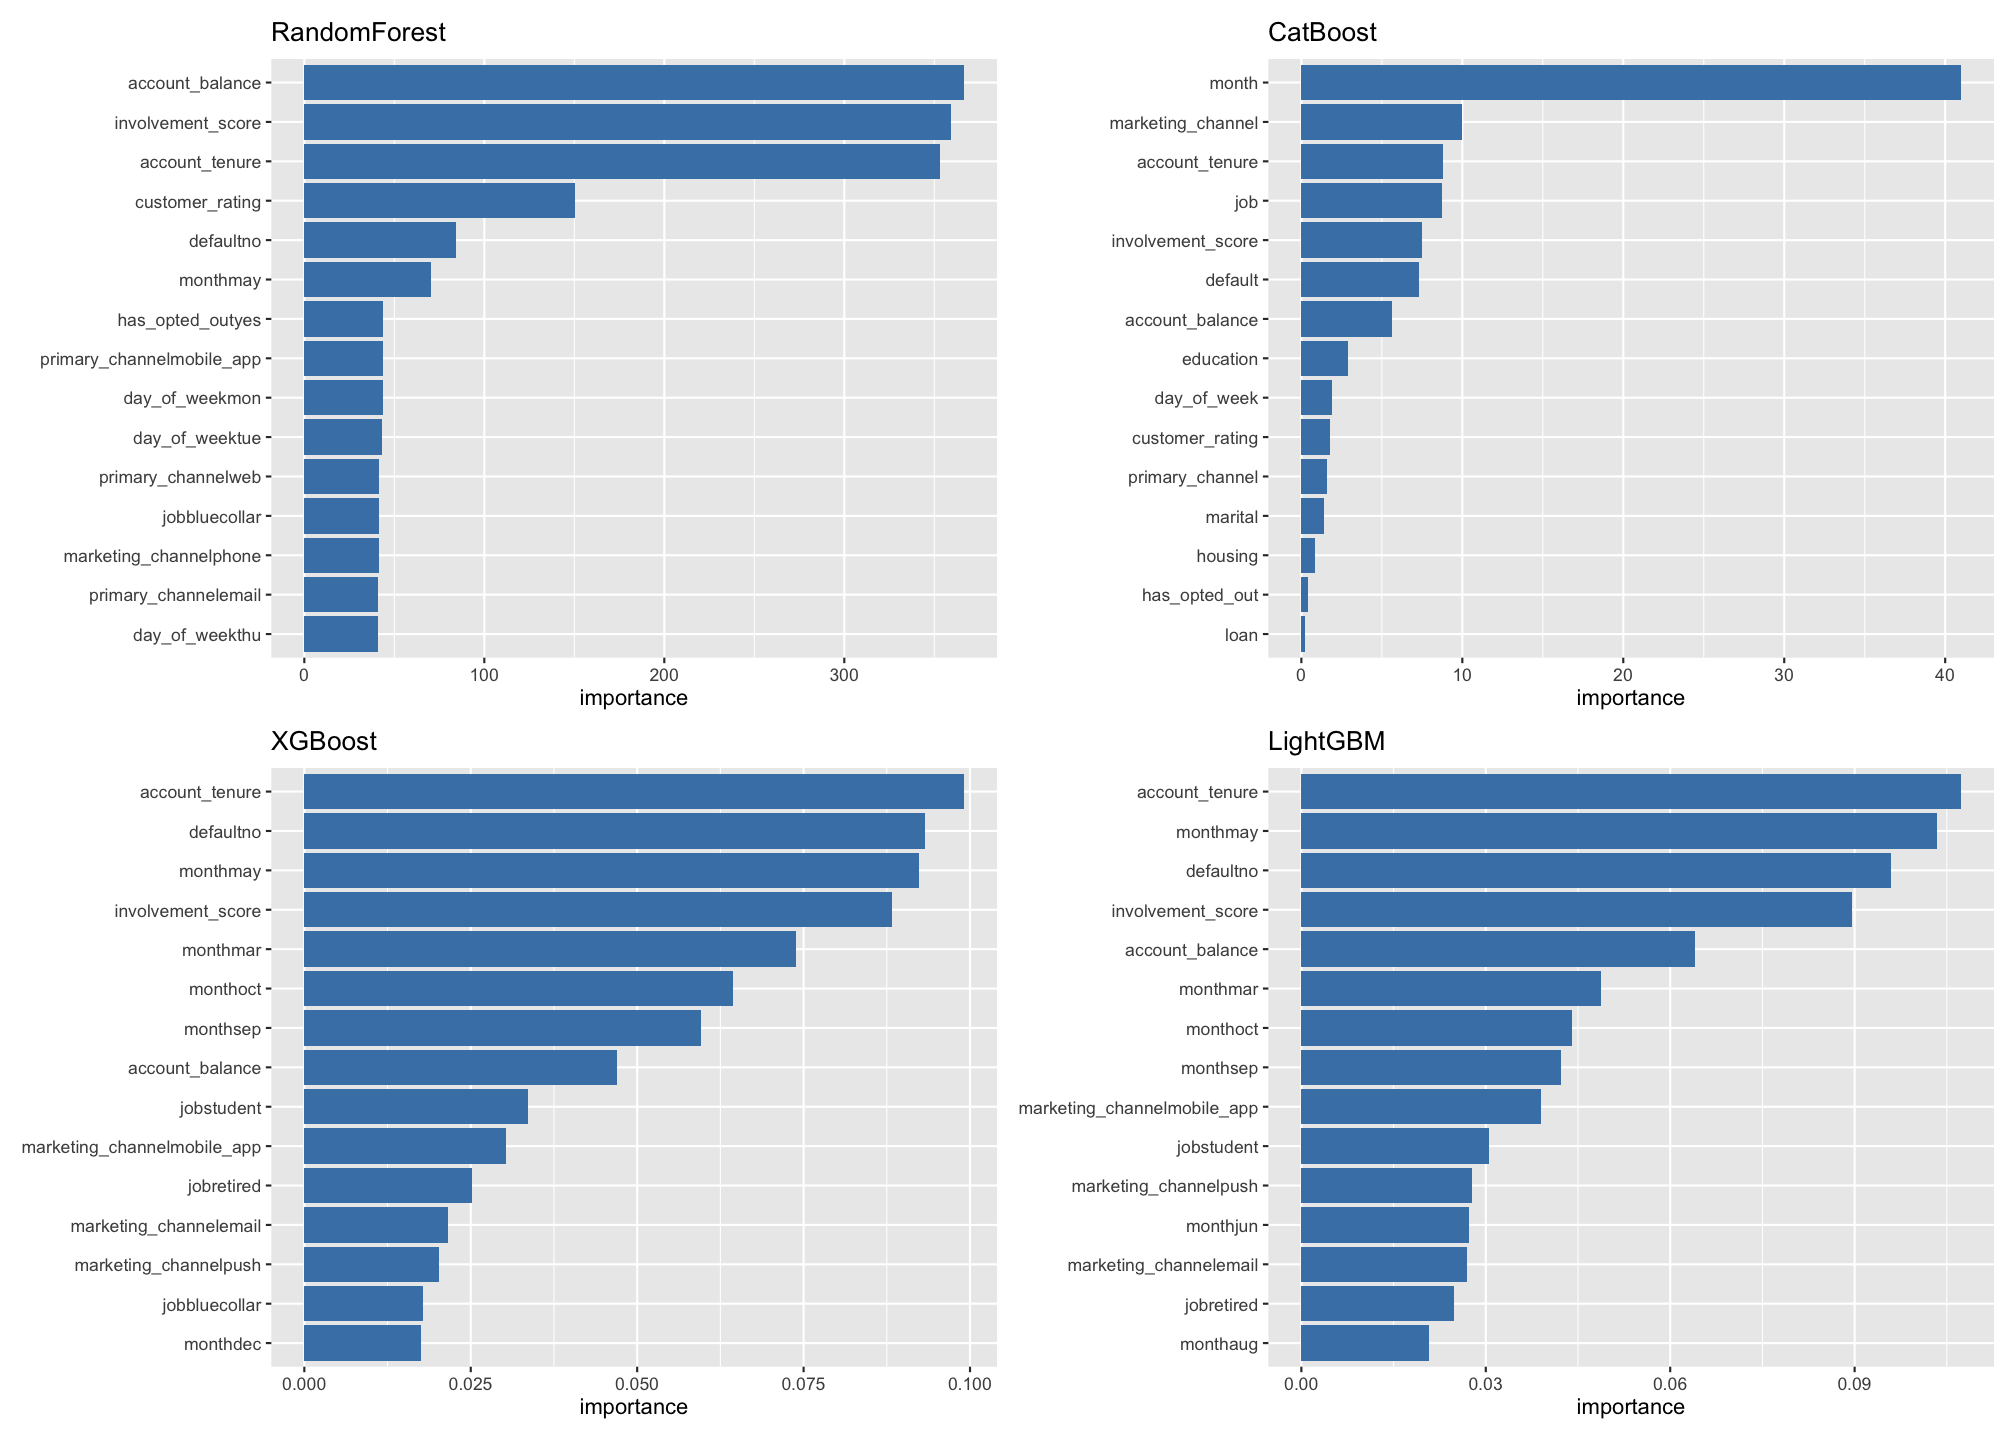

In [42]:
patchwork::wrap_plots(
    plot_importance(try_tf(),       "RandomForest"),
    plot_importance(try_catboost(), "CatBoost"),
    plot_importance(try_xgboost(),  "XGBoost"),
    plot_importance(try_lightgbm(), "LightGBM"),
    ncol = 2
)

Теперь наиболее важный признак - месяц последнего контакта. В MCA и FAMD этому не уделялось должного внимания, но диаграммы из задания 1 говорят о наличии здесь интересных закономерностей: в декабре, марте, октябре и сентябре явно больше откликов, чем в остальных месяцах.

Также выделились признаки `account_tenure` и `involvement_score`, которые сильно влияли на сегменты MCA и FAMD: "старички" (большие `account_tenure` и `involvement_score`) скорее откликаются на кампанию

In [43]:
drop_features <- c("month", "account_tenure", "involvement_score")

X_train <- select(X_train, -any_of(drop_features))
X_test  <- select(X_test,  -any_of(drop_features))
X_train_ohe <- drop_ohe(X_train_ohe, drop_features)
X_test_ohe  <- drop_ohe(X_test_ohe,  drop_features)

try_all()

model,Accuracy_train,Precision_train,Recall_train,F1_train,ROC_AUC_train,Accuracy_test,Precision_test,Recall_test,F1_test,ROC_AUC_test,time_sec,mem_mb
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
RandomForest,0.3055444,1.0000000,0.2173609,0.3571019,0.9233260,0.2745215,0.9494568,0.1926949,0.3203698,0.6368345,78.317,8.68750000
CatBoost,0.6155725,0.9337819,0.6100156,0.7379485,0.6931330,0.6091876,0.9290019,0.6058863,0.7334339,0.6651385,2.067,4.05859375
XGBoost,0.6549776,0.9426888,0.6507271,0.7699599,0.7304972,0.6329222,0.9253129,0.6378104,0.7551217,0.6563830,0.206,0.03515625
LightGBM,0.6539205,0.9423787,0.6497001,0.7691372,0.7429218,0.6295194,0.9254902,0.6334963,0.7521484,0.6654069,0.371,0.45312500


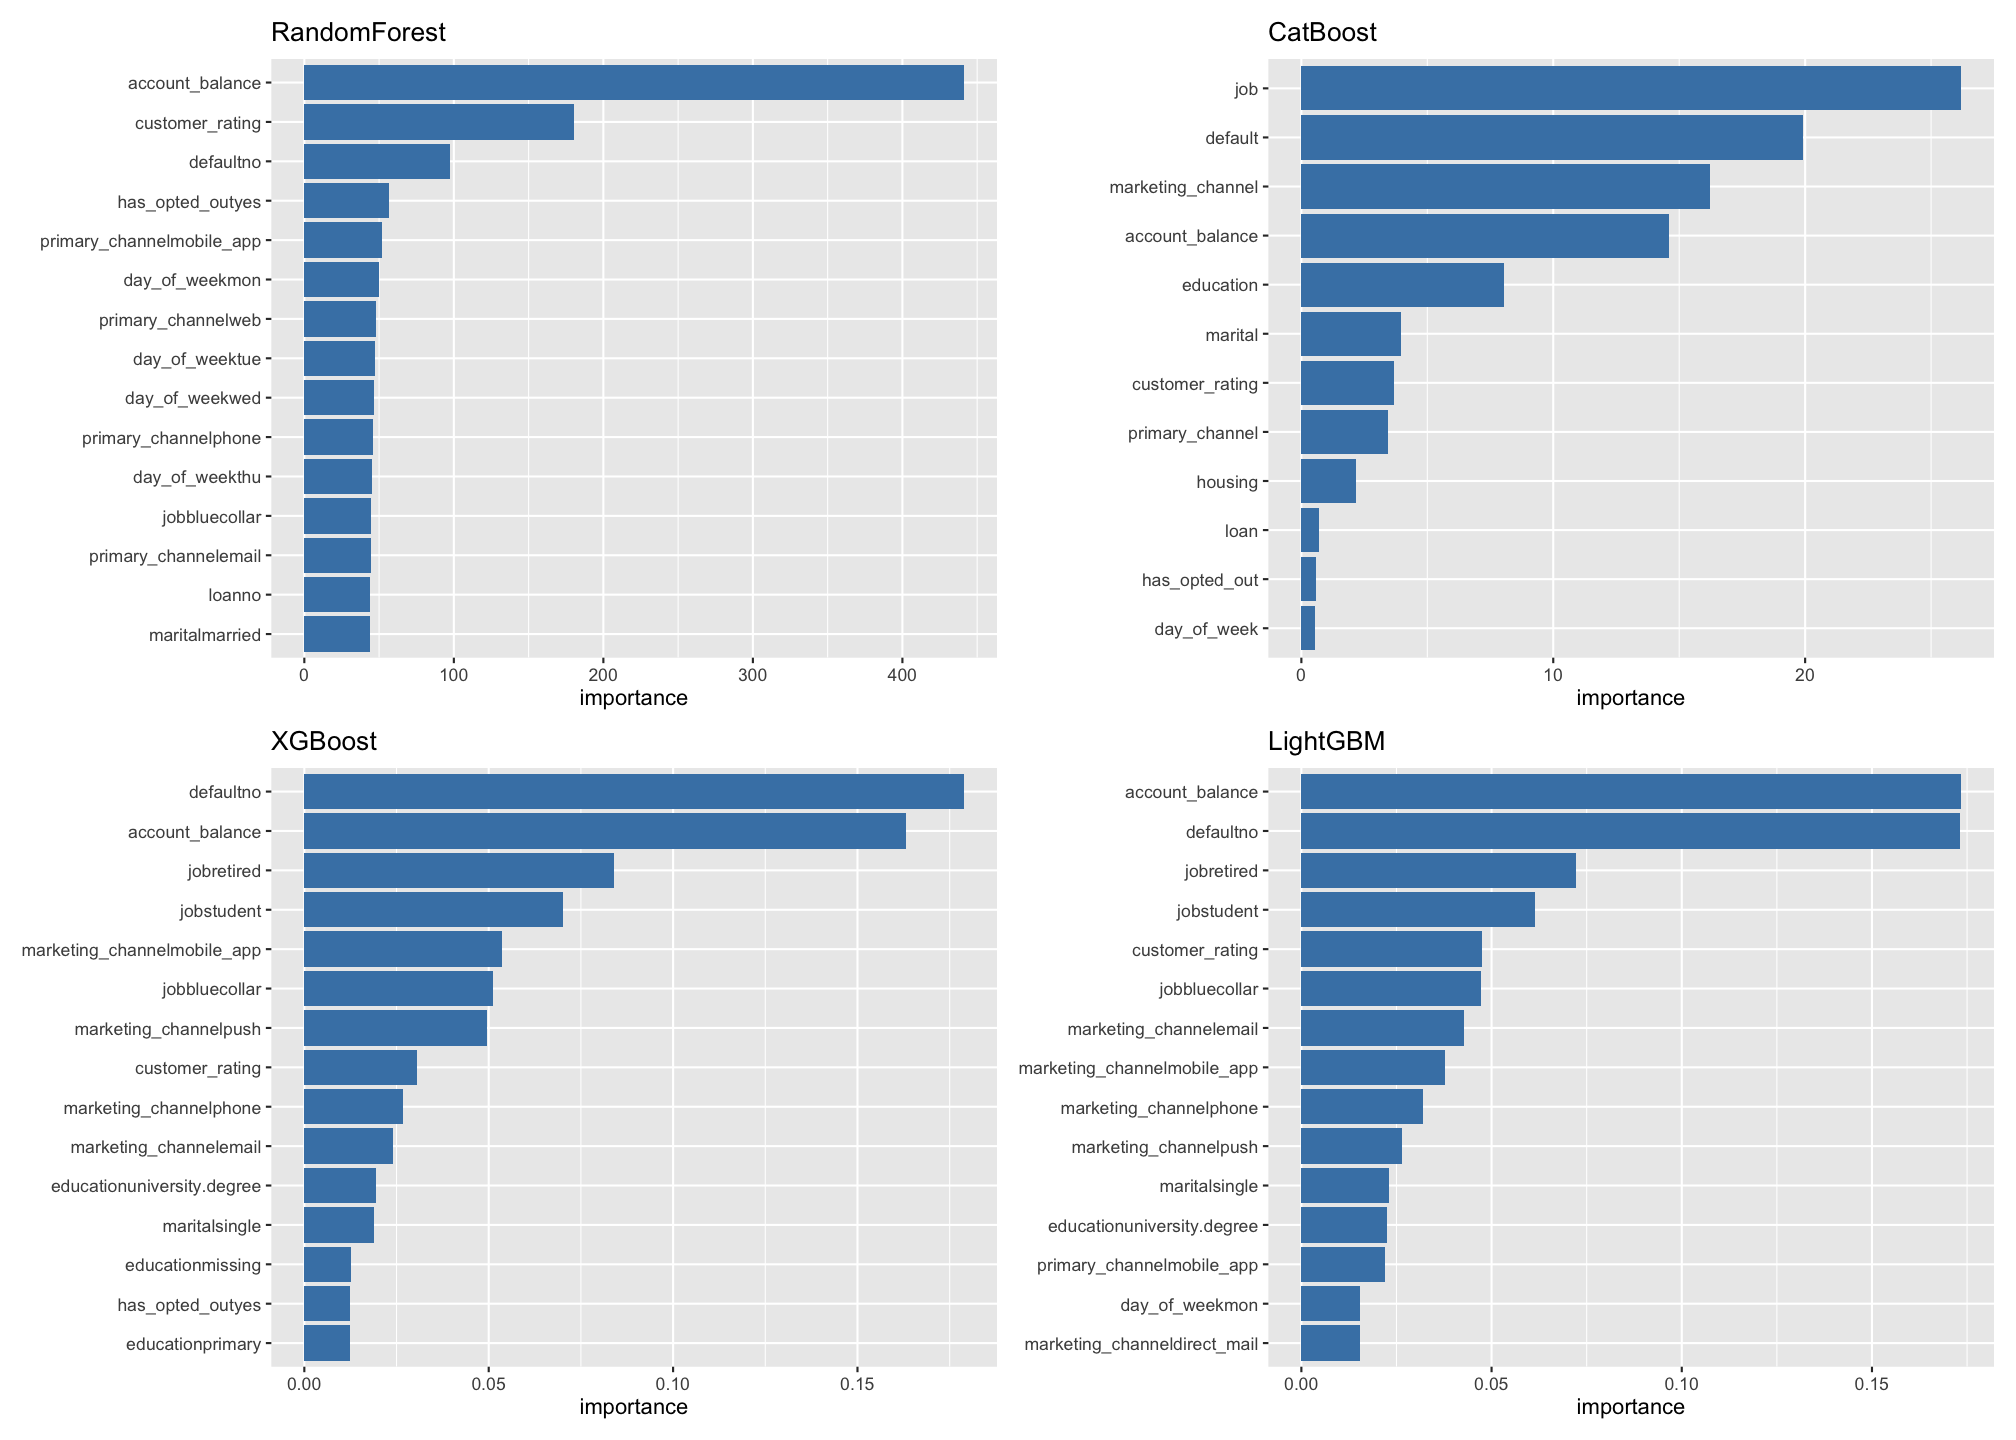

In [44]:
patchwork::wrap_plots(
    plot_importance(try_tf(),       "RandomForest"),
    plot_importance(try_catboost(), "CatBoost"),
    plot_importance(try_xgboost(),  "XGBoost"),
    plot_importance(try_lightgbm(), "LightGBM"),
    ncol = 2
)

Наконец, добрались до признаков `job`, `default` и `account_balance`. Как и обнаруживали ранее,
- Студенты (`job=student`) и люди на пенсии (`job=retired`) чаще откликаются на кампанию
- Рабочие (`bluecollar`) реже откликаются на кампанию
- При наличии кредита в состоянии дефолта клиенты скорее не откликаются на кампанию

Значительная важность также у признака `marketing_channel`, но после удаления фактически половины переменных это может не иметь реального смысла. Особенно учитывая, что ROC-AUC "просел" уже до 0.65, указывая на практически случайные предсказания. Даже если в оставшихся признаках есть какие-то закономерности, они точно не должны быть основополагающими при проведении кампании. 
Считаю целесообразным остановиться :)

**Итоговые рекомендации:**

1. Клиенты, с которыми удалось проести много/длительные звонки вероятнее всего откликнутся на кампанию. Но этот сегмент сформируется лишь после начала кампании; использовать его сразу не получится.
2. Пожалуй, наибольшая вероятность отклика - у тех, кто успешно откликался на предыдущие кампании. Это ключевой сегмент клиентов для маркетинга.
3. Далее, целесообразно связываться с лояльными клиентами, которые давно пользуются нашими услугами.
4. В заключение, можно выделить сегменты по социальному положению человека: студенты и пенсионеры, нуждающиеся в деньгах, вероятнее всего откликаются на кампанию. Тем не менее это самые неустойчивые сегменты.

В целом, кампанию стоит проводить в благоприятной макроэкономической обастановке. В частности, при большой ставке Euribor отклики будут низкими. Также при выборе времени следует учитывать праздники/события: в некоторых месяцах доля откликов заметно выше.